# Phyloseq analysis
- combo from Nikea https://github.com/nikeaulrich/DR_SCTLD/blob/main/DR_phyloseq.ipynb and my old https://github.com/brookewicz/CBC_metagenomics/blob/main/pstr/pstr_taxonomy_plots.ipynb

https://www.bioconductor.org/packages/release/bioc/html/phyloseq.html

Need to make a phyloseq object to run lefse \
https://rdrr.io/github/yiluheihei/microbiomeMarker/man/run_lefse.html

In [420]:
getwd()

[1] "/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/taxonomy/kraken2_pluspf/bracken"

In [421]:
# see installation from 4Taxa_Trials in PSTR

In [422]:
# library(taxonomizr)
# this will get full taxonomy from NCBI 

In [423]:
library(tidyverse)
library(vegan)
library(dplyr)
library(phyloseq)
#library(VennDiagram)
library("DESeq2")
library(RColorBrewer)
library(ggplot2)
library(cowplot)

## Upload Data

In [424]:
setwd("/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/taxonomy/kraken2_pluspf/bracken")

### Taxonomy 

In [425]:
taxa = read.csv('otu_id_species.csv',header=TRUE)
head(taxa)

,taxonomy_id,name,taxonomy_lvl
,<int>,<chr>,<chr>
1,3021011,Vibrio sp. SCSIO 43137,S
2,2819098,Vibrio sp. SCSIO 43153,S
3,2819101,Vibrio sp. SCSIO 43136,S
4,2912314,Vibrio sp. JC009,S
5,2751178,Vibrio sp. B1FLJ16,S
6,2751176,Vibrio sp. B1ASS3,S


In [426]:
# remove taxa level col
taxa$taxonomy_lvl <- NULL 
# change taxa table names
colnames(taxa) <- c("otuid","species")

In [427]:
head(taxa)

,otuid,species
,<int>,<chr>
1,3021011,Vibrio sp. SCSIO 43137
2,2819098,Vibrio sp. SCSIO 43153
3,2819101,Vibrio sp. SCSIO 43136
4,2912314,Vibrio sp. JC009
5,2751178,Vibrio sp. B1FLJ16
6,2751176,Vibrio sp. B1ASS3


In [428]:
## add in full taxonomy from krakentools (2.1OTUtable)
taxa_full<-read.csv("txt_files/bracken_S.combined.mpa", sep = '\t') %>% select(1)
head(taxa_full)

,X.Classification
,<chr>
1,d__Bacteria
2,d__Bacteria|f__Candidatus_Chazhemtobacteraceae
3,d__Bacteria|f__Candidatus_Chazhemtobacteraceae|g__Candidatus_Chazhemtobacterium
4,d__Bacteria|f__Candidatus_Chazhemtobacteraceae|g__Candidatus_Chazhemtobacterium|s__Candidatus_Chazhemtobacterium_aquaticus
5,d__Bacteria|p__Candidatus_Bipolaricaulota
6,d__Bacteria|p__Candidatus_Bipolaricaulota|c__Candidatus_Bipolaricaulia


In [429]:
taxa_full[73,1]

[1] "d__Bacteria|k__Thermotogati|p__Synergistota|c__Synergistia|o__Synergistales|f__Aminithiophilaceae|g__Aminithiophilus|s__Aminithiophilus_ramosus"

In [430]:
taxonomy_full<-taxa_full %>%
  separate(
    col = X.Classification, 
    into = c("domain","kingdom", "phylum", "class", "order", "family", "genus", "species"), 
    sep = "\\|") %>%
  mutate(across(everything(), ~ gsub("^[a-z]__", "", .)))

Warning message:
“Expected 8 pieces. Missing pieces filled with `NA` in 7291 rows [1, 2, 3, 4, 5,
6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, ...].”


In [431]:
# filter for species-level matches
# and replace _ for spaces 
sp_full<-taxonomy_full %>%
    filter(!is.na(species)) %>%
    mutate(species = str_replace_all(species,"_"," "))
head(sp_full)

,domain,kingdom,phylum,class,order,family,genus,species
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Bacteria,Thermotogati,Synergistota,Synergistia,Synergistales,Aminithiophilaceae,Aminithiophilus,Aminithiophilus ramosus
2,Bacteria,Thermotogati,Synergistota,Synergistia,Synergistales,Aminiphilaceae,Aminirod,Aminirod propionatiphilus
3,Bacteria,Thermotogati,Synergistota,Synergistia,Synergistales,Synergistaceae,Thermanaerovibrio,Thermanaerovibrio acidaminovorans
4,Bacteria,Thermotogati,Synergistota,Synergistia,Synergistales,Synergistaceae,Thermanaerovibrio,Thermanaerovibrio velox
5,Bacteria,Thermotogati,Synergistota,Synergistia,Synergistales,Synergistaceae,Aminomonas,Aminomonas paucivorans
6,Bacteria,Thermotogati,Synergistota,Synergistia,Synergistales,Synergistaceae,Cloacibacillus,Cloacibacillus evryensis


In [432]:
# merge with species taxa table
merged_taxa<-taxa %>%
    left_join(sp_full, by = "species")

In [433]:
unique(merged_taxa$domain)

[1] "Bacteria"  NA          "Eukaryota" "Archaea"

In [434]:
head(merged_taxa)

,otuid,species,domain,kingdom,phylum,class,order,family,genus
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,3021011,Vibrio sp. SCSIO 43137,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio
2,2819098,Vibrio sp. SCSIO 43153,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio
3,2819101,Vibrio sp. SCSIO 43136,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio
4,2912314,Vibrio sp. JC009,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio
5,2751178,Vibrio sp. B1FLJ16,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio
6,2751176,Vibrio sp. B1ASS3,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio


In [435]:
getwd()

[1] "/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/taxonomy/kraken2_pluspf/bracken"

In [436]:
# export - go back to 2.1 OTU table to use python to download full hierarchy for remaining missing spp
write.csv(merged_taxa, "txt_files/full_taxa_draft.csv")

In [437]:
merged_taxa %>%
    filter(is.na(genus)) %>%
    head(10)

,otuid,species,domain,kingdom,phylum,class,order,family,genus
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,3395321,Vibrio sp. nBUS_14,NA,NA,NA,NA,NA,NA,NA
2,3398215,Neptuniibacter sp. SY11_33,NA,NA,NA,NA,NA,NA,NA
3,3398212,Neptuniibacter sp. QD48_55,NA,NA,NA,NA,NA,NA,NA
4,3398206,Neptuniibacter sp. PT8_73,NA,NA,NA,NA,NA,NA,NA
5,3398210,Neptuniibacter sp. QD37_6,NA,NA,NA,NA,NA,NA,NA
6,2724896,Marinicellulosiphila megalodicopiae,NA,NA,NA,NA,NA,NA,NA
7,134287,secondary endosymbiont of Heteropsylla cubana,NA,NA,NA,NA,NA,NA,NA
8,1199245,secondary endosymbiont of Ctenarytaina eucalypti,NA,NA,NA,NA,NA,NA,NA
9,2675772,Enterobacteriaceae endosymbiont of Donacia bicoloricornis,NA,NA,NA,NA,NA,NA,NA


In [438]:
# import fully filled in taxonomy table (from 2.1OTUtable using python)
taxonomy_filled<-read.csv("txt_files/taxonomy_filled.csv")

In [439]:
str(taxonomy_filled)

'data.frame':	15891 obs. of  9 variables:
 $ otuid  : int  3021011 2819098 2819101 2912314 2751178 2751176 2785746 3391579 3137398 2908646 ...
 $ species: chr  "Vibrio sp. SCSIO 43137" "Vibrio sp. SCSIO 43153" "Vibrio sp. SCSIO 43136" "Vibrio sp. JC009" ...
 $ domain : chr  "Bacteria" "Bacteria" "Bacteria" "Bacteria" ...
 $ kingdom: chr  "Pseudomonadati" "Pseudomonadati" "Pseudomonadati" "Pseudomonadati" ...
 $ phylum : chr  "Pseudomonadota" "Pseudomonadota" "Pseudomonadota" "Pseudomonadota" ...
 $ class  : chr  "Gammaproteobacteria" "Gammaproteobacteria" "Gammaproteobacteria" "Gammaproteobacteria" ...
 $ order  : chr  "Vibrionales" "Vibrionales" "Vibrionales" "Vibrionales" ...
 $ family : chr  "Vibrionaceae" "Vibrionaceae" "Vibrionaceae" "Vibrionaceae" ...
 $ genus  : chr  "Vibrio" "Vibrio" "Vibrio" "Vibrio" ...


In [440]:
# make the index the otu ids
row.names(taxonomy_filled) <- taxonomy_filled$otuid
taxonomy_filled$otuid <- NULL
head(taxonomy_filled)

,species,domain,kingdom,phylum,class,order,family,genus
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
3021011,Vibrio sp. SCSIO 43137,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio
2819098,Vibrio sp. SCSIO 43153,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio
2819101,Vibrio sp. SCSIO 43136,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio
2912314,Vibrio sp. JC009,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio
2751178,Vibrio sp. B1FLJ16,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio
2751176,Vibrio sp. B1ASS3,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio


In [441]:
# reorder columns in taxonomic order
taxonomy_filled <- taxonomy_filled %>%
  select(domain, kingdom, phylum, class, order, family, genus, species)

In [442]:
unique(taxonomy_filled$domain)
unique(taxonomy_filled$kingdom)

[1] "Bacteria"     "Eukaryota"    "Archaea"      "Virus"        "Unclassified"

[1] "Pseudomonadati"    "Bacillati"         "Fusobacteriati"   
 [4] "Thermotogati"      "Unclassified"      "Fungi"            
 [7] "Methanobacteriati" "Thermoproteati"    "Promethearchaeati"
[10] "Nanobdellati"      "Heunggongvirae"    "Bamfordvirae"     
[13] "Orthornavirae"     "Pararnavirae"      "Shotokuvirae"     
[16] "Zilligvirae"       "Viridiplantae"     "Helvetiavirae"    
[19] "Loebvirae"         "Trapavirae"        "Abadenavirae"     
[22] "Sangervirae"

In [443]:
# fill in unclassified
taxonomy_filled<-taxonomy_filled %>%
    mutate(kingdom = case_when(domain == "Unclassified" ~ kingdom, 
                                kingdom == "Unclassified" ~ paste0("Unclassified_",domain), 
                                TRUE ~ kingdom)) %>%
    mutate(phylum = case_when(kingdom == "Unclassified" ~ phylum, 
                                phylum == "Unclassified" ~ paste0("Unclassified_",kingdom), 
                                TRUE ~ phylum)) %>%
    mutate(class = case_when(phylum == "Unclassified" ~ class, 
                                class == "Unclassified" ~ paste0("Unclassified_",phylum), 
                                TRUE ~ class)) %>%
    mutate(order = case_when(class == "Unclassified" ~ order, 
                                order == "Unclassified" ~ paste0("Unclassified_",class), 
                                TRUE ~ order)) %>%
    mutate(family = case_when(order == "Unclassified" ~ family, 
                                family == "Unclassified" ~ paste0("Unclassified_",order), 
                                TRUE ~ family)) %>%
    mutate(genus = case_when(family == "Unclassified" ~ genus, 
                                genus == "Unclassified" ~ paste0("Unclassified_",family), 
                                TRUE ~ genus))

In [444]:
taxonomy_filled<-taxonomy_filled %>%
    mutate(across(everything(), ~ gsub("^[a-z]__", "", .)))

In [445]:
#convert to character matrix to create phyloseq objects 
taxonomy <- as.matrix(taxonomy_filled)

# check structure
str(taxonomy)    

 chr [1:15891, 1:8] "Bacteria" "Bacteria" "Bacteria" "Bacteria" "Bacteria" ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:15891] "3021011" "2819098" "2819101" "2912314" ...
  ..$ : chr [1:8] "domain" "kingdom" "phylum" "class" ...


### OTU Table

In [446]:
#read in normalized otu table
otu = read.csv('otu_normtable_species.csv',header=TRUE)
head(otu)

,X,X052022_BEL_CBC_T1_10_PSTR,X052022_BEL_CBC_T1_11_PSTR,X052022_BEL_CBC_T1_12_MCAV,X052022_BEL_CBC_T1_13_MCAV,X052022_BEL_CBC_T1_1_PAST,X052022_BEL_CBC_T1_34_PAST,X052022_BEL_CBC_T1_35_OANN,X052022_BEL_CBC_T1_39_MCAV,X052022_BEL_CBC_T1_40_MCAV,⋯,X122022_BEL_CBC_T4_38_MCAV,X122022_BEL_CBC_T4_4_PSTR,X122022_BEL_CBC_T4_5_MCAV,X122022_BEL_CBC_T4_6_MCAV,X122022_BEL_CBC_T4_8_PSTR,X122022_BEL_CBC_T4_9_OFAV,X7_11_Neg,X7_3_Neg,Negative_extract_11.2.24,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3021011,23887.8267,108.23239,2959.21739,0.00000,148.8358,34.00636,237.959,13396.95278,537.50643,⋯,0.0000,17.46868,0.00000,51.64680,23.19476,176.82509,0.000000,0,0.00000,198940.566
2,2819098,3661.7429,359.79957,49.47990,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,33.68270,0.00000,42.40193,1.772594,0,1.60177,7719.019
3,2819101,468.5301,353.94917,92.57530,0.00000,0.0000,32.21655,840.451,141.47182,0.00000,⋯,1156.4878,112.75237,1031.86757,368.26416,132.92380,378.00873,0.000000,0,0.00000,61046.623
4,2912314,178.4018,67.27959,124.49782,0.00000,176.7425,35.79617,0.000,282.94364,76.78663,⋯,141.0351,19.05674,61.98498,46.03302,15.16580,63.15182,0.000000,0,0.00000,17072.805
5,2751178,163.9855,172.58678,44.69152,91.32361,0.0000,41.16559,0.000,64.30537,0.00000,⋯,131.6328,50.81797,69.27733,152.69490,67.80006,128.10797,0.000000,0,0.00000,20061.923
6,2751176,349.5955,3881.74003,162.80484,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,267.21607,23.19476,251.70510,0.000000,0,0.00000,18629.572


In [447]:
# rename first col as otu
names(otu)[1] <- "otu"
head(otu)
dim(otu)

,otu,X052022_BEL_CBC_T1_10_PSTR,X052022_BEL_CBC_T1_11_PSTR,X052022_BEL_CBC_T1_12_MCAV,X052022_BEL_CBC_T1_13_MCAV,X052022_BEL_CBC_T1_1_PAST,X052022_BEL_CBC_T1_34_PAST,X052022_BEL_CBC_T1_35_OANN,X052022_BEL_CBC_T1_39_MCAV,X052022_BEL_CBC_T1_40_MCAV,⋯,X122022_BEL_CBC_T4_38_MCAV,X122022_BEL_CBC_T4_4_PSTR,X122022_BEL_CBC_T4_5_MCAV,X122022_BEL_CBC_T4_6_MCAV,X122022_BEL_CBC_T4_8_PSTR,X122022_BEL_CBC_T4_9_OFAV,X7_11_Neg,X7_3_Neg,Negative_extract_11.2.24,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3021011,23887.8267,108.23239,2959.21739,0.00000,148.8358,34.00636,237.959,13396.95278,537.50643,⋯,0.0000,17.46868,0.00000,51.64680,23.19476,176.82509,0.000000,0,0.00000,198940.566
2,2819098,3661.7429,359.79957,49.47990,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,33.68270,0.00000,42.40193,1.772594,0,1.60177,7719.019
3,2819101,468.5301,353.94917,92.57530,0.00000,0.0000,32.21655,840.451,141.47182,0.00000,⋯,1156.4878,112.75237,1031.86757,368.26416,132.92380,378.00873,0.000000,0,0.00000,61046.623
4,2912314,178.4018,67.27959,124.49782,0.00000,176.7425,35.79617,0.000,282.94364,76.78663,⋯,141.0351,19.05674,61.98498,46.03302,15.16580,63.15182,0.000000,0,0.00000,17072.805
5,2751178,163.9855,172.58678,44.69152,91.32361,0.0000,41.16559,0.000,64.30537,0.00000,⋯,131.6328,50.81797,69.27733,152.69490,67.80006,128.10797,0.000000,0,0.00000,20061.923
6,2751176,349.5955,3881.74003,162.80484,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,267.21607,23.19476,251.70510,0.000000,0,0.00000,18629.572


[1] 15892   224

In [448]:
#remove X's from headers
names(otu) <- sub("^X", "", names(otu))
otu_table=as.data.frame(otu)
head(otu_table)

,otu,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,⋯,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3021011,23887.8267,108.23239,2959.21739,0.00000,148.8358,34.00636,237.959,13396.95278,537.50643,⋯,0.0000,17.46868,0.00000,51.64680,23.19476,176.82509,0.000000,0,0.00000,198940.566
2,2819098,3661.7429,359.79957,49.47990,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,33.68270,0.00000,42.40193,1.772594,0,1.60177,7719.019
3,2819101,468.5301,353.94917,92.57530,0.00000,0.0000,32.21655,840.451,141.47182,0.00000,⋯,1156.4878,112.75237,1031.86757,368.26416,132.92380,378.00873,0.000000,0,0.00000,61046.623
4,2912314,178.4018,67.27959,124.49782,0.00000,176.7425,35.79617,0.000,282.94364,76.78663,⋯,141.0351,19.05674,61.98498,46.03302,15.16580,63.15182,0.000000,0,0.00000,17072.805
5,2751178,163.9855,172.58678,44.69152,91.32361,0.0000,41.16559,0.000,64.30537,0.00000,⋯,131.6328,50.81797,69.27733,152.69490,67.80006,128.10797,0.000000,0,0.00000,20061.923
6,2751176,349.5955,3881.74003,162.80484,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,267.21607,23.19476,251.70510,0.000000,0,0.00000,18629.572


In [449]:
#reorder columns from list file (just concatenated the IDs together in the order I wanted
# column_list <- readLines("DR_column_order.txt")
# otu_table <- otu_table[, column_list]
# head(otu_table)

In [450]:
# make the index the otus
row.names(otu_table) <- otu_table$otu
otu_table$otu <- NULL
head(otu_table)

,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,052022_BEL_CBC_T1_41_OANN,⋯,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24,Sum
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3021011,23887.8267,108.23239,2959.21739,0.00000,148.8358,34.00636,237.959,13396.95278,537.50643,0.0000,⋯,0.0000,17.46868,0.00000,51.64680,23.19476,176.82509,0.000000,0,0.00000,198940.566
2819098,3661.7429,359.79957,49.47990,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,0.0000,⋯,0.0000,0.00000,0.00000,33.68270,0.00000,42.40193,1.772594,0,1.60177,7719.019
2819101,468.5301,353.94917,92.57530,0.00000,0.0000,32.21655,840.451,141.47182,0.00000,1251.3442,⋯,1156.4878,112.75237,1031.86757,368.26416,132.92380,378.00873,0.000000,0,0.00000,61046.623
2912314,178.4018,67.27959,124.49782,0.00000,176.7425,35.79617,0.000,282.94364,76.78663,0.0000,⋯,141.0351,19.05674,61.98498,46.03302,15.16580,63.15182,0.000000,0,0.00000,17072.805
2751178,163.9855,172.58678,44.69152,91.32361,0.0000,41.16559,0.000,64.30537,0.00000,166.1942,⋯,131.6328,50.81797,69.27733,152.69490,67.80006,128.10797,0.000000,0,0.00000,20061.923
2751176,349.5955,3881.74003,162.80484,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,0.0000,⋯,0.0000,0.00000,0.00000,267.21607,23.19476,251.70510,0.000000,0,0.00000,18629.572


In [451]:
# sort by most abundant OTUs
otus_sorted <- otu_table[order(rowSums(otu_table), decreasing = TRUE), ]
head(otus_sorted)

,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,052022_BEL_CBC_T1_41_OANN,⋯,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24,Sum
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Total_reads,554927.0000,341857.0000,626517.000,153301.0000,107501.0000,558719.0000,197513.0000,233262.000,130231.00,102290.0000,⋯,212713.0000,1259397.00,274260.000,890665.0000,1120943.000,1.108440e+06,1.636020e+07,4494966.00,1.061326e+07,287599902
2057741,646.9319,912.6623,179529.047,74559.2005,179021.5905,14756.9709,6060.3606,105130.711,325475.50,2062.7627,⋯,40185.6022,219368.48,28706.337,7715.5833,269447.242,2.435856e+02,3.674441e+05,308665.07,1.248429e+04,17997644
1747,264.8997,857.0835,19008.263,5838.1876,63990.1024,2822.5280,678.4364,2958.047,11295.31,918.9559,⋯,12777.7804,93354.20,2140.305,191.9914,9283.255,1.101548e+03,1.559150e+03,6292.15,6.112587e+05,4938561
2066072,33593.6078,29992.0727,12615.779,1245.9149,976.7351,141.3949,12282.7358,22579.760,31244.48,18995.0142,⋯,42564.3943,15603.50,43342.084,57275.1820,17986.642,3.924073e+04,2.506082e+00,0.00,3.109318e+00,3624902
1929291,153.1733,175.5120,164.401,182.6472,111.6269,1583.9805,222.7701,39916.489,0.00,0.0000,⋯,404.3006,42190.03,21403.048,8595.8245,62173.545,6.946700e+01,1.412656e+05,111969.70,2.167101e+01,2672541
1325120,88.2999,117.0080,30699.885,21461.0472,21562.5901,2040.3817,531.6106,31188.106,17660.93,215.0748,⋯,13370.1278,24553.02,5079.122,798.2799,24815.713,8.480387e+01,2.769648e+04,39314.87,4.633826e+03,2465154


In [452]:
#remove total reads row
otus_sorted <- otus_sorted[-1, ]

# remove sum col
otus_sorted$Sum <- NULL

head(otus_sorted)
dim (otus_sorted)

,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,052022_BEL_CBC_T1_41_OANN,⋯,122022_BEL_CBC_T4_36_PSTR,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2057741,646.9319,912.6623,179529.047,74559.2005,179021.5905,14756.9709,6060.3606,105130.711,325475.50,2062.7627,⋯,9859.4883,40185.6022,219368.476,28706.337,7715.5833,269447.242,243.58558,3.674441e+05,308665.07,1.248429e+04
1747,264.8997,857.0835,19008.263,5838.1876,63990.1024,2822.5280,678.4364,2958.047,11295.31,918.9559,⋯,404.6615,12777.7804,93354.200,2140.305,191.9914,9283.255,1101.54812,1.559150e+03,6292.15,6.112587e+05
2066072,33593.6078,29992.0727,12615.779,1245.9149,976.7351,141.3949,12282.7358,22579.760,31244.48,18995.0142,⋯,55624.4130,42564.3943,15603.499,43342.084,57275.1820,17986.642,39240.73473,2.506082e+00,0.00,3.109318e+00
1929291,153.1733,175.5120,164.401,182.6472,111.6269,1583.9805,222.7701,39916.489,0.00,0.0000,⋯,4769.4066,404.3006,42190.032,21403.048,8595.8245,62173.545,69.46700,1.412656e+05,111969.70,2.167101e+01
1325120,88.2999,117.0080,30699.885,21461.0472,21562.5901,2040.3817,531.6106,31188.106,17660.93,215.0748,⋯,1987.6769,13370.1278,24553.020,5079.122,798.2799,24815.713,84.80387,2.769648e+04,39314.87,4.633826e+03
1590,470.3321,558.7131,21148.668,14357.3754,11088.2689,2627.4388,460.7292,10190.258,21070.25,479.0302,⋯,1325.9663,10751.5761,6156.915,3121.126,799.4027,6145.718,490.77983,1.388436e+04,26322.11,1.858421e+04


[1] 15891   222

In [453]:
# Convert to matrix
otus_norm=as.matrix(otus_sorted)
head(otus_norm)

,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,052022_BEL_CBC_T1_41_OANN,⋯,122022_BEL_CBC_T4_36_PSTR,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24
2057741,646.9319,912.6623,179529.047,74559.2005,179021.5905,14756.9709,6060.3606,105130.711,325475.50,2062.7627,⋯,9859.4883,40185.6022,219368.476,28706.337,7715.5833,269447.242,243.58558,3.674441e+05,308665.07,1.248429e+04
1747,264.8997,857.0835,19008.263,5838.1876,63990.1024,2822.5280,678.4364,2958.047,11295.31,918.9559,⋯,404.6615,12777.7804,93354.200,2140.305,191.9914,9283.255,1101.54812,1.559150e+03,6292.15,6.112587e+05
2066072,33593.6078,29992.0727,12615.779,1245.9149,976.7351,141.3949,12282.7358,22579.760,31244.48,18995.0142,⋯,55624.4130,42564.3943,15603.499,43342.084,57275.1820,17986.642,39240.73473,2.506082e+00,0.00,3.109318e+00
1929291,153.1733,175.5120,164.401,182.6472,111.6269,1583.9805,222.7701,39916.489,0.00,0.0000,⋯,4769.4066,404.3006,42190.032,21403.048,8595.8245,62173.545,69.46700,1.412656e+05,111969.70,2.167101e+01
1325120,88.2999,117.0080,30699.885,21461.0472,21562.5901,2040.3817,531.6106,31188.106,17660.93,215.0748,⋯,1987.6769,13370.1278,24553.020,5079.122,798.2799,24815.713,84.80387,2.769648e+04,39314.87,4.633826e+03
1590,470.3321,558.7131,21148.668,14357.3754,11088.2689,2627.4388,460.7292,10190.258,21070.25,479.0302,⋯,1325.9663,10751.5761,6156.915,3121.126,799.4027,6145.718,490.77983,1.388436e+04,26322.11,1.858421e+04


#### OTU Raw

In [454]:
#read in raw otu table
otu_raw = read.csv("otu_table_species.csv",header=TRUE)
# remove prefix and suffixes from sampleIDs
colnames(otu_raw)<-str_replace_all(colnames(otu_raw), ".kreport2_S.bracken_num", "")
colnames(otu_raw)<-str_replace_all(colnames(otu_raw), "X", "")

In [455]:
head(otu_raw)

,taxonomy_id,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,⋯,122022_BEL_CBC_T4_36_PSTR,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,3021011,13256,37,1854,0,16,19,47,3125,70,⋯,11,0,22,0,46,26,196,0,0,0
2,2819098,2032,123,31,0,0,0,0,0,0,⋯,0,0,0,0,30,0,47,29,0,17
3,2819101,260,121,58,0,0,18,166,33,0,⋯,154,246,142,283,328,149,419,0,0,0
4,2912314,99,23,78,0,19,20,0,66,10,⋯,14,30,24,17,41,17,70,0,0,0
5,2751178,91,59,28,14,0,23,0,15,0,⋯,47,28,64,19,136,76,142,0,0,0
6,2751176,194,1327,102,0,0,0,0,0,0,⋯,0,0,0,0,238,26,279,0,0,0


In [456]:
# rename first col as otu
names(otu_raw)[1] <- "otu"

# make the index the otus
row.names(otu_raw) <- otu_raw$otu
otu_raw$otu <- NULL

# sort by most abundant OTUs
otu_raw_sorted <- otu_raw[order(rowSums(otu_raw), decreasing = TRUE), ]

# Convert to matrix
otus_raw=as.matrix(otu_raw_sorted)
head(otus_raw)

,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,052022_BEL_CBC_T1_41_OANN,⋯,122022_BEL_CBC_T4_36_PSTR,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24
2057741,359,312,112478,11430,19245,8245,1197,24523,42387,211,⋯,3874,8548,276272,7873,6872,302035,270,6011460,1387439,132499
1747,147,293,11909,895,6879,1577,134,690,1471,94,⋯,159,2718,117570,587,171,10406,1221,25508,28283,6487447
1929291,85,60,103,28,12,885,44,9311,0,0,⋯,1874,86,53134,5870,7656,69693,77,2311134,503300,230
1325120,49,40,19234,3290,2318,1140,105,7275,2300,22,⋯,781,2844,30922,1393,711,27817,94,453120,176719,49180
3101350,48,66,59,0,0,272,58,11,0,11,⋯,26,44,298,39,43,42,60,404,88,11
3101277,79,63,250,35,0,737,87,27,0,0,⋯,39,31,193,40,115,99,280,1021,331,149


In [457]:
# look what most abundant is 
indices<-c("2057741", "1747", "1929291","1325120","3101350")
taxonomy_filled[indices,]
# cutibacterium is human skin microbe but the rest seem ok

,domain,kingdom,phylum,class,order,family,genus,species
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
2057741,Bacteria,Pseudomonadati,Pseudomonadota,Alphaproteobacteria,Hyphomicrobiales,Nitrobacteraceae,Bradyrhizobium,Bradyrhizobium sp. SK17
1747,Bacteria,Bacillati,Actinomycetota,Actinomycetes,Propionibacteriales,Propionibacteriaceae,Cutibacterium,Cutibacterium acnes
1929291,Bacteria,Pseudomonadati,Pseudomonadota,Alphaproteobacteria,Hyphomicrobiales,Reyranellaceae,Reyranella,Reyranella sp.
1325120,Bacteria,Pseudomonadati,Pseudomonadota,Alphaproteobacteria,Hyphomicrobiales,Nitrobacteraceae,Bradyrhizobium,Bradyrhizobium sp. CCBAU 53421
3101350,Bacteria,Pseudomonadati,Gemmatimonadota,Gemmatimonadia,Candidatus_Palauibacterales,Candidatus_Palauibacteraceae,Candidatus_Palauibacter,Candidatus Palauibacter sp.


### Metadata

In [458]:
getwd()

[1] "/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/taxonomy/kraken2_pluspf/bracken"

In [459]:
#read in metadata
# in pstr version i directly uploaded cbc samples and cbc colony data
# going to try my already merged meta+sampleid table that I made in read_counts..

metadata=read.csv('/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/reads_meta.csv', header=TRUE)

# index the SampleIDs and remove raw read counts
metadata$raw <- NULL
metadata$trimmed <- NULL
metadata$pct_yield <- NULL

# row.names(metadata) <- metadata$sampleid
# metadata$sampleid <- NULL
head(metadata)

,sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,colony_id,group
,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
1,052022_BEL_CBC_T1_10_PSTR,52022,5/21/22,CBC30N,1,4,PSTR,10,Diseased_Margin,T1_4_PSTR,52022_PSTR_Diseased_Margin
2,052022_BEL_CBC_T1_11_PSTR,52022,5/21/22,CBC30N,1,4,PSTR,11,Diseased_Tissue,T1_4_PSTR,52022_PSTR_Diseased_Tissue
3,052022_BEL_CBC_T1_12_MCAV,52022,5/21/22,CBC30N,1,8,MCAV,12,Diseased_Margin,T1_8_MCAV,52022_MCAV_Diseased_Margin
4,052022_BEL_CBC_T1_13_MCAV,52022,5/21/22,CBC30N,1,8,MCAV,13,Diseased_Tissue,T1_8_MCAV,52022_MCAV_Diseased_Tissue
5,052022_BEL_CBC_T1_1_PAST,52022,5/21/22,CBC30N,1,2,PAST,1,Healthy,T1_2_PAST,52022_PAST_Healthy
6,052022_BEL_CBC_T1_34_PAST,52022,5/21/22,CBC30N,1,21,PAST,34,Healthy,T1_21_PAST,52022_PAST_Healthy


In [460]:
# create list of colony IDs in sample set 
colony_list<-unique(metadata$colony_id)
# NAs are all negative controls

In [461]:
unique(metadata$Month_year)
# what months do we need conditions from colonydata

[1]  52022  62019 102019 122022     NA

In [462]:
# upload colony data to add Resistant vs Susceptible category

colony=read.csv('/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/CBC_ColonyData.csv',header=TRUE)

In [463]:
# add colony id and filter for target colonies
colony$colony_id<-paste0("T", colony$TransectNum, "_", colony$NewTagNum,"_",colony$Species)

# remove cols
colony<-colony %>%
    select(colony_id, Date_InitialTag, Date_DocumentedDisease, Date_DocumentedMortality, X062019_Condition,X102019_Condition, X052022_Condition,X122022_Condition,X092023_Condition)

# filter for target samples' colony IDs
colony<-colony %>%
    filter(colony_id %in% colony_list)

In [464]:
# merge sample and colony data 
sample_colony=merge(metadata, colony, by="colony_id")

In [465]:
head(sample_colony)

,colony_id,sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,group,Date_InitialTag,Date_DocumentedDisease,Date_DocumentedMortality,X062019_Condition,X102019_Condition,X052022_Condition,X122022_Condition,X092023_Condition
,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,T1_12_PSTR,052022_BEL_CBC_T1_55_PSTR,52022,5/21/22,CBC30N,1,12,PSTR,55,Healthy,52022_PSTR_Healthy,10/15/19,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy
2,T1_12_PSTR,102019_BEL_CBC_T1_29_PSTR,102019,10/15/19,CBC30N,1,12,PSTR,29,Healthy,102019_PSTR_Healthy,10/15/19,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy
3,T1_12_PSTR,122022_BEL_CBC_T1_122_PSTR,122022,12/2/22,CBC30N,1,12,PSTR,122,Healthy,122022_PSTR_Healthy,10/15/19,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy
4,T1_13_PAST,122022_BEL_CBC_T1_152_PAST,122022,12/2/22,CBC30N,1,13,PAST,152,Healthy,122022_PAST_Healthy,06/24/19,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy
5,T1_13_PAST,052022_BEL_CBC_T1_53_PAST,52022,5/21/22,CBC30N,1,13,PAST,53,Healthy,52022_PAST_Healthy,06/24/19,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy
6,T1_13_PAST,062019_BEL_CBC_T1_12_PAST,62019,6/24/19,CBC30N,1,13,PAST,12,Healthy,62019_PAST_Healthy,06/24/19,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy


In [466]:
setequal(metadata$colony_id, colony$colony_id)

[1] FALSE

In [467]:
missing_in_metadat <- setdiff(colony$colony_id, metadata$colony_id)

# IDs in df2 that are missing from df1
missing_in_colony <- setdiff(metadata$colony_id, colony$colony_id)
missing_in_metadat # none missing from metadata

character(0)

In [468]:
missing_in_colony 
# only NAs and an accidental sample are missing in colony data (negative controls - no colony ID)

[1] "T2_AS_OANN" NA

In [469]:
# view AS
metadata %>%
    filter(colony_id == 'T2_AS_OANN')
# hmm notes in cbc samples nor accidental sample tracker doesnt tell me what colony its supposed to be
# will have to remove

metadata %>%
    filter(is.na(colony_id))

sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,colony_id,group
<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
122022_BEL_CBC_T2_107_OANN,122022,12/4/22,SR30N,2,AS,ORBI,107,Diseased_Tissue,T2_AS_OANN,122022_OANN_Diseased_Tissue


sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,colony_id,group
<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
7_11_Neg,NA,NA,NA,NA,NA,NEG,NA,NA,NA,Negative
7_3_Neg,NA,NA,NA,NA,NA,NEG,NA,NA,NA,Negative
Negative_extract_11-2-24,NA,NA,NA,NA,NA,NEG,NA,NA,NA,Negative


In [470]:
# add labels to negative and remove accidental sample
sample_colony<-sample_colony %>%
    filter(NewTagNum != "AS") %>%
    mutate(colony_id = case_when(
        sampleid == "7_3_Neg" ~ "Neg1",
        sampleid == "7_11_Neg" ~ "Neg2",
        sampleid == "Negative_extract_11-2-24" ~ "Neg3",
        TRUE ~ colony_id
    ))

In [471]:
sample_colony<-sample_colony %>%
    mutate(RS = case_when(
        X052022_Condition=="Diseased" ~ "Susceptible",
        X052022_Condition=="Dead" ~ "Susceptible",
        X122022_Condition=="Healthy" ~ "Resistant",
        X122022_Condition=="Diseased" ~ "Susceptible",
        X122022_Condition=="Dead" ~ "Susceptible",
        Date_DocumentedDisease=="Healthy" ~ "Resistant",
        Date_DocumentedMortality=="Healthy" ~ "Resistant"))

In [472]:
unique(sample_colony$RS)

[1] "Resistant"   "Susceptible" NA

In [473]:
# remove past that we never found again 
    # (only colony that is NA in RS category)

sample_colony<-sample_colony %>%
    filter(!is.na(RS))

In [474]:
table(sample_colony$RS)


  Resistant Susceptible 
        108         109 

In [475]:
test<-102019
# format(test,"%m %Y")
format(my(test), "%Y")

[1] "2019"

In [476]:
# add year
sample_colony<-sample_colony %>%
    mutate(year = format(my(Month_year), "%Y")) %>%
    mutate(month_year = factor(format(my(Month_year), "%b %Y"), levels = c("Jun 2019","Oct 2019","May 2022","Dec 2022")))

In [477]:
# set sampleids as rownames
rownames(sample_colony)=sample_colony$sampleid
# sample_colony$sampleid<-NULL # keep sampleids as col for now

In [478]:
# remove bel cbc from sampleid
sample_colony<-sample_colony %>%
    mutate(sampleid = str_replace(sampleid, "_BEL_CBC",""))
head(sample_colony)

,colony_id,sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,⋯,Date_DocumentedDisease,Date_DocumentedMortality,X062019_Condition,X102019_Condition,X052022_Condition,X122022_Condition,X092023_Condition,RS,year,month_year
,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>
052022_BEL_CBC_T1_55_PSTR,T1_12_PSTR,052022_T1_55_PSTR,52022,5/21/22,CBC30N,1,12,PSTR,55,Healthy,⋯,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Resistant,2022,May 2022
102019_BEL_CBC_T1_29_PSTR,T1_12_PSTR,102019_T1_29_PSTR,102019,10/15/19,CBC30N,1,12,PSTR,29,Healthy,⋯,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Resistant,2019,Oct 2019
122022_BEL_CBC_T1_122_PSTR,T1_12_PSTR,122022_T1_122_PSTR,122022,12/2/22,CBC30N,1,12,PSTR,122,Healthy,⋯,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Resistant,2022,Dec 2022
122022_BEL_CBC_T1_152_PAST,T1_13_PAST,122022_T1_152_PAST,122022,12/2/22,CBC30N,1,13,PAST,152,Healthy,⋯,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy,Resistant,2022,Dec 2022
052022_BEL_CBC_T1_53_PAST,T1_13_PAST,052022_T1_53_PAST,52022,5/21/22,CBC30N,1,13,PAST,53,Healthy,⋯,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy,Resistant,2022,May 2022
062019_BEL_CBC_T1_12_PAST,T1_13_PAST,062019_T1_12_PAST,62019,6/24/19,CBC30N,1,13,PAST,12,Healthy,⋯,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy,Resistant,2019,Jun 2019


## PhyloSeq

In [479]:
# classify phyloseq objects 
OTU=otu_table((otus_raw), taxa_are_rows = TRUE)
TAX=tax_table(taxonomy)
SAMP=sample_data(sample_colony)

In [480]:
# Create raw phyloseq object
sctld_raw<-phyloseq(OTU, SAMP, TAX)
sctld_raw

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 15891 taxa and 217 samples ]
sample_data() Sample Data:       [ 217 samples by 22 sample variables ]
tax_table()   Taxonomy Table:    [ 15891 taxa by 8 taxonomic ranks ]

In [481]:
# create normalized phyloseq object
OTU=otu_table((otus_norm), taxa_are_rows = TRUE)
TAX=tax_table(taxonomy)
SAMP=sample_data(sample_colony)

sctld_norm<-phyloseq(OTU, SAMP, TAX)
sctld_norm

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 15891 taxa and 217 samples ]
sample_data() Sample Data:       [ 217 samples by 22 sample variables ]
tax_table()   Taxonomy Table:    [ 15891 taxa by 8 taxonomic ranks ]

In [482]:
# sctld_raw.ord <- ordinate(sctld_raw, "NMDS", "bray", trymax=1000)

In [483]:
options(repr.plot.width=10, repr.plot.height=10)

In [484]:
sample_colony %>%
    filter(sampleid == "122022_T2_93_OFAV")

,colony_id,sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,⋯,Date_DocumentedDisease,Date_DocumentedMortality,X062019_Condition,X102019_Condition,X052022_Condition,X122022_Condition,X092023_Condition,RS,year,month_year
,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>
122022_BEL_CBC_T2_93_OFAV,T2_76_OFAV,122022_T2_93_OFAV,122022,12/4/22,SR30N,2,76,ORBI,93,Healthy,⋯,Healthy,Healthy,NA,,Healthy,Healthy,Healthy,Resistant,2022,Dec 2022


In [485]:
# remove MCAV mistake 
mistake<- c("052022_BEL_CBC_T1_54_MCAV")
sctld_raw <- prune_samples(!(sample_names(sctld_raw) %in% mistake), sctld_raw)
# remove outliers for now??
outlier<- c("122022_BEL_CBC_T2_93_OFAV","102019_BEL_CBC_T1_29_PSTR")
sctld_raw2 <- prune_samples(!(sample_names(sctld_raw) %in% outlier), sctld_raw)

In [486]:
# and remove human skin microbes - cutibacterium acnes
keep <- as.vector(tax_table(sctld_raw2)[, "genus"] != "Cutibacterium")
sctld_raw2 <- prune_taxa(keep, sctld_raw2)
sctld_raw <- prune_taxa(keep, sctld_raw)

### Diversity

In [157]:
sctld_raw2.ord <- ordinate(sctld_raw2, "NMDS", "bray", trymax=1000)

Square root transformation
Wisconsin double standardization
Run 0 stress 0.1190423 
Run 1 stress 0.119043 
... Procrustes: rmse 0.0002473818  max resid 0.003421098 
... Similar to previous best
Run 2 stress 0.1209061 
Run 3 stress 0.121199 
Run 4 stress 0.1190423 
... New best solution
... Procrustes: rmse 7.973524e-05  max resid 0.001095665 
... Similar to previous best
Run 5 stress 0.121486 
Run 6 stress 0.1190426 
... Procrustes: rmse 9.879145e-05  max resid 0.001357539 
... Similar to previous best
Run 7 stress 0.1190423 
... Procrustes: rmse 7.936343e-05  max resid 0.001087728 
... Similar to previous best
Run 8 stress 0.1190425 
... Procrustes: rmse 0.0001463903  max resid 0.001911866 
... Similar to previous best
Run 9 stress 0.1214869 
Run 10 stress 0.1190425 
... Procrustes: rmse 0.0001294632  max resid 0.001768601 
... Similar to previous best
Run 11 stress 0.1209039 
Run 12 stress 0.1209063 
Run 13 stress 0.1211995 
Run 14 stress 0.1209038 
Run 15 stress 0.1190423 
... Procr

In [158]:
library(paletteer)

In [159]:
paletteer_d("MetBrewer::Austria")
coral_colors<-as.character(paletteer_d("MetBrewer::Austria"))

<colors>
#A40000FF #16317DFF #007E2FFF #FFCD12FF #B86092FF #721B3EFF #00B7A7FF 

In [160]:
custom_list<-c("#7290ba",
"#d77a51",
"#8748c6",
"#759b50",
"#cc5893",
"#b05e3f")

In [161]:
names(coral_colors) <- unique(metadata$Species)
names(custom_list) <- unique(metadata$Species)

In [162]:
coral_colors
custom_list

PSTR        MCAV        PAST        ORBI        MMEA         NEG 
"#A40000FF" "#16317DFF" "#007E2FFF" "#FFCD12FF" "#B86092FF" "#721B3EFF" 
       <NA> 
"#00B7A7FF"

PSTR      MCAV      PAST      ORBI      MMEA       NEG 
"#7290ba" "#d77a51" "#8748c6" "#759b50" "#cc5893" "#b05e3f"

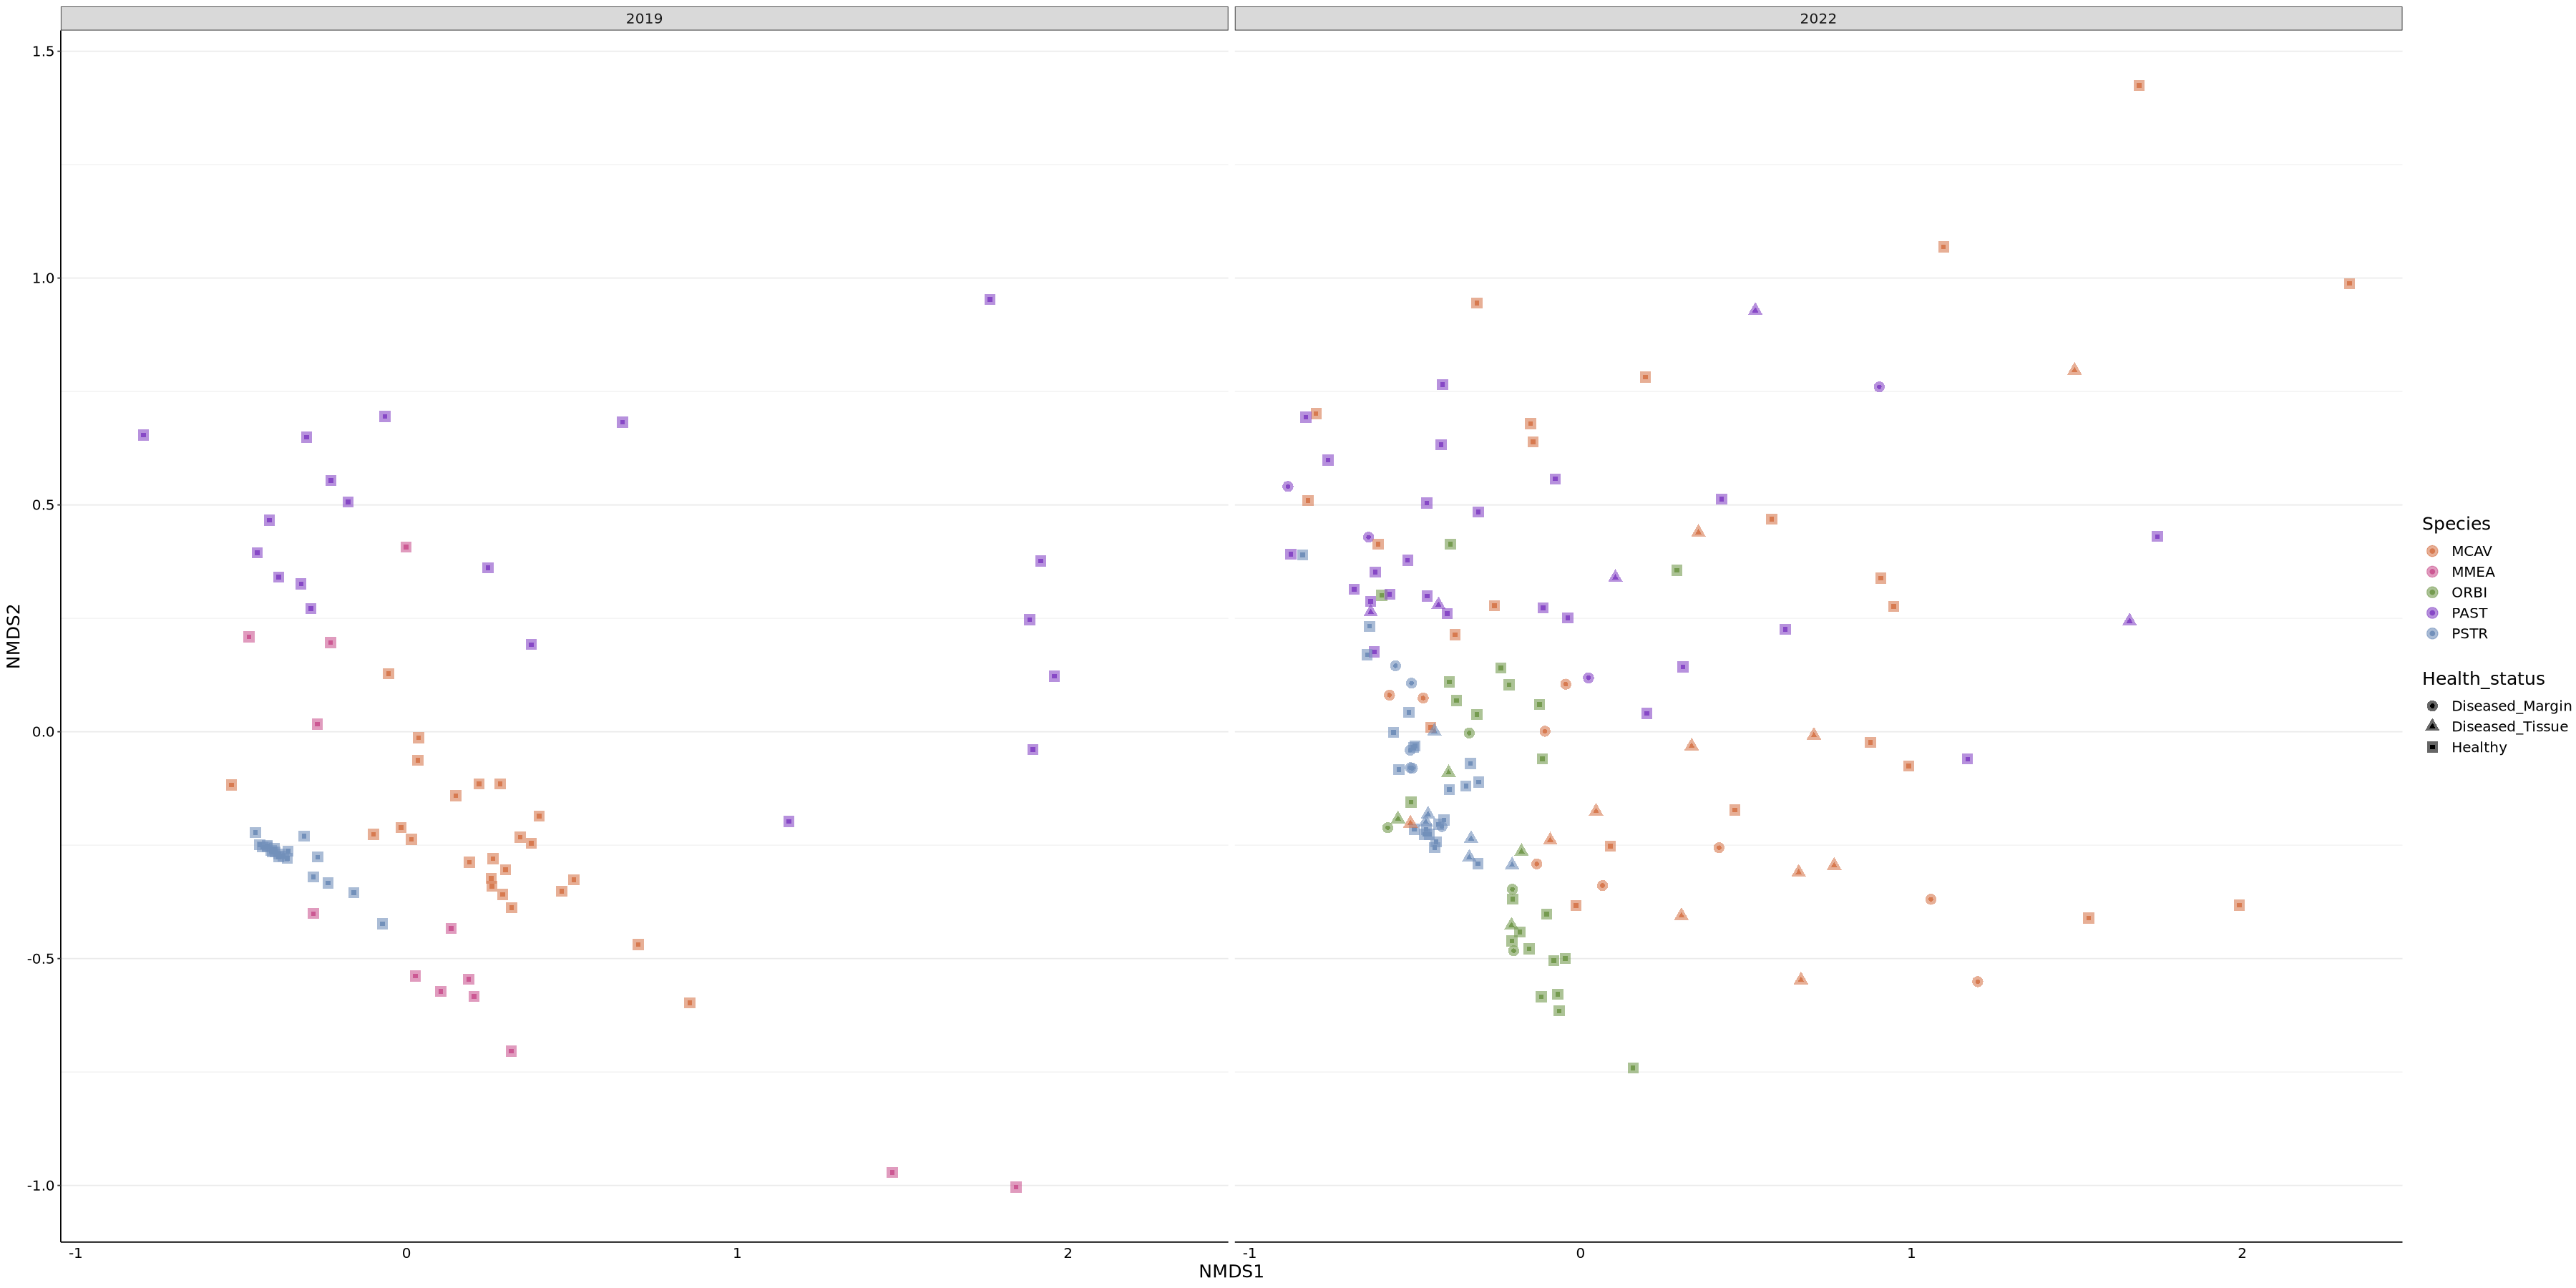

In [164]:
# facet by year
sctld_raw_plot <- plot_ordination(sctld_raw2, sctld_raw2.ord, type="samples", color="Species", shape="Health_status")+
geom_point(size=4, alpha = 0.6) + 
# scale_color_brewer(palette = "Dark2")+
scale_color_manual(values = custom_list)+
facet_wrap(~year)+
# geom_label(aes(label = sample_data(sctld_raw2)$sampleid), vjust = -1, color = "black") +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))
sctld_raw_plot

# all samples - separated by 2019 and 2022

In [165]:
# outliers really causing issues - see previous commits to view 
# leaving filtered out for now??

In [166]:
# 2019 only - RS
RS_ps <- subset_samples(sctld_raw2, year == "2019")
RS.ord <- ordinate(RS_ps, "NMDS", "bray", trymax=1000)

Square root transformation
Wisconsin double standardization
Run 0 stress 0.1118848 
Run 1 stress 0.1120489 
... Procrustes: rmse 0.02113517  max resid 0.08324849 
Run 2 stress 0.1128801 
Run 3 stress 0.1257032 
Run 4 stress 0.1273228 
Run 5 stress 0.1125998 
Run 6 stress 0.1226099 
Run 7 stress 0.1128801 
Run 8 stress 0.1130147 
Run 9 stress 0.1100087 
... New best solution
... Procrustes: rmse 0.02785289  max resid 0.08266901 
Run 10 stress 0.1304744 
Run 11 stress 0.1120796 
Run 12 stress 0.1259341 
Run 13 stress 0.1115637 
Run 14 stress 0.1222779 
Run 15 stress 0.1363603 
Run 16 stress 0.1253849 
Run 17 stress 0.1222769 
Run 18 stress 0.1126327 
Run 19 stress 0.1318827 
Run 20 stress 0.1100087 
... New best solution
... Procrustes: rmse 9.096929e-05  max resid 0.0003585073 
... Similar to previous best
*** Best solution repeated 1 times


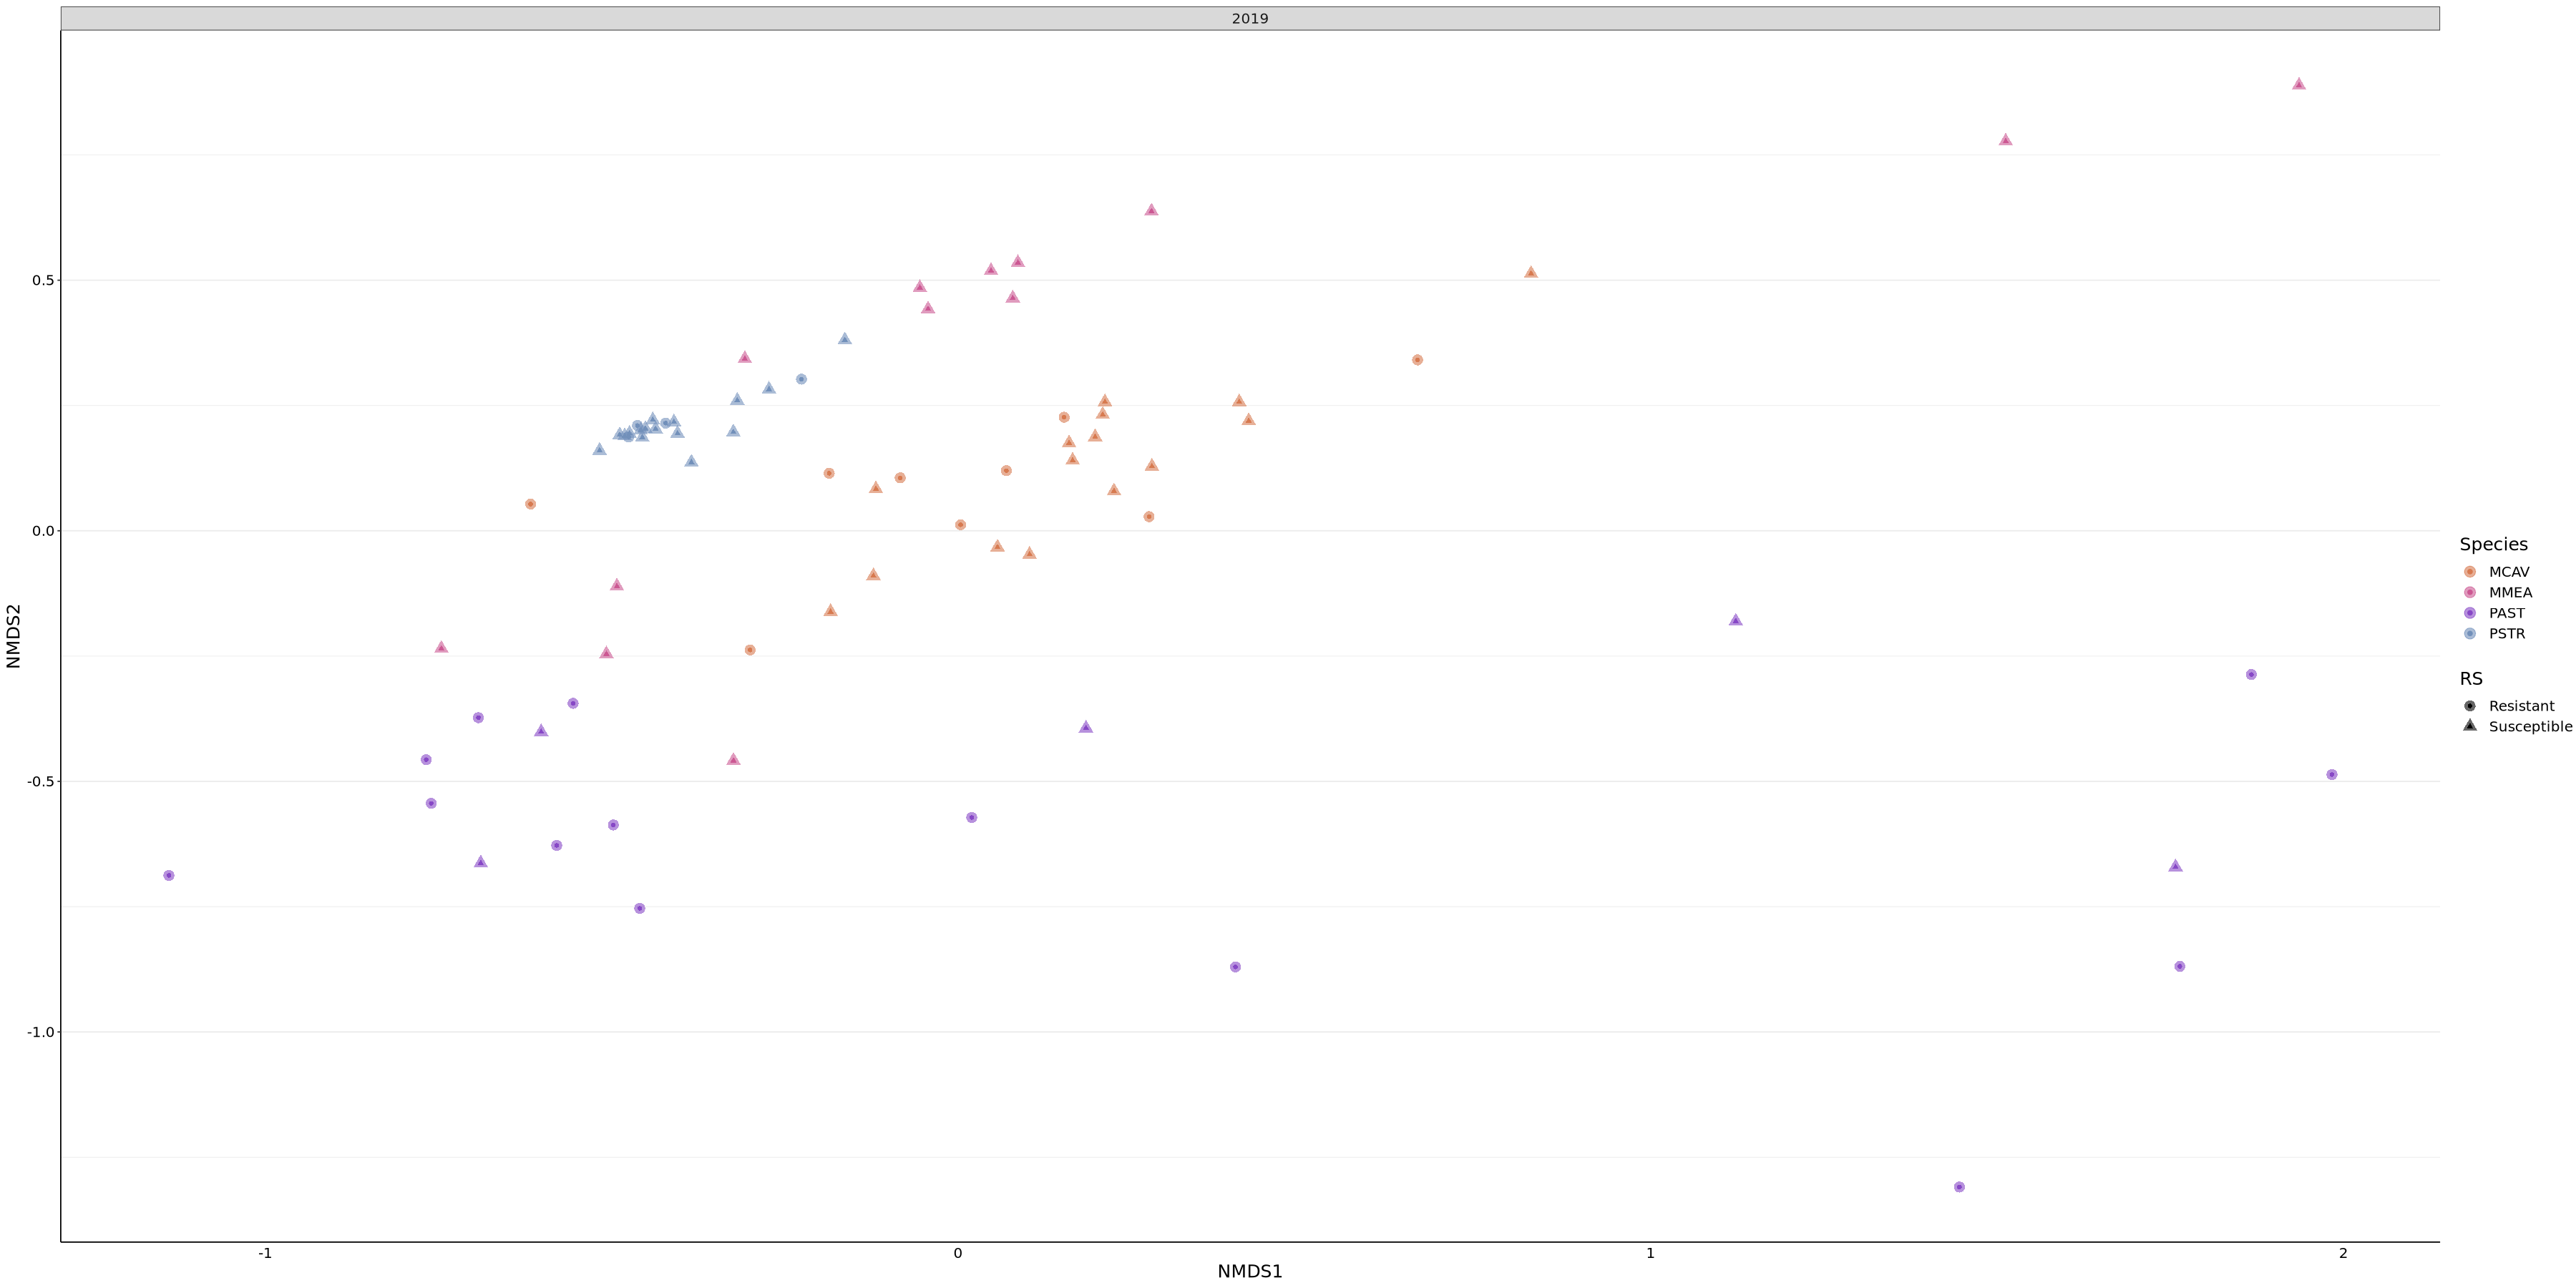

In [167]:
plot_ordination(RS_ps, RS.ord, type="samples", color="Species", shape="RS")+
geom_point(size=4, alpha = 0.6) + 
# scale_color_brewer(palette = "Dark2")+
scale_color_manual(values = custom_list)+
facet_wrap(~year)+
# geom_label(aes(label = sample_data(sctld_raw2)$sampleid), vjust = -1, color = "black") +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))

# 2019 only 

In [168]:
# ggsave(filename = "taxonomy_species_nmds.png", plot = sctld_raw_plot, 
#       width = 10,
#       height = 10,
#       units = "in",
#       dpi = 300)

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”
Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


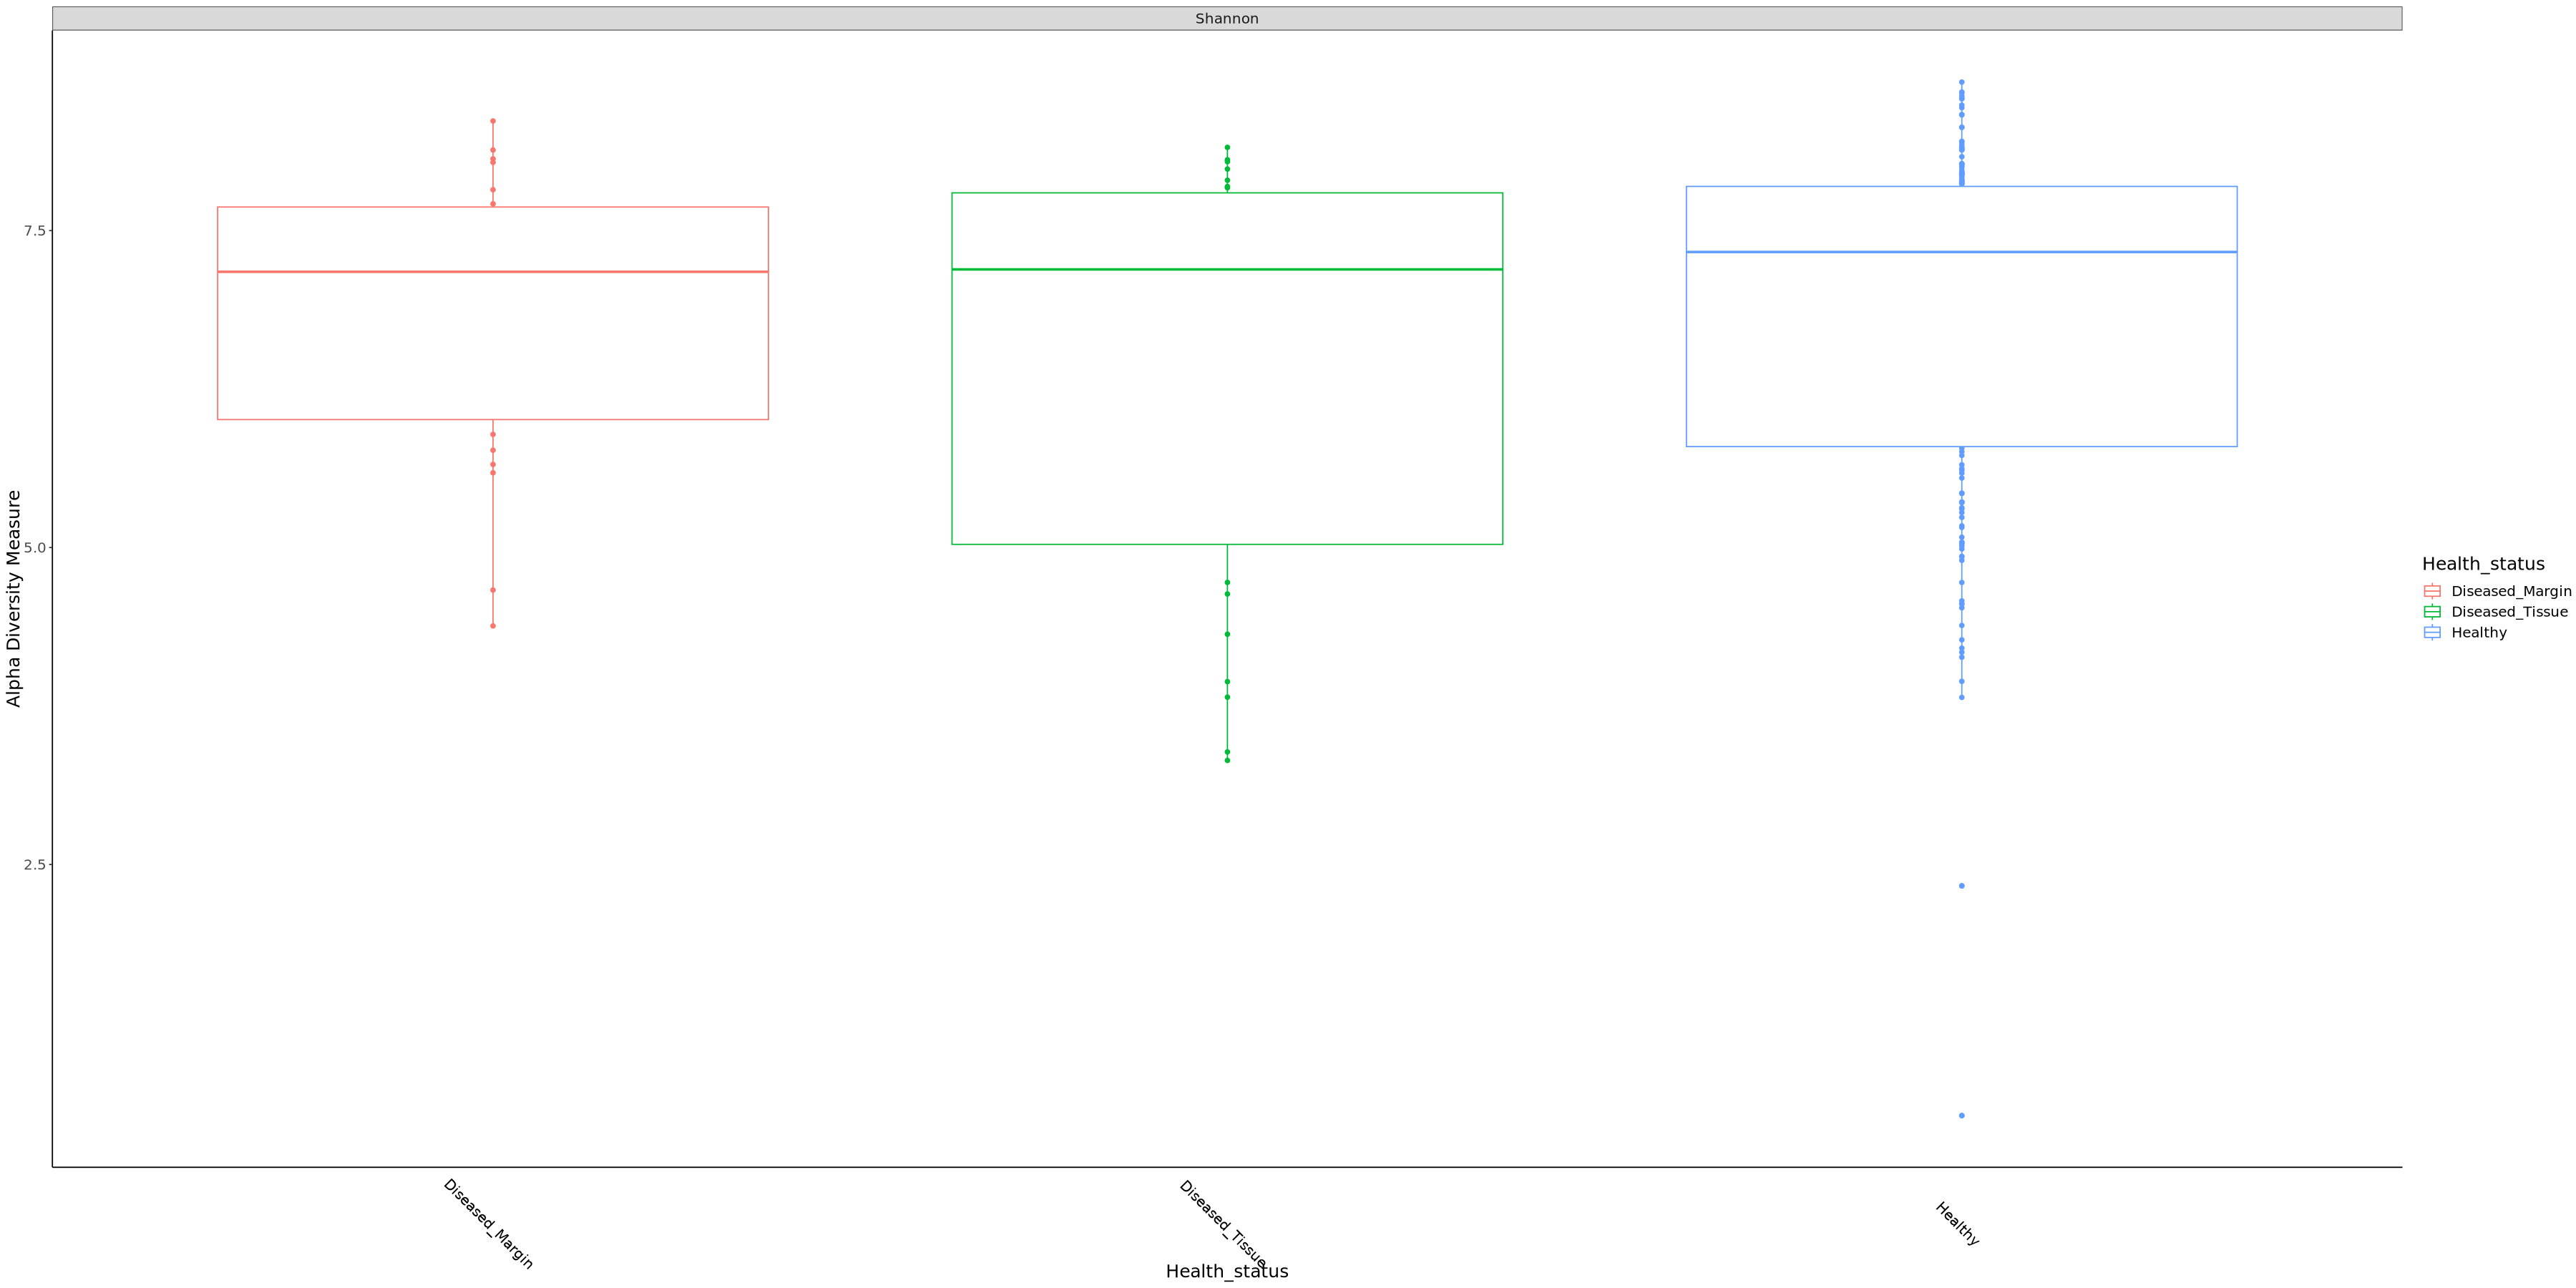

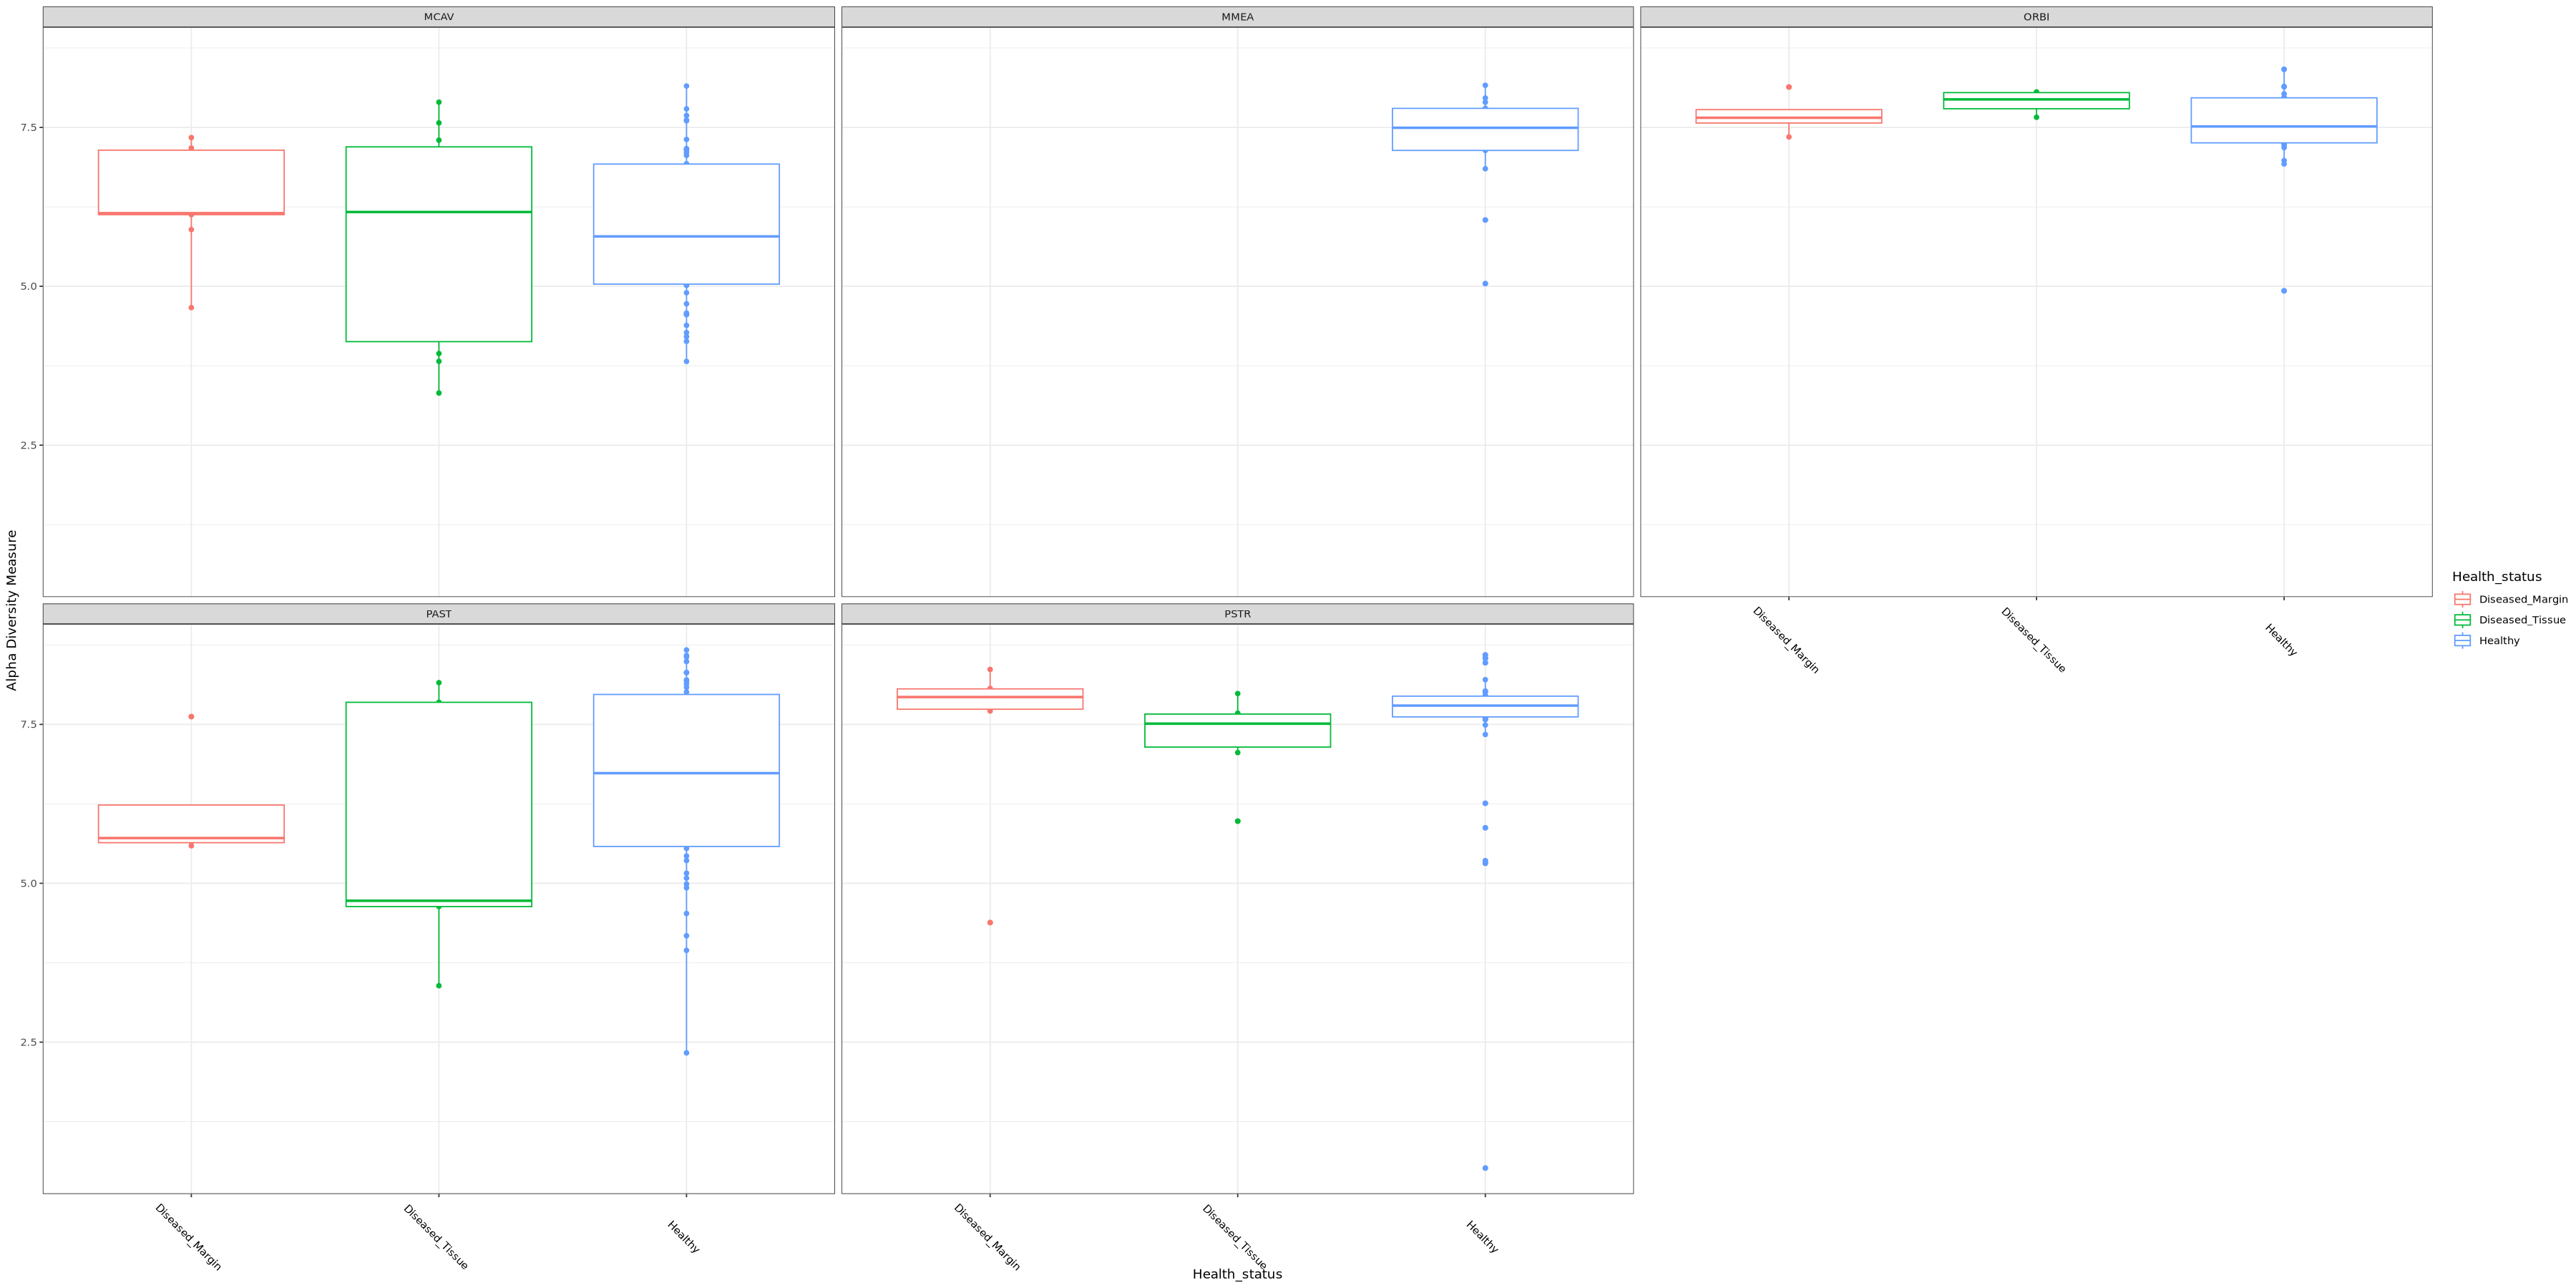

In [169]:
rich_status <- plot_richness(sctld_raw, x="Health_status", color="Health_status", measures=c("Shannon")) + 
    geom_boxplot() +
    # facet_wrap(~Species)+
    theme_bw()+
     theme(legend.position = "right",
        panel.border = element_blank(),
        panel.grid.major.x = element_blank(),
        panel.grid.minor.x = element_blank(),
        panel.grid.major.y = element_blank(),
        panel.grid.minor.y = element_blank(),
        axis.ticks.x = element_blank(),
        axis.line = element_line(color = "black"),
        axis.text.x = element_text(color = "black", angle = -45, hjust = 0.5),
        text = element_text(size = 15))
rich_status

plot_richness(sctld_raw, x="Health_status", color="Health_status", measures=c("Shannon")) + 
geom_boxplot() +
facet_wrap(~Species)+
theme_bw()+
theme(axis.text.x = element_text(color = "black", angle = -45, hjust = 0.5))

In [170]:
# ggsave(filename = "shannon_richness_sample_type.png", plot = rich_status, 
#       width = 10,
#       height = 10,
#       units = "in",
#       dpi = 300)

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


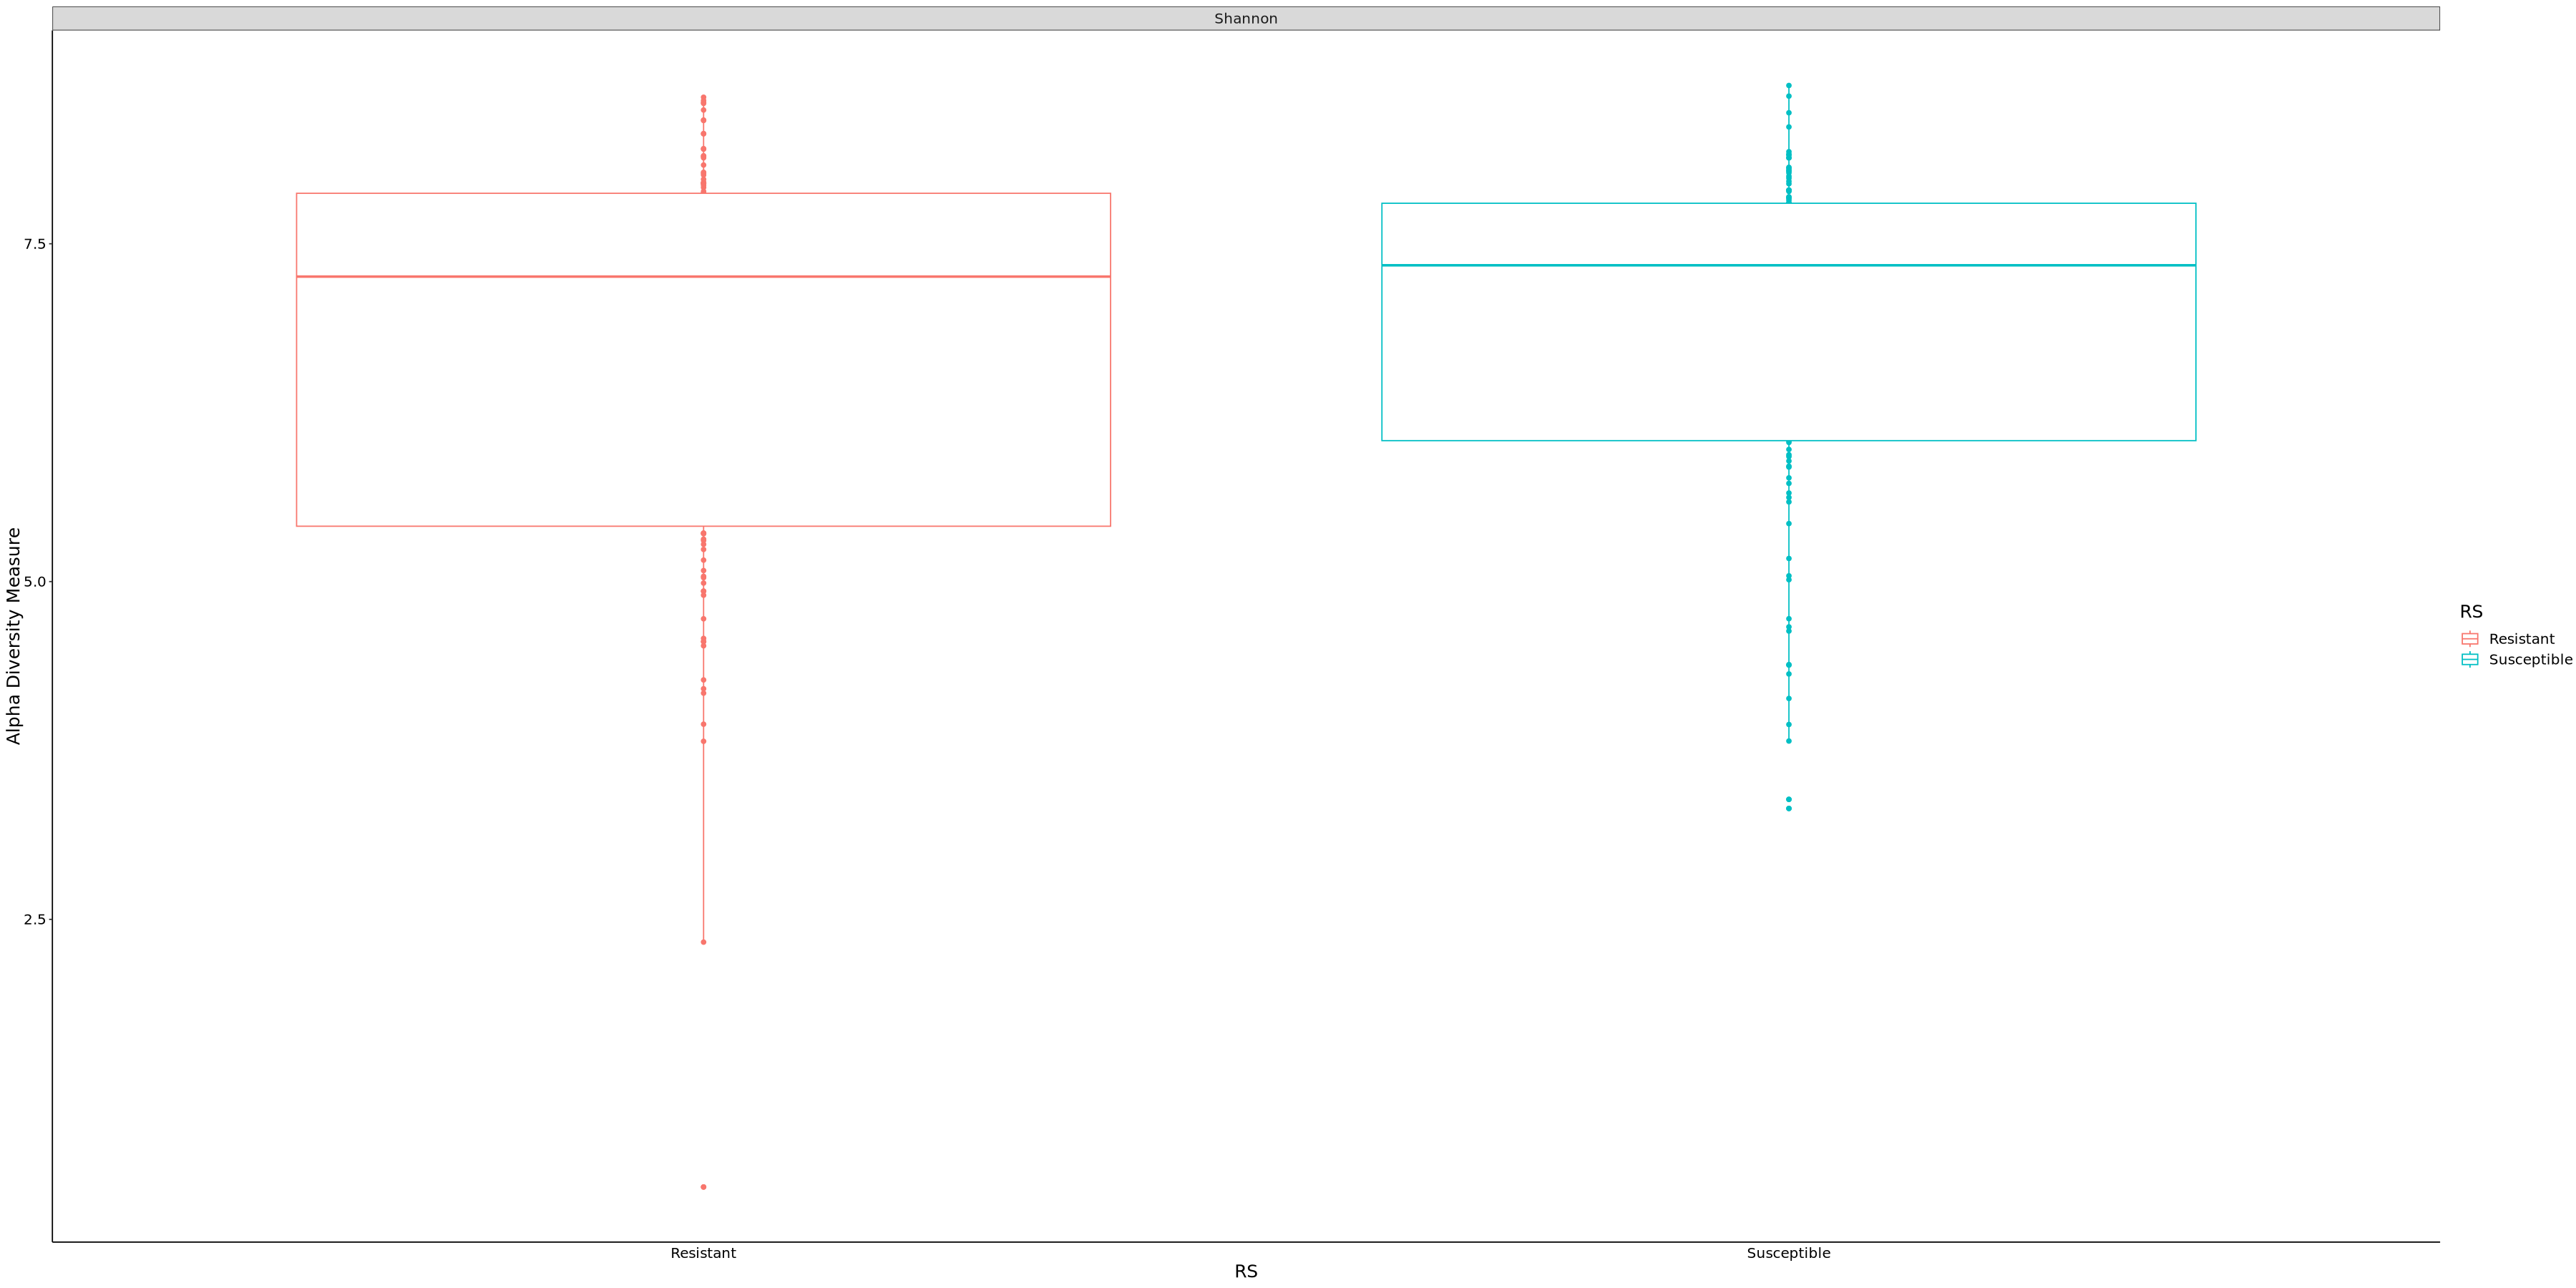

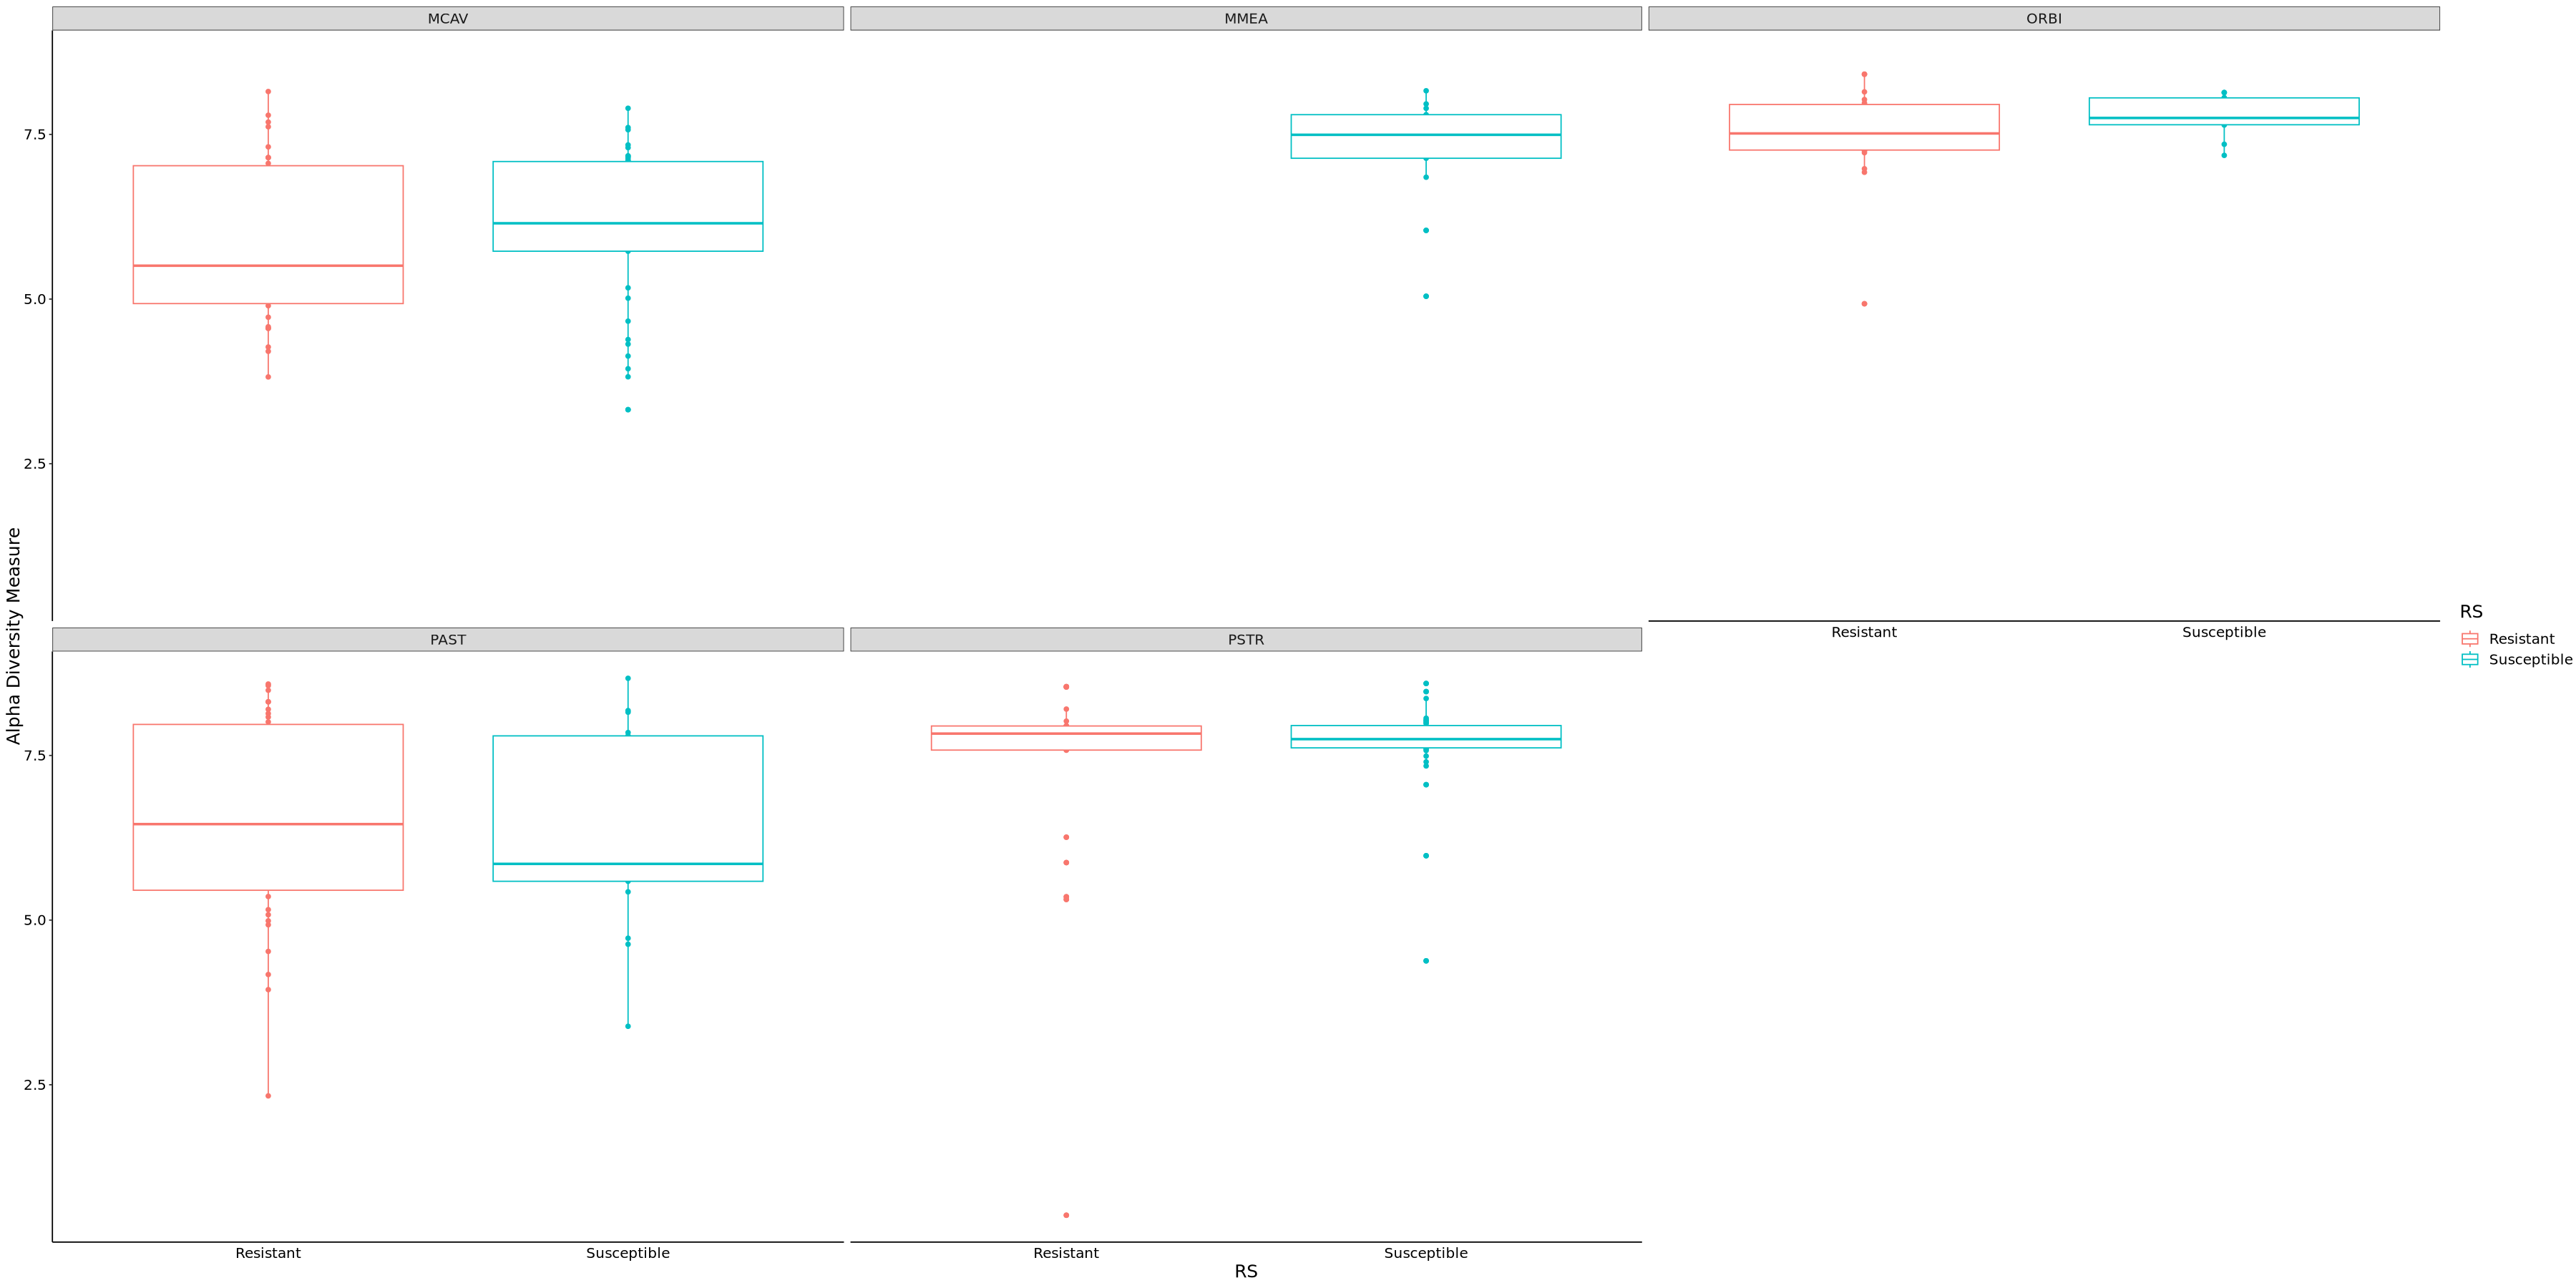

In [171]:
rich_status1 <- plot_richness(sctld_raw, x="RS", color="RS", measures=c("Shannon")) + geom_boxplot() +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))
rich_status1

rich_status1+
    facet_wrap(~Species)

In [172]:
options(repr.plot.width=15, repr.plot.height=10)

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


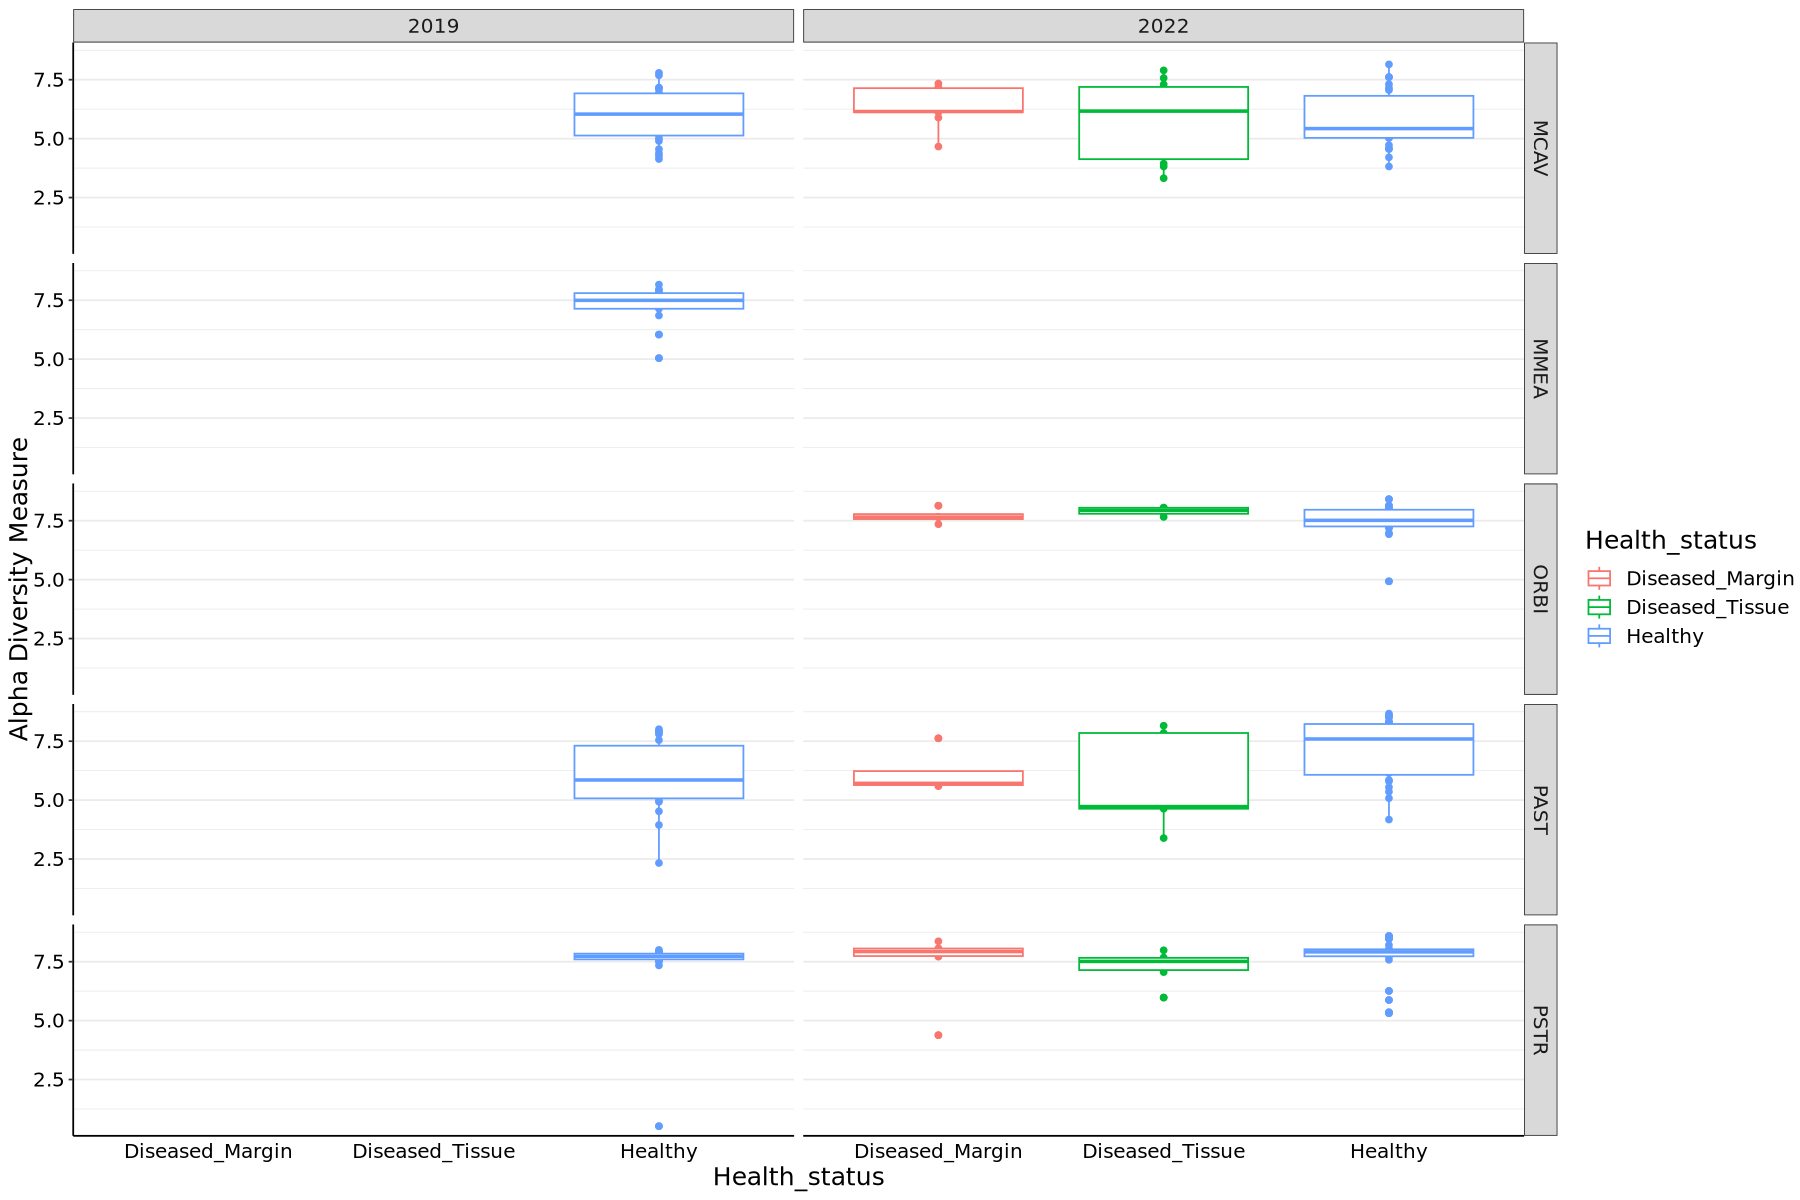

In [173]:
rich_species <- plot_richness(sctld_raw, x="Health_status", color="Health_status", measures=c("Shannon")) + geom_boxplot() +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))

rich_species+
    facet_grid(Species~year)

In [174]:
# Calculate the Bray-Curtis distance matrix
bray_dist <- phyloseq::distance(sctld_raw2, method = "bray")
metadata2 <- as(phyloseq::sample_data(sctld_raw2), "data.frame")

In [175]:
permanova <- vegan::adonis2(bray_dist ~ RS * Species * year, data = metadata2, permutations = 999)
print(permanova)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ RS * Species * year, data = metadata2, permutations = 999)
                 Df SumOfSqs      R2       F Pr(>F)    
RS                1    0.908 0.01541  4.4738  0.001 ***
Species           4   13.706 0.23267 16.8833  0.001 ***
year              1    1.573 0.02671  7.7521  0.001 ***
RS:Species        3    0.626 0.01062  1.0274  0.392    
RS:year           1    0.160 0.00271  0.7864  0.633    
Species:year      2    0.997 0.01693  2.4572  0.002 ** 
RS:Species:year   2    0.346 0.00588  0.8526  0.630    
Residual        200   40.590 0.68907                   
Total           214   58.906 1.00000                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [176]:
# Specie explains 28% variation
# RS only 2% but is significant
# year also only 2% but is significant
# Species * year is significant factor - variation between years depending on the species

In [177]:
permanova2 <- vegan::adonis2(bray_dist ~ Health_status * RS * Species * year, data = metadata2, permutations = 999)
print(permanova2)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Species * year, data = metadata2, permutations = 999)
                       Df SumOfSqs      R2       F Pr(>F)    
Health_status           2    0.784 0.01331  1.9513  0.013 *  
RS                      1    1.334 0.02264  6.6388  0.001 ***
Species                 4   13.539 0.22983 16.8458  0.001 ***
year                    1    1.165 0.01978  5.7982  0.001 ***
Health_status:Species   6    1.229 0.02086  1.0191  0.411    
RS:Species              3    0.553 0.00938  0.9170  0.600    
RS:year                 1    0.263 0.00447  1.3109  0.191    
Species:year            2    1.018 0.01728  2.5327  0.003 ** 
RS:Species:year         2    0.445 0.00756  1.1082  0.302    
Residual              192   38.576 0.65488                   
Total                 214   58.906 1.00000                   
---
Sign

In [178]:
# ok good adding health status shows similar results 
# health status is also significant effect (1.5% variation) 

In [179]:
permanova3 <- vegan::adonis2(bray_dist ~ Health_status * RS * Species * year * Transect, data = metadata2, permutations = 999)
print(permanova3)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Species * year * Transect, data = metadata2, permutations = 999)
                                Df SumOfSqs      R2       F Pr(>F)    
Health_status                    2    0.784 0.01331  1.9771  0.015 *  
RS                               1    1.334 0.02264  6.7264  0.001 ***
Species                          4   13.539 0.22983 17.0680  0.001 ***
year                             1    1.165 0.01978  5.8747  0.001 ***
Transect                         3    1.140 0.01935  1.9161  0.003 ** 
Health_status:Species            6    1.210 0.02055  1.0172  0.406    
RS:Species                       3    0.548 0.00930  0.9213  0.545    
RS:year                          1    0.224 0.00380  1.1278  0.286    
Species:year                     2    0.997 0.01692  2.5136  0.002 ** 
Health_status:Transect         

In [180]:
# location is more important than health status?

In [181]:
# look at 2022 subset - how much does health status vary
dis_ps<- subset_samples(sctld_raw2, year == '2022')
bray_dist <- phyloseq::distance(dis_ps, method = "bray")
dis_meta <- as(phyloseq::sample_data(dis_ps), "data.frame")
dis_perma <- vegan::adonis2(bray_dist ~ Health_status * Species * Transect, data = dis_meta, permutations = 999)
print(dis_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * Species * Transect, data = dis_meta, permutations = 999)
                                Df SumOfSqs      R2       F Pr(>F)    
Health_status                    2    0.846 0.02168  1.9748  0.004 ** 
Species                          3    8.387 0.21483 13.0443  0.001 ***
Transect                         3    1.350 0.03457  2.0993  0.003 ** 
Health_status:Species            6    1.370 0.03509  1.0652  0.336    
Health_status:Transect           6    1.293 0.03312  1.0055  0.473    
Species:Transect                 8    2.496 0.06393  1.4557  0.011 *  
Health_status:Species:Transect  10    1.866 0.04780  0.8707  0.810    
Residual                       100   21.433 0.54898                   
Total                          138   39.041 1.00000                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 

In [182]:
# species is more important than health status - same as from prelim results

In [183]:
# within species, how much does RS explain difference

In [184]:
mcav_ps<- subset_samples(sctld_raw2, Species == "MCAV")
bray_dist <- phyloseq::distance(mcav_ps, method = "bray")
mcav_meta <- as(phyloseq::sample_data(mcav_ps), "data.frame")
mcav_perma <- vegan::adonis2(bray_dist ~ Health_status * RS * year * Transect, data = mcav_meta, permutations = 999)
print(mcav_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * year * Transect, data = mcav_meta, permutations = 999)
                       Df SumOfSqs      R2      F Pr(>F)    
Health_status           2   0.4506 0.02868 1.0597  0.351    
RS                      1   0.3555 0.02263 1.6724  0.095 .  
year                    1   0.9035 0.05750 4.2497  0.001 ***
Transect                3   0.8867 0.05643 1.3903  0.120    
RS:year                 1   0.3862 0.02458 1.8166  0.072 .  
Health_status:Transect  4   1.1440 0.07281 1.3453  0.105    
RS:Transect             2   0.2743 0.01746 0.6451  0.857    
year:Transect           2   0.6829 0.04346 1.6061  0.059 .  
Residual               50  10.6296 0.67647                  
Total                  66  15.7132 1.00000                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [185]:
# look at 2022 subset - how much does health status vary
mcav_ps<- subset_samples(sctld_raw2, Species == "MCAV" & year == '2022')
bray_dist <- phyloseq::distance(mcav_ps, method = "bray")
mcav_meta <- as(phyloseq::sample_data(mcav_ps), "data.frame")
mcav_perma <- vegan::adonis2(bray_dist ~ Health_status * RS * Transect, data = mcav_meta, permutations = 999)
print(mcav_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Transect, data = mcav_meta, permutations = 999)
                       Df SumOfSqs      R2      F Pr(>F)  
Health_status           2   0.7896 0.07002 1.6053  0.054 .
RS                      1   0.4209 0.03733 1.7114  0.068 .
Transect                3   1.0312 0.09145 1.3977  0.098 .
Health_status:Transect  4   1.1649 0.10331 1.1842  0.203  
Residual               32   7.8695 0.69790                
Total                  42  11.2760 1.00000                
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [186]:
orbi_ps<- subset_samples(sctld_raw2, Species == "ORBI")
bray_dist <- phyloseq::distance(orbi_ps, method = "bray")
orbi_meta <- as(phyloseq::sample_data(orbi_ps), "data.frame")
orbi_perma <- vegan::adonis2(bray_dist ~ Health_status * RS * Transect, data = orbi_meta, permutations = 999)
print(orbi_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Transect, data = orbi_meta, permutations = 999)
                       Df SumOfSqs      R2      F Pr(>F)  
Health_status           2   0.3594 0.07663 1.1741  0.251  
RS                      1   0.1244 0.02652 0.8127  0.523  
Transect                3   0.8276 0.17645 1.8023  0.030 *
Health_status:Transect  4   0.4714 0.10050 0.7699  0.732  
RS:Transect             1   0.1525 0.03251 0.9961  0.401  
Residual               18   2.7552 0.58739                
Total                  29   4.6906 1.00000                
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [187]:
# maybe we do need to separate out orbi species...

### DESeq2 R vs S 2019

In [155]:
#run DESeq2 on 2019 R vs S across species
## ALL SPECIES TOGETHER

ds_all = phyloseq_to_deseq2(RS_ps, ~ RS)
ds_all = DESeq(ds_all, test="Wald", fitType="parametric")
res = results(ds_all, cooksCutoff = FALSE, contrast=c("RS", "Resistant", "Susceptible"))
alpha = 0.00001
sigtab_a = res[which(res$padj < alpha), ]
sigtab_all = cbind(as(sigtab_a, "data.frame"), as(tax_table(RS_ps)[rownames(sigtab_a), ], "matrix"))
res
head(sigtab_all)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 3374 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



log2 fold change (MLE): RS Resistant vs Susceptible 
Wald test p-value: RS Resistant vs Susceptible 
DataFrame with 15891 rows and 6 columns
         baseMean log2FoldChange     lfcSE      stat      pvalue       padj
        <numeric>      <numeric> <numeric> <numeric>   <numeric>  <numeric>
2057741 47540.335       2.161694  0.595158  3.632137 0.000281084 0.00889593
1747    26951.405       1.697046  0.717317  2.365823 0.017990040 0.09771910
1929291   479.589       0.895441  0.599717  1.493107 0.135409204 0.25594309
1325120  9164.518       2.281582  0.625871  3.645453 0.000266922 0.00852450
3101350   110.081       0.550736  0.622481  0.884745 0.376294351 0.49640333
...           ...            ...       ...       ...         ...        ...
3048446         0             NA        NA        NA          NA         NA
3432130         0             NA        NA        NA          NA         NA
2843718         0             NA        NA        NA          NA         NA
889953          0      

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species,domain,kingdom,phylum,class,order,family,genus
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
3101276,299.96389,3.780782,0.6290041,6.010743,1.846748e-09,5.897843e-07,Candidatus Poriferisocius sp.,Bacteria,Bacillati,Actinomycetota,Acidimicrobiia,Acidimicrobiales,Candidatus_Hopanoidivoransaceae,Candidatus_Poriferisocius
2866199,46.32265,27.655568,3.0286197,9.131410,6.761281e-20,3.958730e-17,Bradyrhizobium sp. ISRA463,Bacteria,Pseudomonadati,Pseudomonadota,Alphaproteobacteria,Hyphomicrobiales,Nitrobacteraceae,Bradyrhizobium
2866200,149.79450,29.264373,3.0285163,9.662940,4.332468e-22,3.043992e-19,Bradyrhizobium sp. ISRA464,Bacteria,Pseudomonadati,Pseudomonadota,Alphaproteobacteria,Hyphomicrobiales,Nitrobacteraceae,Bradyrhizobium
5665,159.71560,1.842248,0.2870719,6.417374,1.386447e-10,4.870588e-08,Leishmania mexicana,Eukaryota,Unclassified,Euglenozoa,Kinetoplastea,Trypanosomatida,Trypanosomatidae,Leishmania
2986766,39.46195,26.821334,3.0286457,8.855884,8.302355e-19,4.166596e-16,Delftia sp. UGAL515B_04,Bacteria,Pseudomonadati,Pseudomonadota,Betaproteobacteria,Burkholderiales,Comamonadaceae,Delftia
218144,372.63553,-5.827745,0.8440838,-6.904225,5.047806e-12,1.970327e-09,Vagococcus carniphilus,Bacteria,Bacillati,Bacillota,Bacilli,Lactobacillales,Enterococcaceae,Vagococcus


In [156]:
# sort by most significant 
sorted_sigtab_all <- sigtab_all %>%
  arrange(padj)
head(sorted_sigtab_all)
dim(sorted_sigtab_all)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species,domain,kingdom,phylum,class,order,family,genus
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
487698,20.17999,26.51791,2.182526,12.150101,5.729477e-34,2.012765e-30,Stenotrophomonas pavanii,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Lysobacterales,Lysobacteraceae,Stenotrophomonas
362,33.87403,27.22112,2.705916,10.059854,8.312115e-24,1.460023e-20,Agrobacterium radiobacter,Bacteria,Pseudomonadati,Pseudomonadota,Alphaproteobacteria,Hyphomicrobiales,Rhizobiaceae,Agrobacterium
199592,28.39139,26.97690,2.696427,10.004685,1.453535e-23,1.702090e-20,Microbacterium paraoxydans,Bacteria,Bacillati,Actinomycetota,Actinomycetes,Micrococcales,Microbacteriaceae,Microbacterium
2866200,149.79450,29.26437,3.028516,9.662940,4.332468e-22,3.043992e-19,Bradyrhizobium sp. ISRA464,Bacteria,Pseudomonadati,Pseudomonadota,Alphaproteobacteria,Hyphomicrobiales,Nitrobacteraceae,Bradyrhizobium
3090665,22.14652,25.98710,2.686678,9.672575,3.943272e-22,3.043992e-19,Pseudomonas sp. JS3066,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Pseudomonas
2866199,46.32265,27.65557,3.028620,9.131410,6.761281e-20,3.958730e-17,Bradyrhizobium sp. ISRA463,Bacteria,Pseudomonadati,Pseudomonadota,Alphaproteobacteria,Hyphomicrobiales,Nitrobacteraceae,Bradyrhizobium


[1] 11 14

In [157]:
# add R vs S col
sigdiff_otus<-sorted_sigtab_all %>%
    mutate(RS = if_else(log2FoldChange<0, "Susceptible","Resistant"))

In [158]:
# export sig diff taxa
# write.csv(sorted_sigtab_all, file=".csv")

In [159]:
options(repr.plot.width=15, repr.plot.height=15)

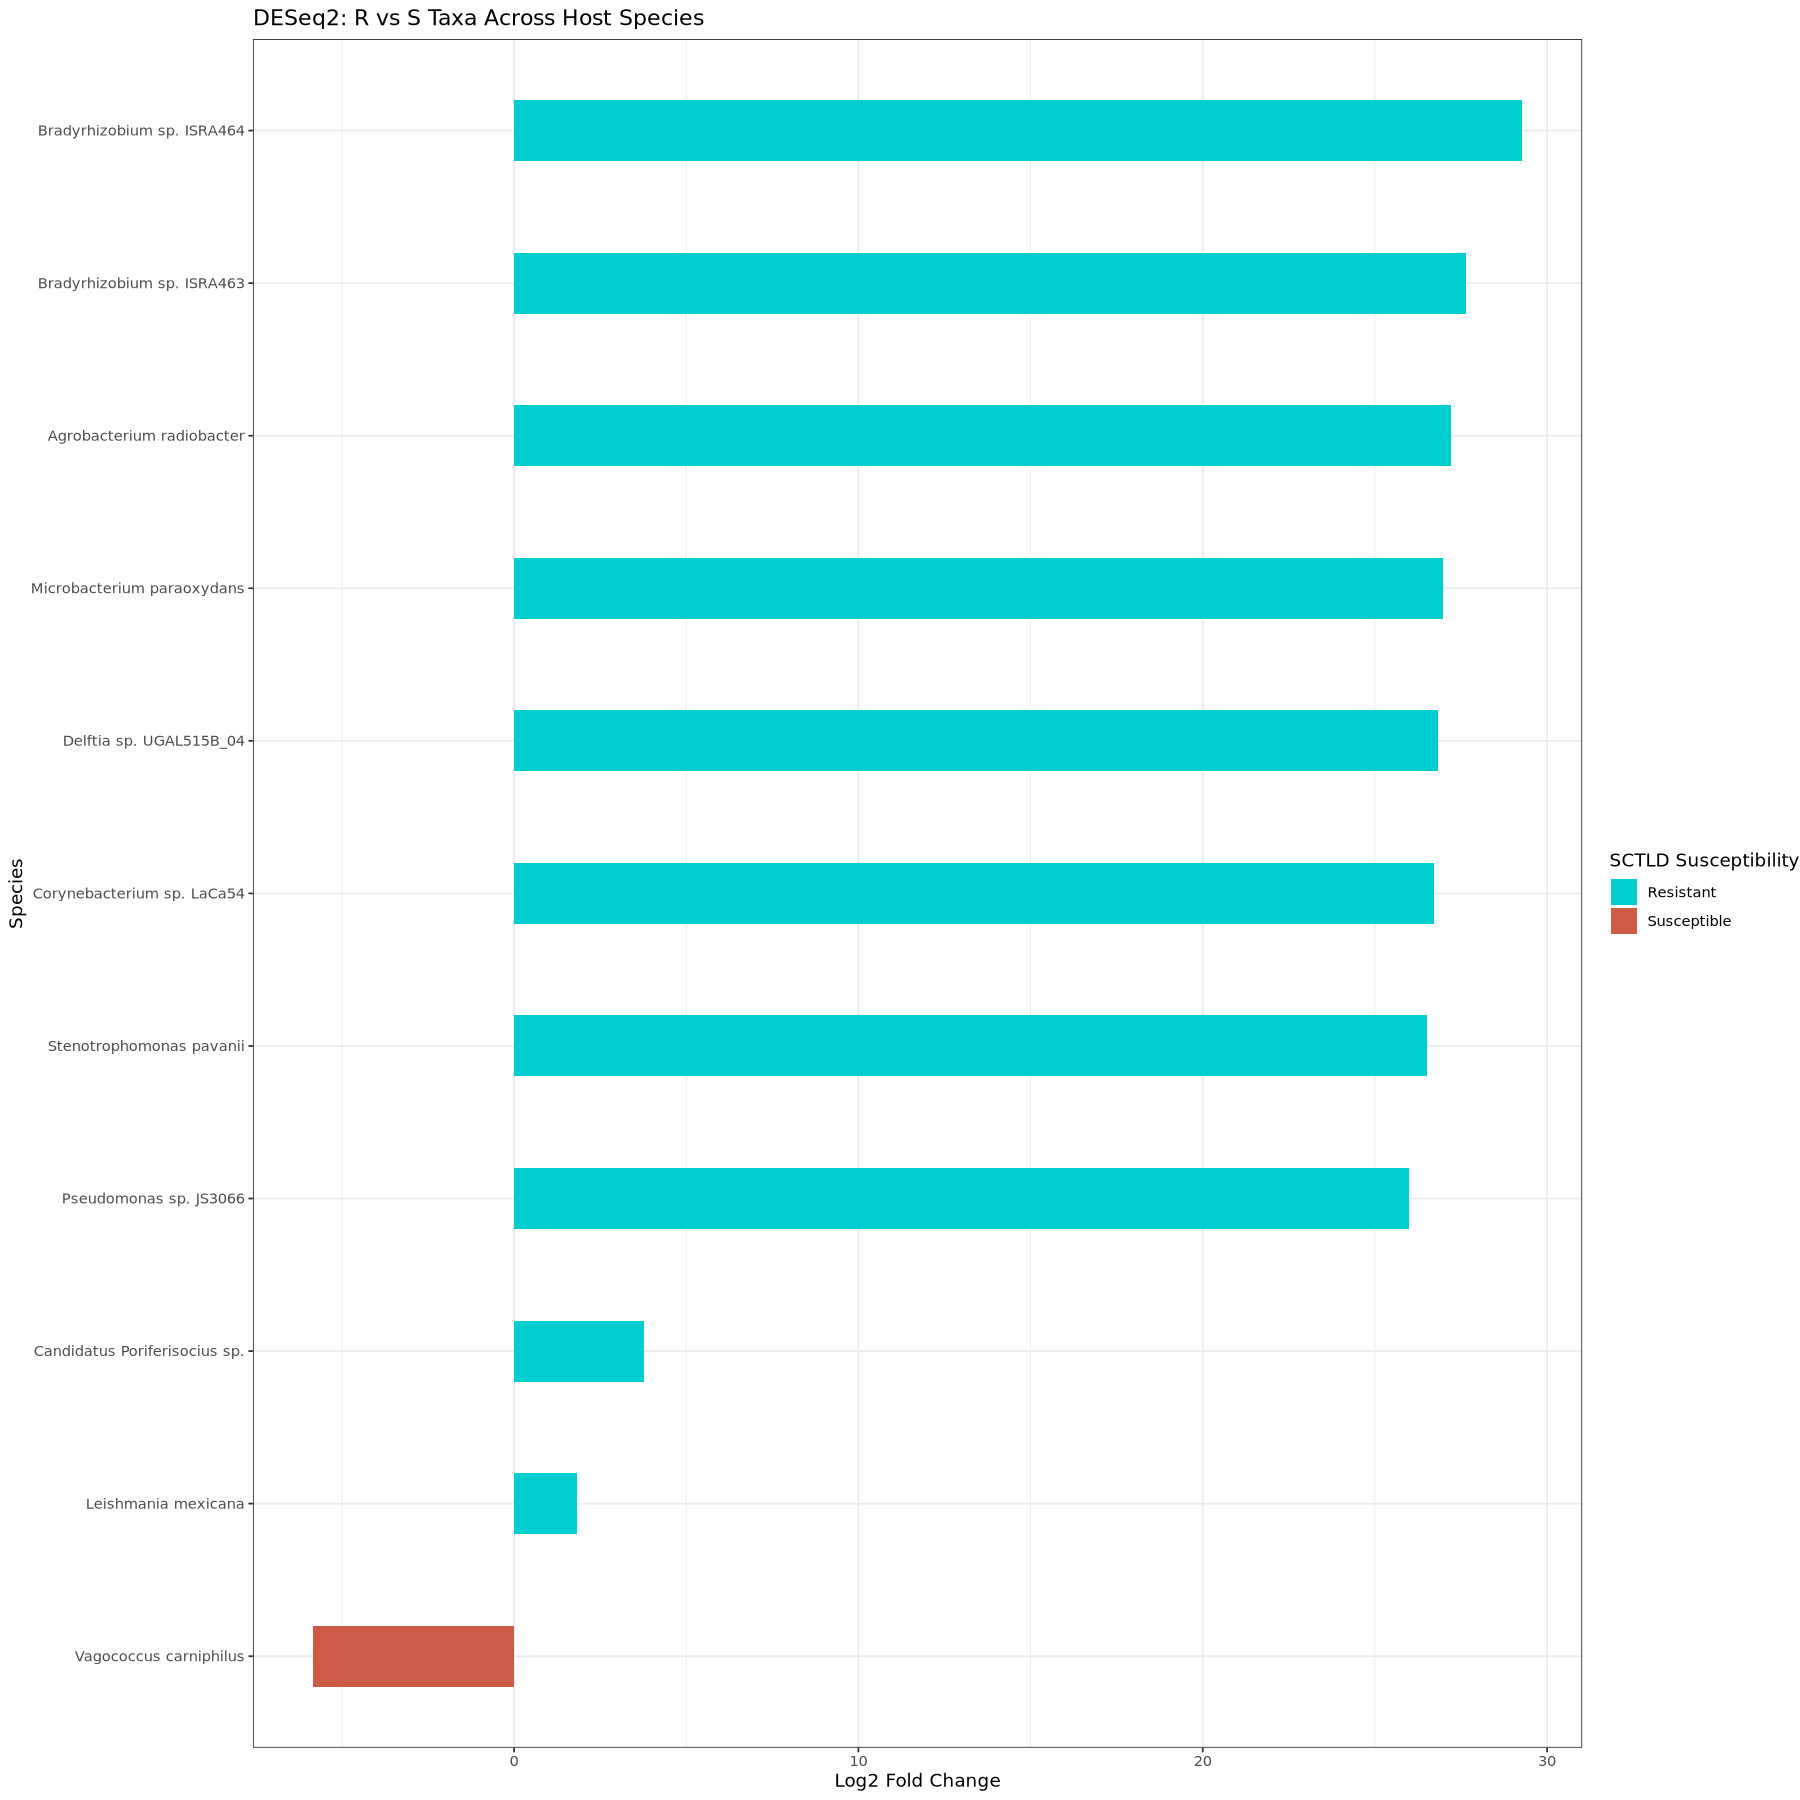

In [160]:
# plot significantly different OTUs 
ggplot(sigdiff_otus, aes(x = reorder(species,log2FoldChange), y = log2FoldChange, fill = RS)) +
    geom_bar(stat = "identity", width = 0.4) +
    coord_flip() + 
    scale_fill_manual(values= c("Resistant"="cyan3", "Susceptible"="coral3"))+
    theme_bw()+
    labs(x = "Species", y = "Log2 Fold Change", title = "DESeq2: R vs S Taxa Across Host Species", fill = "SCTLD Susceptibility")


In [161]:
# ggsave(filename = "DR_top_lfc_all_plot_HvDM_res.png", plot = top_lfc_all_plot, 
#       width = 10,
#       height = 15,
#       units = "in",
#       dpi = 300)

#### MCAV

In [162]:
#run DESeq2 on MCAV
mcav_ps<- subset_samples(RS_ps, Species == "MCAV")

mcav_rs = phyloseq_to_deseq2(mcav_ps, ~ RS)
mcav_rs = DESeq(mcav_rs, test="Wald", fitType="parametric")
res = results(mcav_rs, cooksCutoff = FALSE, contrast=c("RS", "Resistant", "Susceptible"))
alpha = 0.00001
sigtab_a = res[which(res$padj < alpha), ]
sigtab_mcav = cbind(as(sigtab_a, "data.frame"), as(tax_table(mcav_ps)[rownames(sigtab_a), ], "matrix"))

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 4251 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



In [163]:
# sort by most significant 
sigtab_mcav <- sigtab_mcav %>%
  arrange(padj)%>%
# add R vs S col
    mutate(RS = if_else(log2FoldChange<0, "Susceptible","Resistant"))
head(sigtab_mcav)
dim(sigtab_mcav)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species,domain,kingdom,phylum,class,order,family,genus,RS
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
2986766,47.764756,25.52794,2.783125,9.172402,4.625950e-20,4.213778e-16,Delftia sp. UGAL515B_04,Bacteria,Pseudomonadati,Pseudomonadota,Betaproteobacteria,Burkholderiales,Comamonadaceae,Delftia,Resistant
2866199,13.156414,23.77349,3.027202,7.853287,4.052716e-15,1.845809e-11,Bradyrhizobium sp. ISRA463,Bacteria,Pseudomonadati,Pseudomonadota,Alphaproteobacteria,Hyphomicrobiales,Nitrobacteraceae,Bradyrhizobium,Resistant
2866282,7.348293,22.91472,3.028007,7.567593,3.802025e-14,1.154422e-10,Pseudomonas sp. PS1(2021),Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Pseudomonas,Resistant
3391428,5.945158,22.65655,3.028433,7.481281,7.360180e-14,1.255811e-10,Corynebacterium sp. LaCa54,Bacteria,Bacillati,Actinomycetota,Actinomycetes,Mycobacteriales,Corynebacteriaceae,Corynebacterium,Resistant
3391431,5.658910,22.61089,3.028546,7.465921,8.271892e-14,1.255811e-10,Corynebacterium sp. LaCa97,Bacteria,Bacillati,Actinomycetota,Actinomycetes,Mycobacteriales,Corynebacteriaceae,Corynebacterium,Resistant
1701090,6.299496,22.73595,3.028311,7.507798,6.013010e-14,1.255811e-10,Gordonia hongkongensis,Bacteria,Bacillati,Actinomycetota,Actinomycetes,Mycobacteriales,Gordoniaceae,Gordonia,Resistant


[1]  7 15

In [164]:
options(repr.plot.height = 15, repr.plot.width = 15)

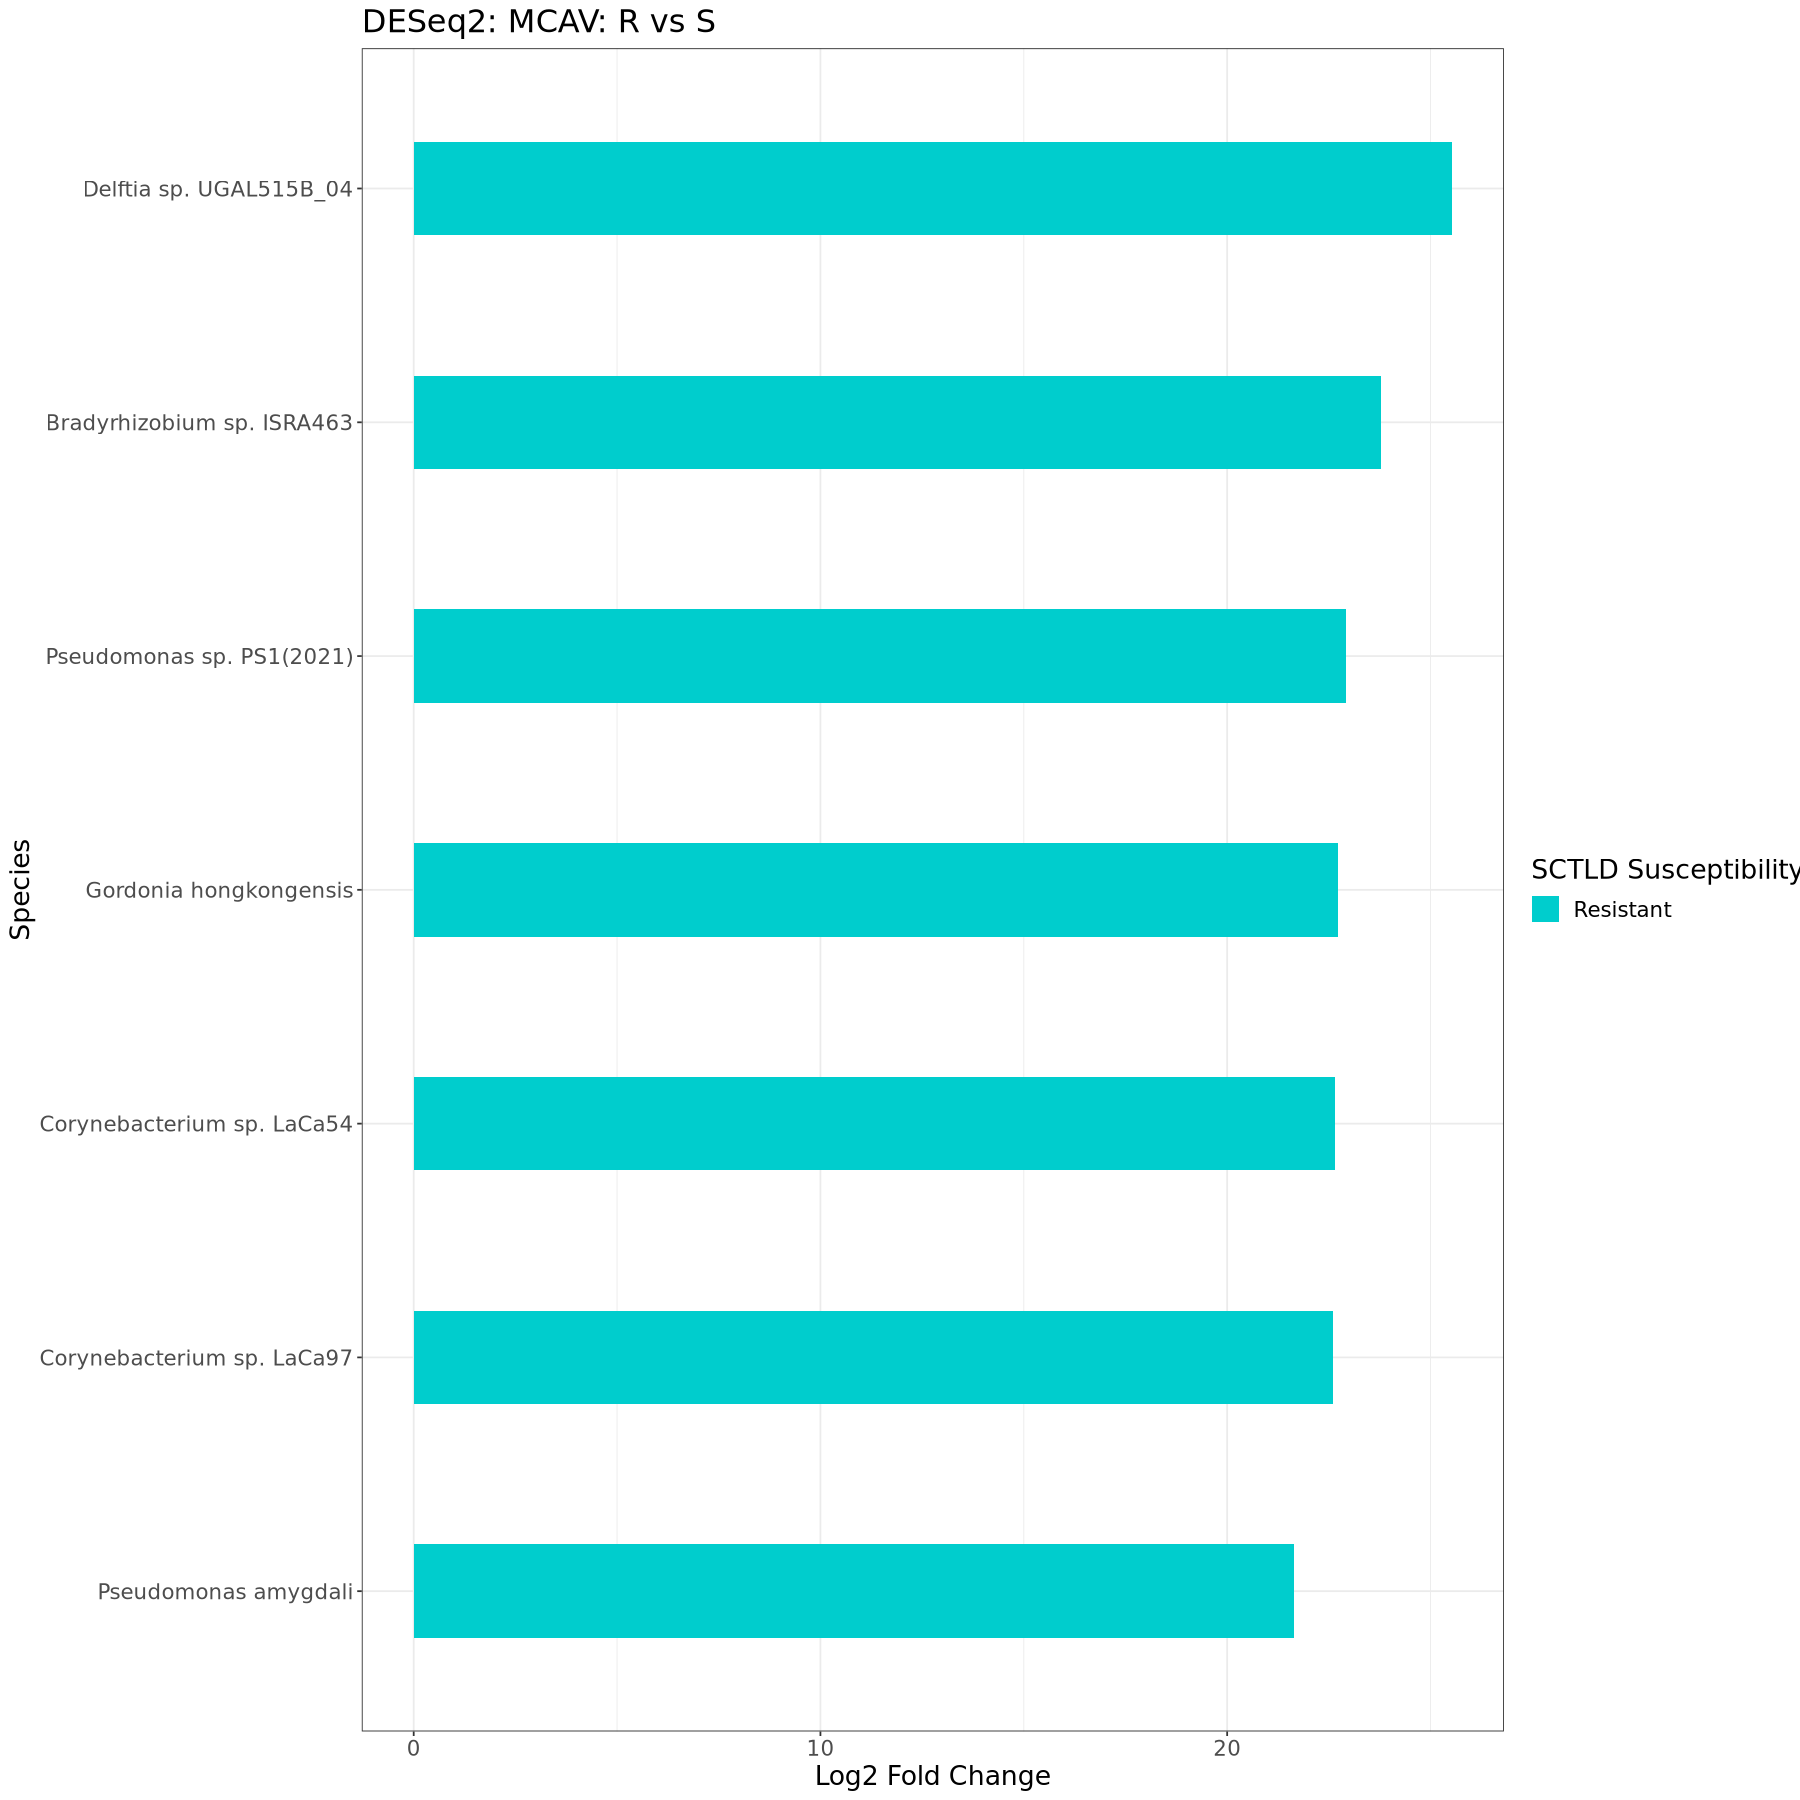

In [165]:
# plot significantly different OTUs 
ggplot(sigtab_mcav, aes(x = reorder(species,log2FoldChange), y = log2FoldChange, fill = RS)) +
    geom_bar(stat = "identity", width = 0.4) +
    coord_flip() + 
    scale_fill_manual(values= c("Resistant"="cyan3", "Susceptible"="coral3"))+
    theme_bw()+
    labs(x = "Species", y = "Log2 Fold Change", title = "DESeq2: MCAV: R vs S", fill = "SCTLD Susceptibility")+
    theme(text = element_text(size = 16)) 


In [167]:
# make phyloseq fxn
run_deseq <- function(phylo_obj, comparison, contrast1, contrast2){
    ds_formula <- as.formula(paste0("~ ", comparison))
    ps_ds = phyloseq_to_deseq2(phylo_obj, ds_formula)
    
    for_ds = DESeq(ps_ds, test="Wald", fitType="parametric")
    res = results(for_ds, cooksCutoff = FALSE, contrast=c(comparison, contrast1, contrast2))
    alpha = 0.00001
    sigtab_a = res[which(res$padj < alpha), ]
    sigtab_all = cbind(as(sigtab_a, "data.frame"), as(tax_table(phylo_obj)[rownames(sigtab_a), ], "matrix"))
    return(sigtab_all)
    }

view_ds_res<-function(sigtab_all, comparison,contrast1, contrast2){
    sigtab_res <- sigtab_all %>%
        arrange(padj)%>%
    # add contrast cols
        mutate(!!sym(comparison):= if_else(log2FoldChange<0, contrast2,contrast1))
    return(sigtab_res)
    }

#### PSTR

In [168]:
pstr_ps<- subset_samples(RS_ps, Species == "PSTR")

pstr_ds<-run_deseq(pstr_ps, "RS","Resistant","Susceptible")

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 1319 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



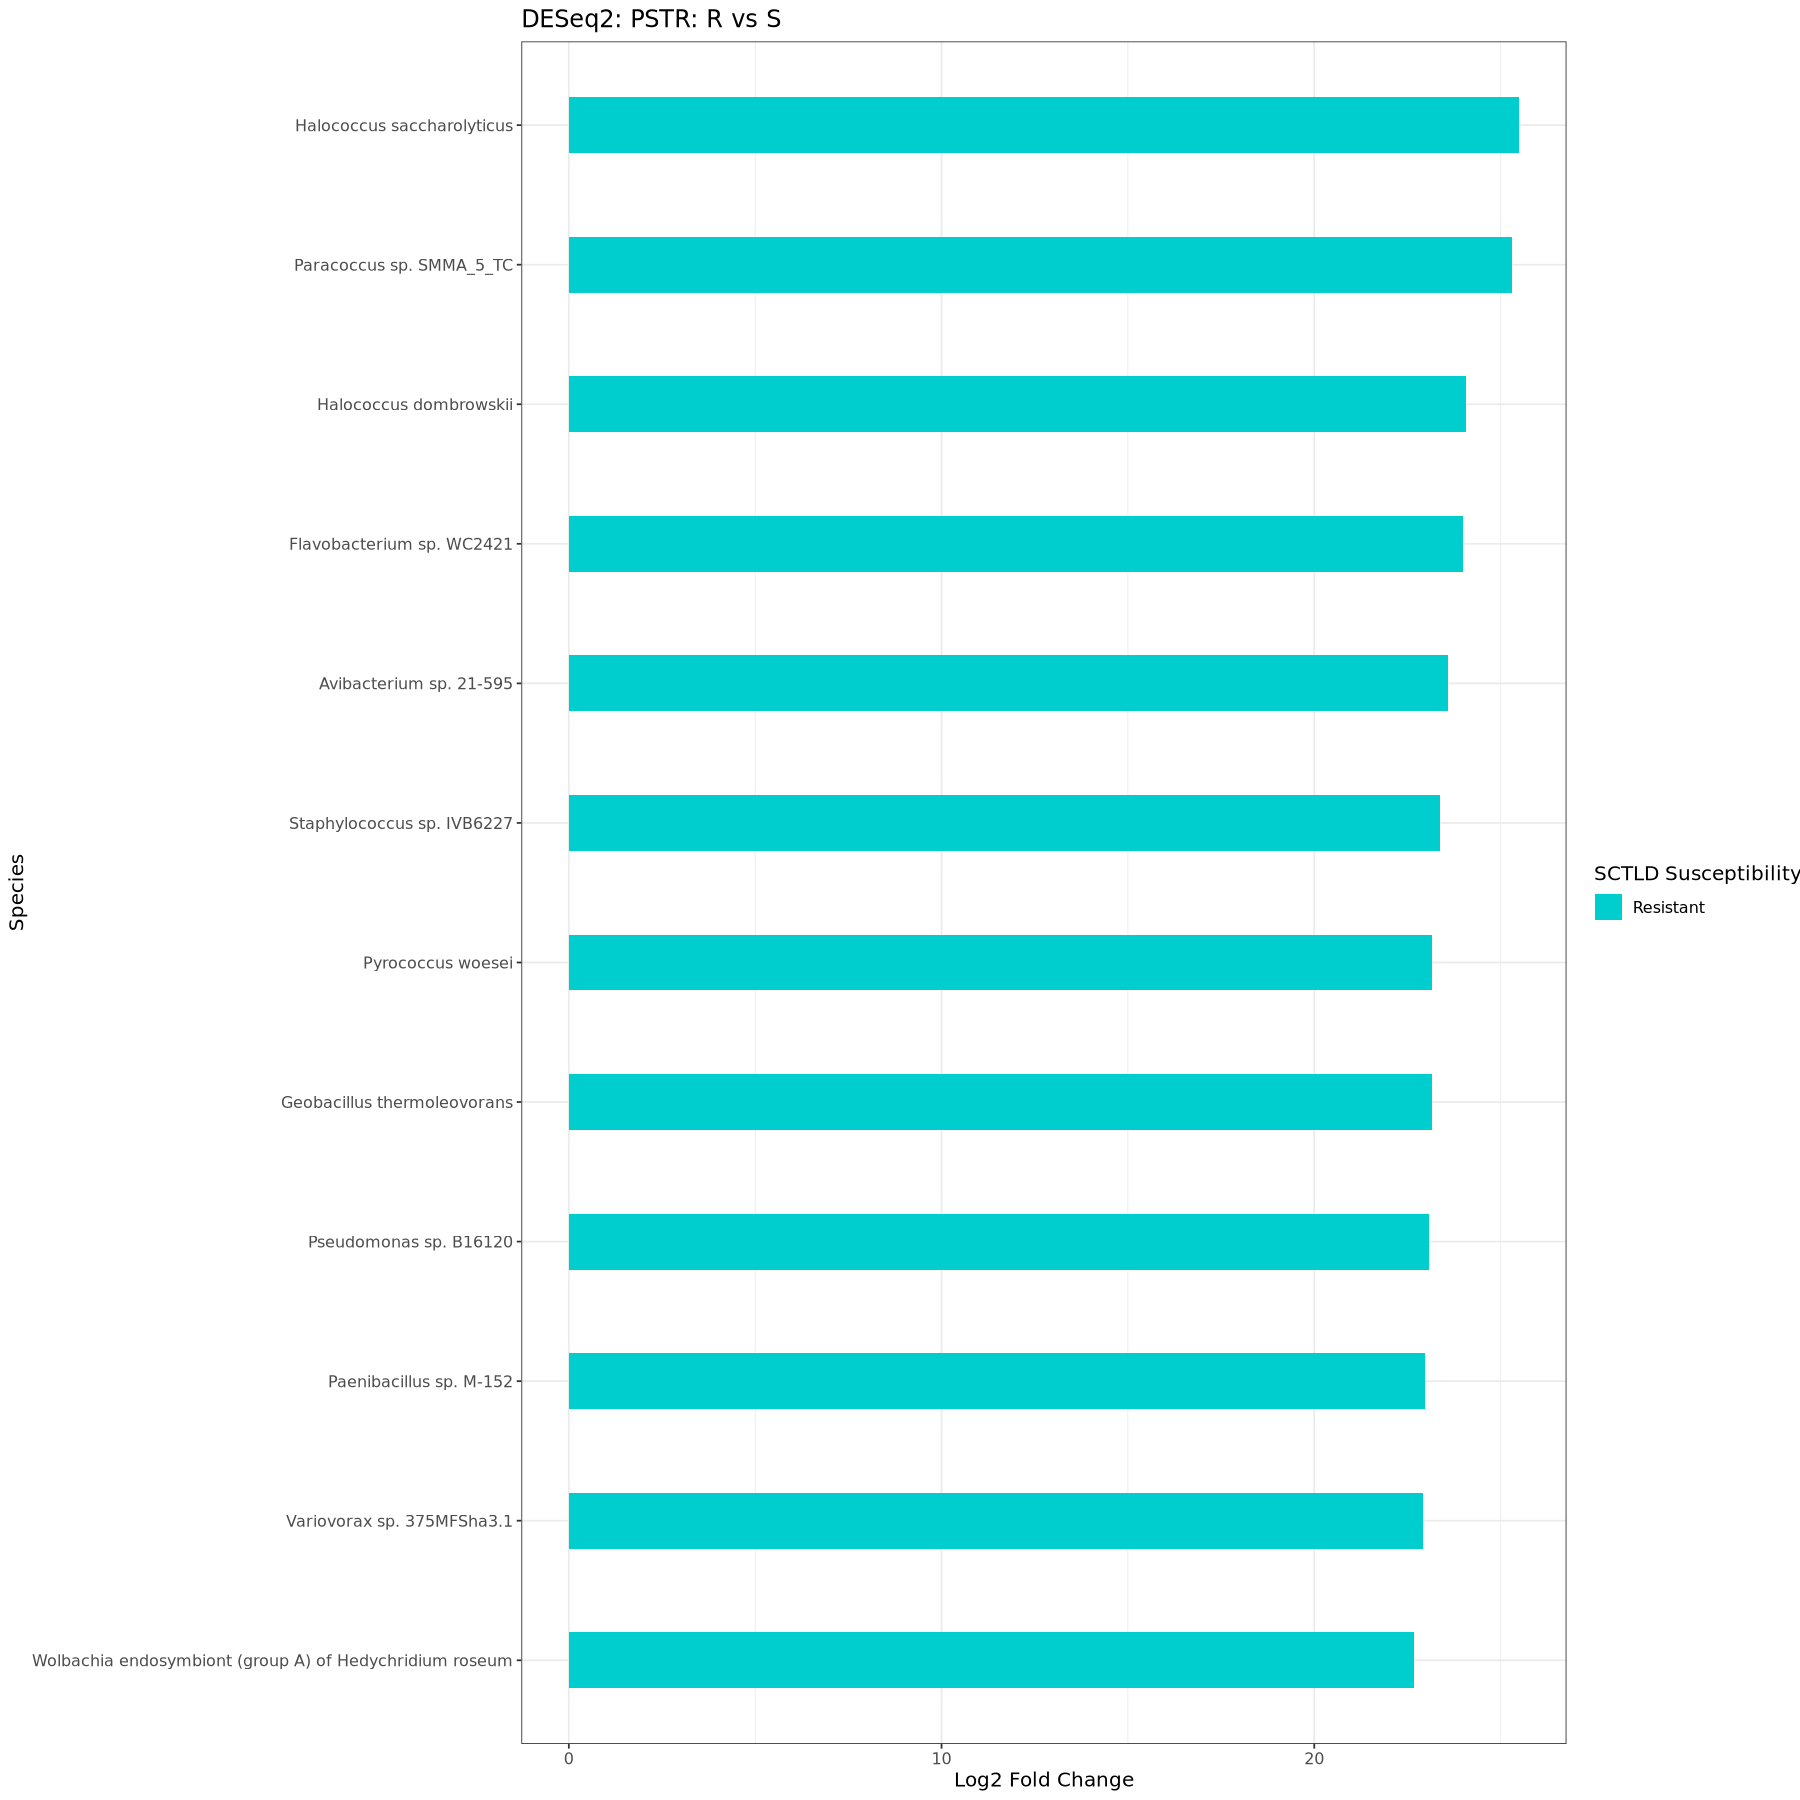

In [169]:
pstr_res<-view_ds_res(pstr_ds, "RS","Resistant","Susceptible")

# plot significantly different OTUs 
ggplot(pstr_res, aes(x = reorder(species,log2FoldChange), y = log2FoldChange, fill = RS)) +
    geom_bar(stat = "identity", width = 0.4) +
    coord_flip() + 
    scale_fill_manual(values= c("Resistant"="cyan3", "Susceptible"="coral3"))+
    theme_bw()+
    labs(x = "Species", y = "Log2 Fold Change", title = "DESeq2: PSTR: R vs S", fill = "SCTLD Susceptibility")+
    theme(text = element_text(size = 12)) 

In [ ]:
# do orbis 2022 healthy and diseased tissue r vs s??

In [ ]:
# do mmea healthy (sus) vs all other resis spp? 

### DESeq2 Disease vs Healthy

In [170]:
# all specie comparisons: healthy vs disease
dis_all_ds = phyloseq_to_deseq2(sctld_raw2, ~ Health_status)
dis_all_ds = DESeq(dis_all_ds, test="Wald", fitType="parametric")
res = results(dis_all_ds, cooksCutoff = FALSE, contrast=c("Health_status", "Healthy", "Diseased_Margin"))
alpha = 0.00001
sigtab_a = res[which(res$padj < alpha), ]
sigtab_mcav = cbind(as(sigtab_a, "data.frame"), as(tax_table(sctld_raw2)[rownames(sigtab_a), ], "matrix"))

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 7032 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



In [171]:
# sort by most significant 
sigtab_hs <- sigtab_mcav %>%
  arrange(padj)%>%
# add R vs S col
    mutate(HS = if_else(log2FoldChange<0, "Diseased_Margin","Healthy"))
head(sigtab_hs)
dim(sigtab_hs)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species,domain,kingdom,phylum,class,order,family,genus,HS
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
2829569,224.87940,-5.771270,0.4471849,-12.905780,4.175652e-38,4.635809e-34,Bacterioplanoides sp. SCSIO 12839,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Oceanospirillales,Oceanospirillaceae,Bacterioplanoides,Diseased_Margin
2321133,196.98409,-3.167334,0.2495240,-12.693506,6.424461e-37,3.566218e-33,Halarcobacter sp.,Bacteria,Pseudomonadati,Campylobacterota,Epsilonproteobacteria,Campylobacterales,Arcobacteraceae,Halarcobacter,Diseased_Margin
3242158,17.51565,23.566271,2.0509122,11.490629,1.470382e-30,5.441392e-27,Cupriavidus sp. a3,Bacteria,Pseudomonadati,Pseudomonadota,Betaproteobacteria,Burkholderiales,Burkholderiaceae,Cupriavidus,Healthy
2903816,13.64440,22.865439,2.2962954,9.957534,2.337904e-23,6.488852e-20,Streptomyces sp. NBC_01296,Bacteria,Bacillati,Actinomycetota,Actinomycetes,Kitasatosporales,Streptomycetaceae,Streptomyces,Healthy
1531429,18.51538,23.798414,2.4754833,9.613643,7.002632e-22,1.554864e-18,Berryella intestinalis,Bacteria,Bacillati,Actinomycetota,Coriobacteriia,Eggerthellales,Eggerthellaceae,Berryella,Healthy
3021011,449.77200,-6.530114,0.6842929,-9.542864,1.389414e-21,2.570880e-18,Vibrio sp. SCSIO 43137,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio,Diseased_Margin


[1] 46 15

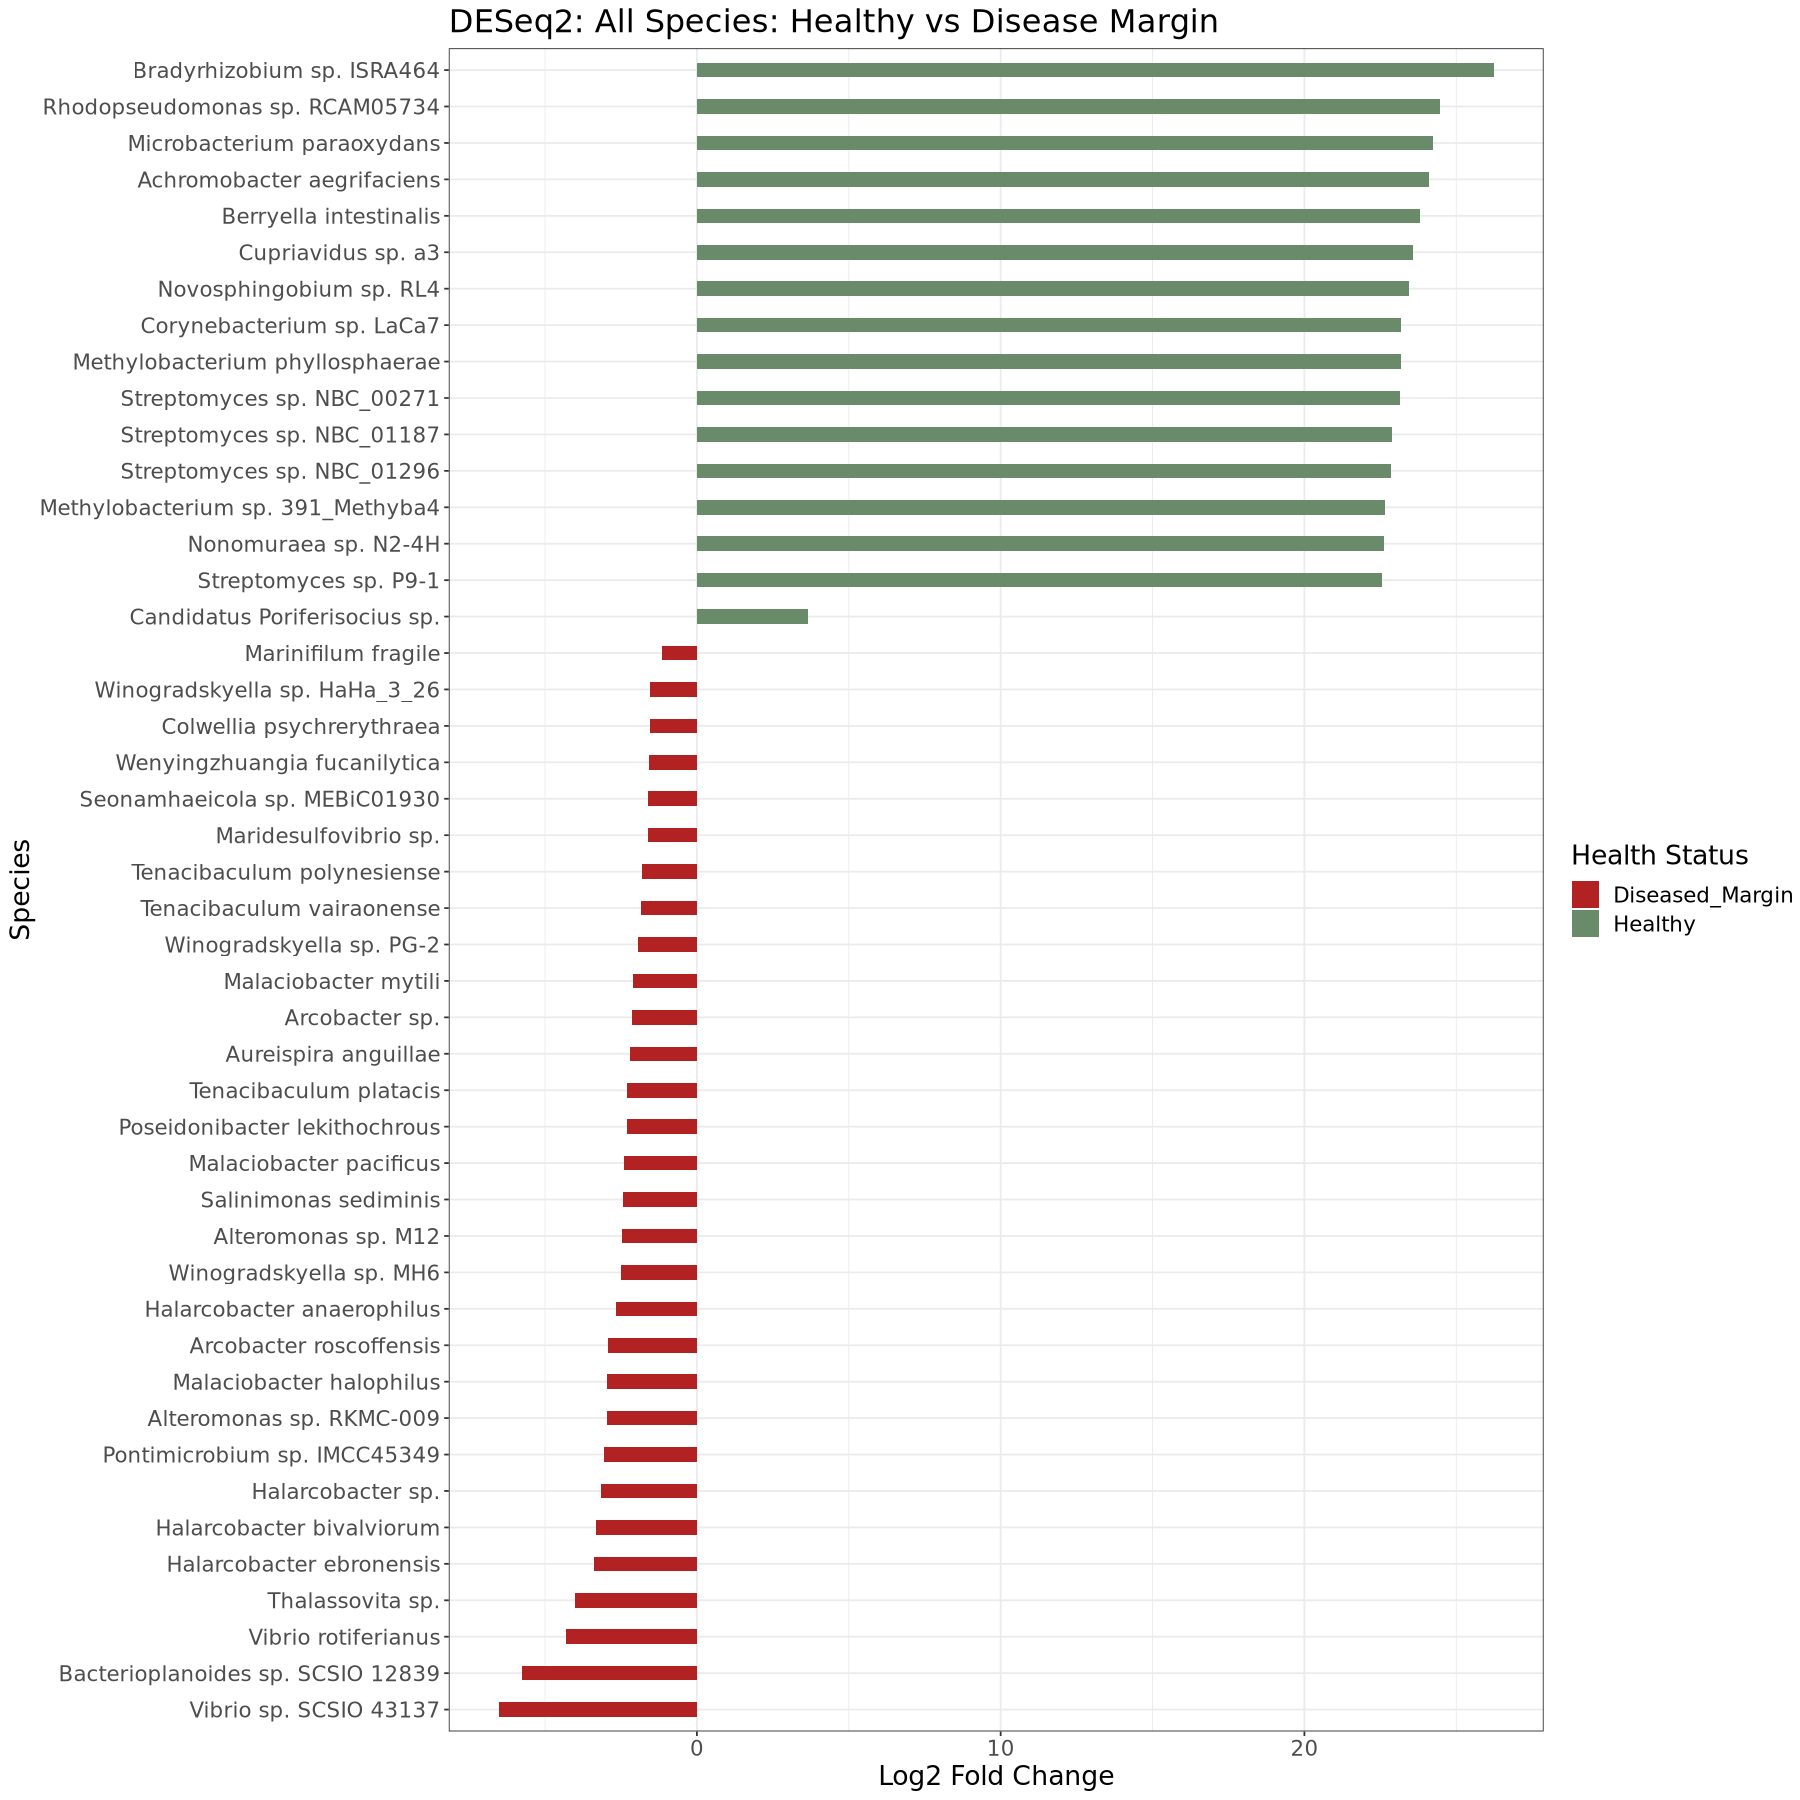

In [172]:
# plot significantly different OTUs
ggplot(sigtab_hs, aes(x = reorder(species,log2FoldChange), y = log2FoldChange, fill = HS)) +
    geom_bar(stat = "identity", width = 0.4) +
    coord_flip() + 
    scale_fill_manual(values= c("Healthy"="darkseagreen4", "Diseased_Margin"="firebrick"))+
    theme_bw()+
    labs(x = "Species", y = "Log2 Fold Change", title = "DESeq2: All Species: Healthy vs Disease Margin", fill = "Health Status")+
    theme(text = element_text(size = 16)) 

In [173]:
# disease margin vs disease tissue
dm_dt_ds<-run_deseq(phylo_obj = sctld_raw2, comparison = "Health_status", contrast1 = "Diseased_Tissue",contrast2 = "Diseased_Margin")

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 7032 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



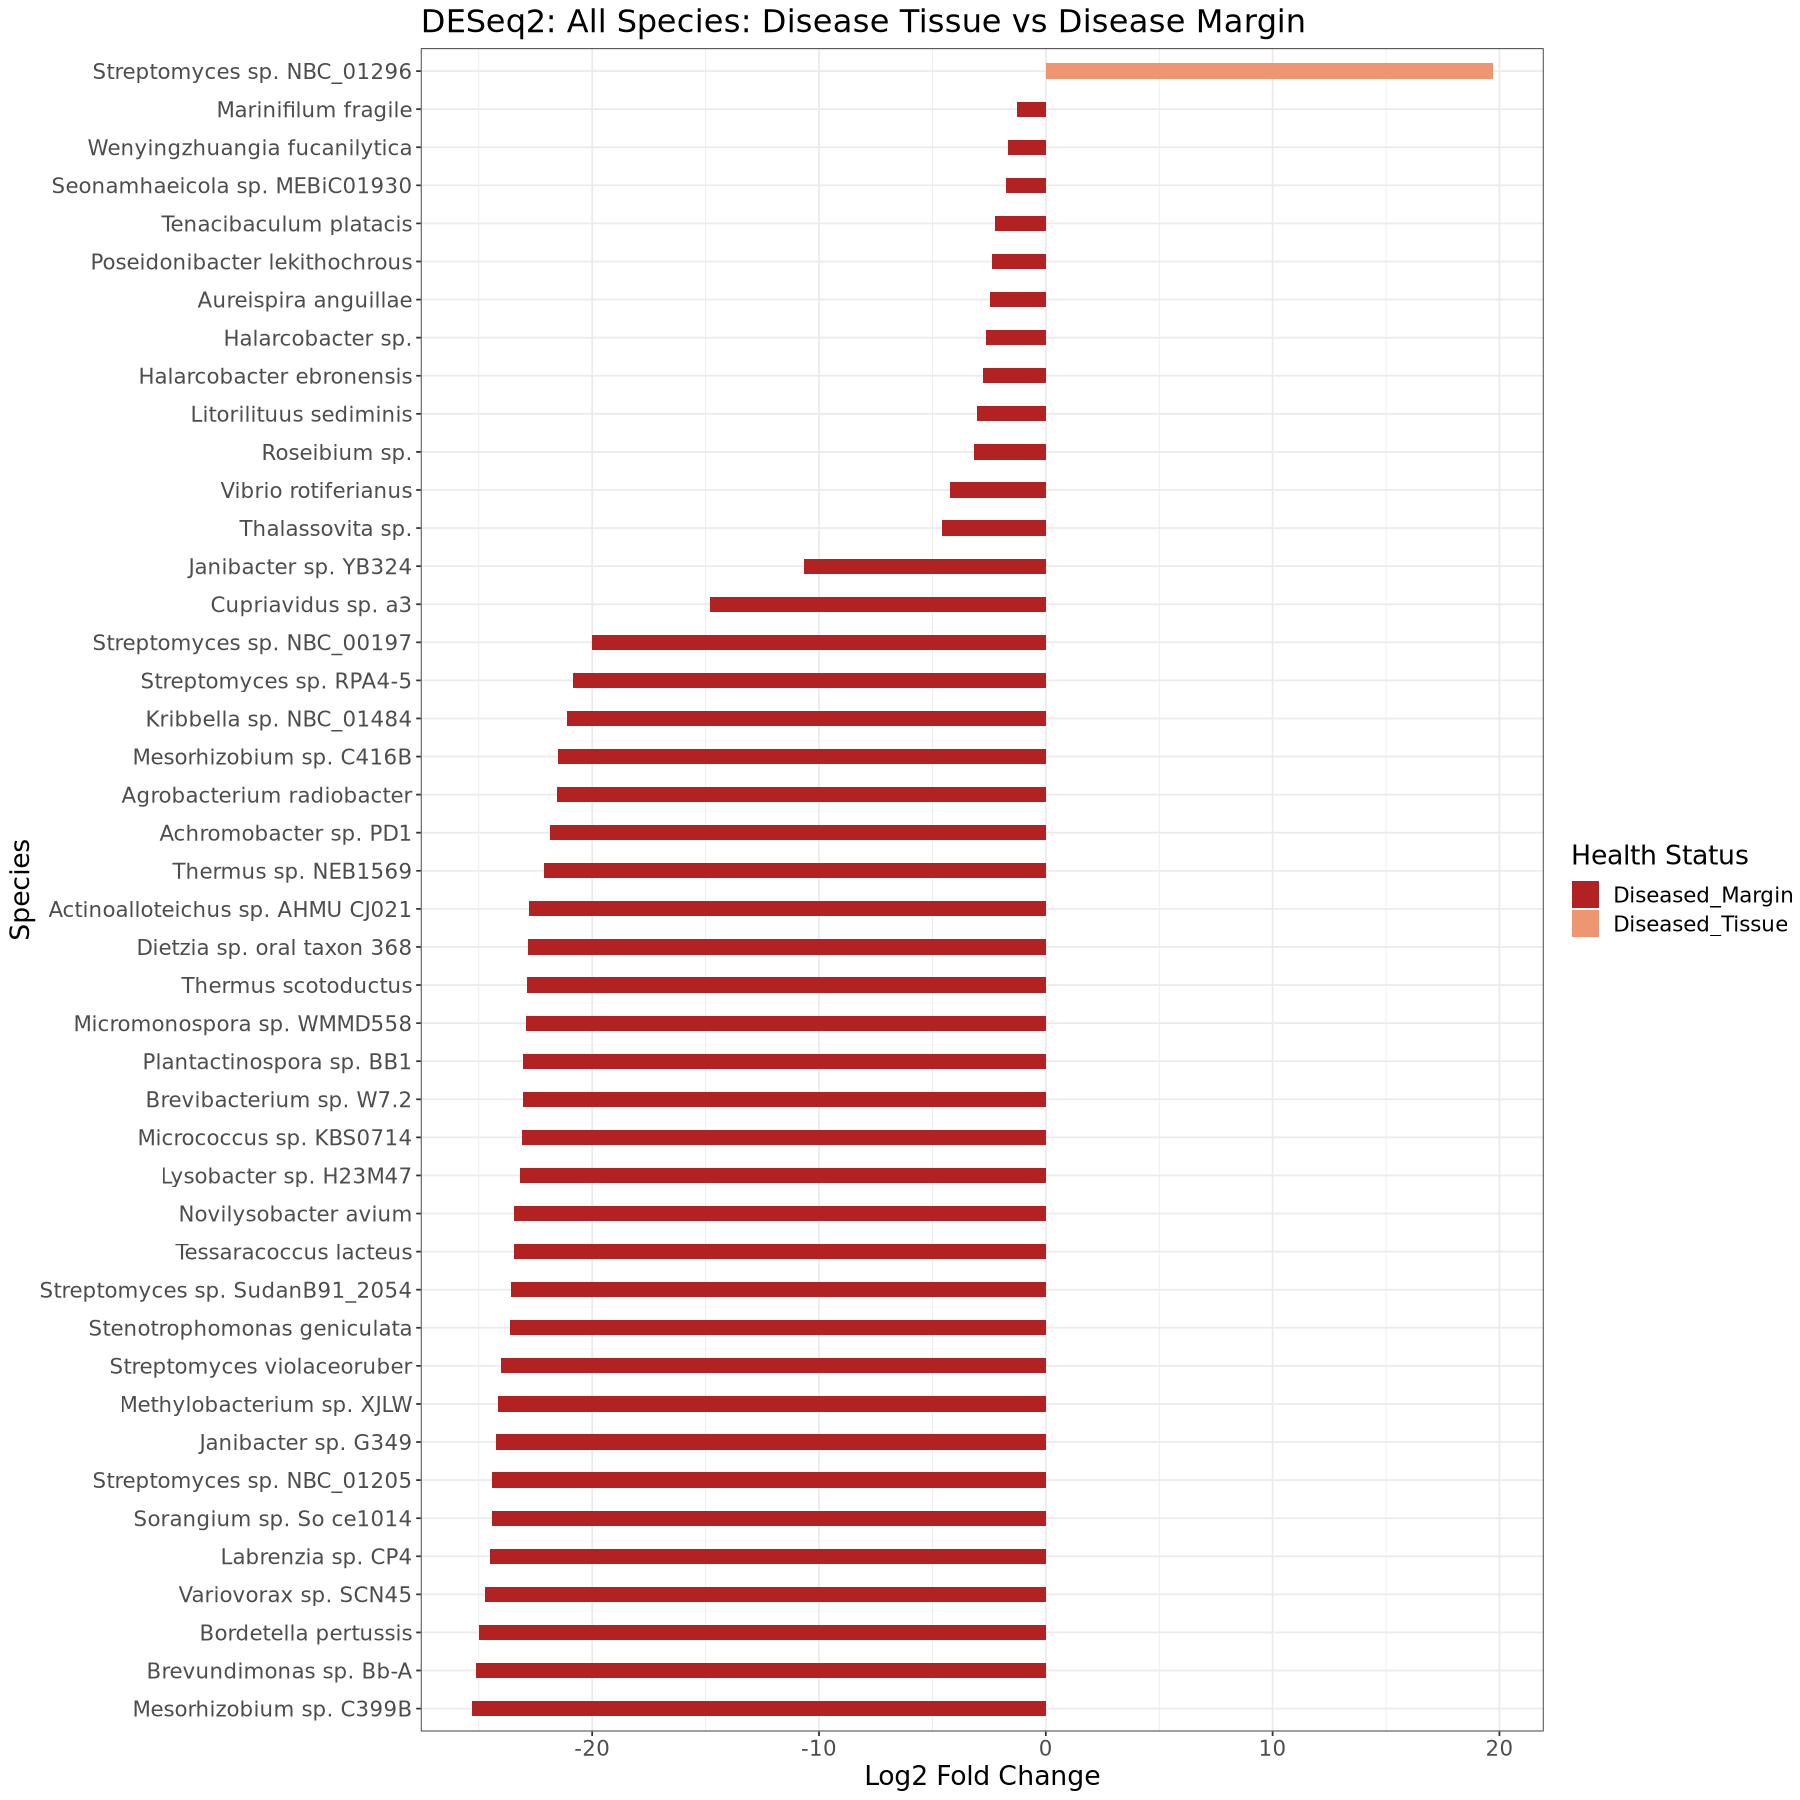

In [174]:
dm_dt_res<-view_ds_res(dm_dt_ds, comparison = "Health_status", contrast1 = "Diseased_Tissue",contrast2 = "Diseased_Margin")

# plot significantly different OTUs
ggplot(dm_dt_res, aes(x = reorder(species,log2FoldChange), y = log2FoldChange, fill = Health_status)) +
    geom_bar(stat = "identity", width = 0.4) +
    coord_flip() + 
    scale_fill_manual(values= c("Diseased_Tissue"="lightsalmon2", "Diseased_Margin"="firebrick"))+
    theme_bw()+
    labs(x = "Species", y = "Log2 Fold Change", title = "DESeq2: All Species: Disease Tissue vs Disease Margin", fill = "Health Status")+
    theme(text = element_text(size = 16)) 

In [175]:
# search for disease margin sig diff taxa in all disease samples
# youre deffs supposed to use kraken uniq for this 

In [176]:
sctld_assoc_otus<-rownames(dm_dt_res)

In [177]:
# otu_table %>%
#     filter(rownames %in% sctld_assoc_otus)

In [178]:
sctld_assoc_taxa<-unique(dm_dt_res$species)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 7032 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



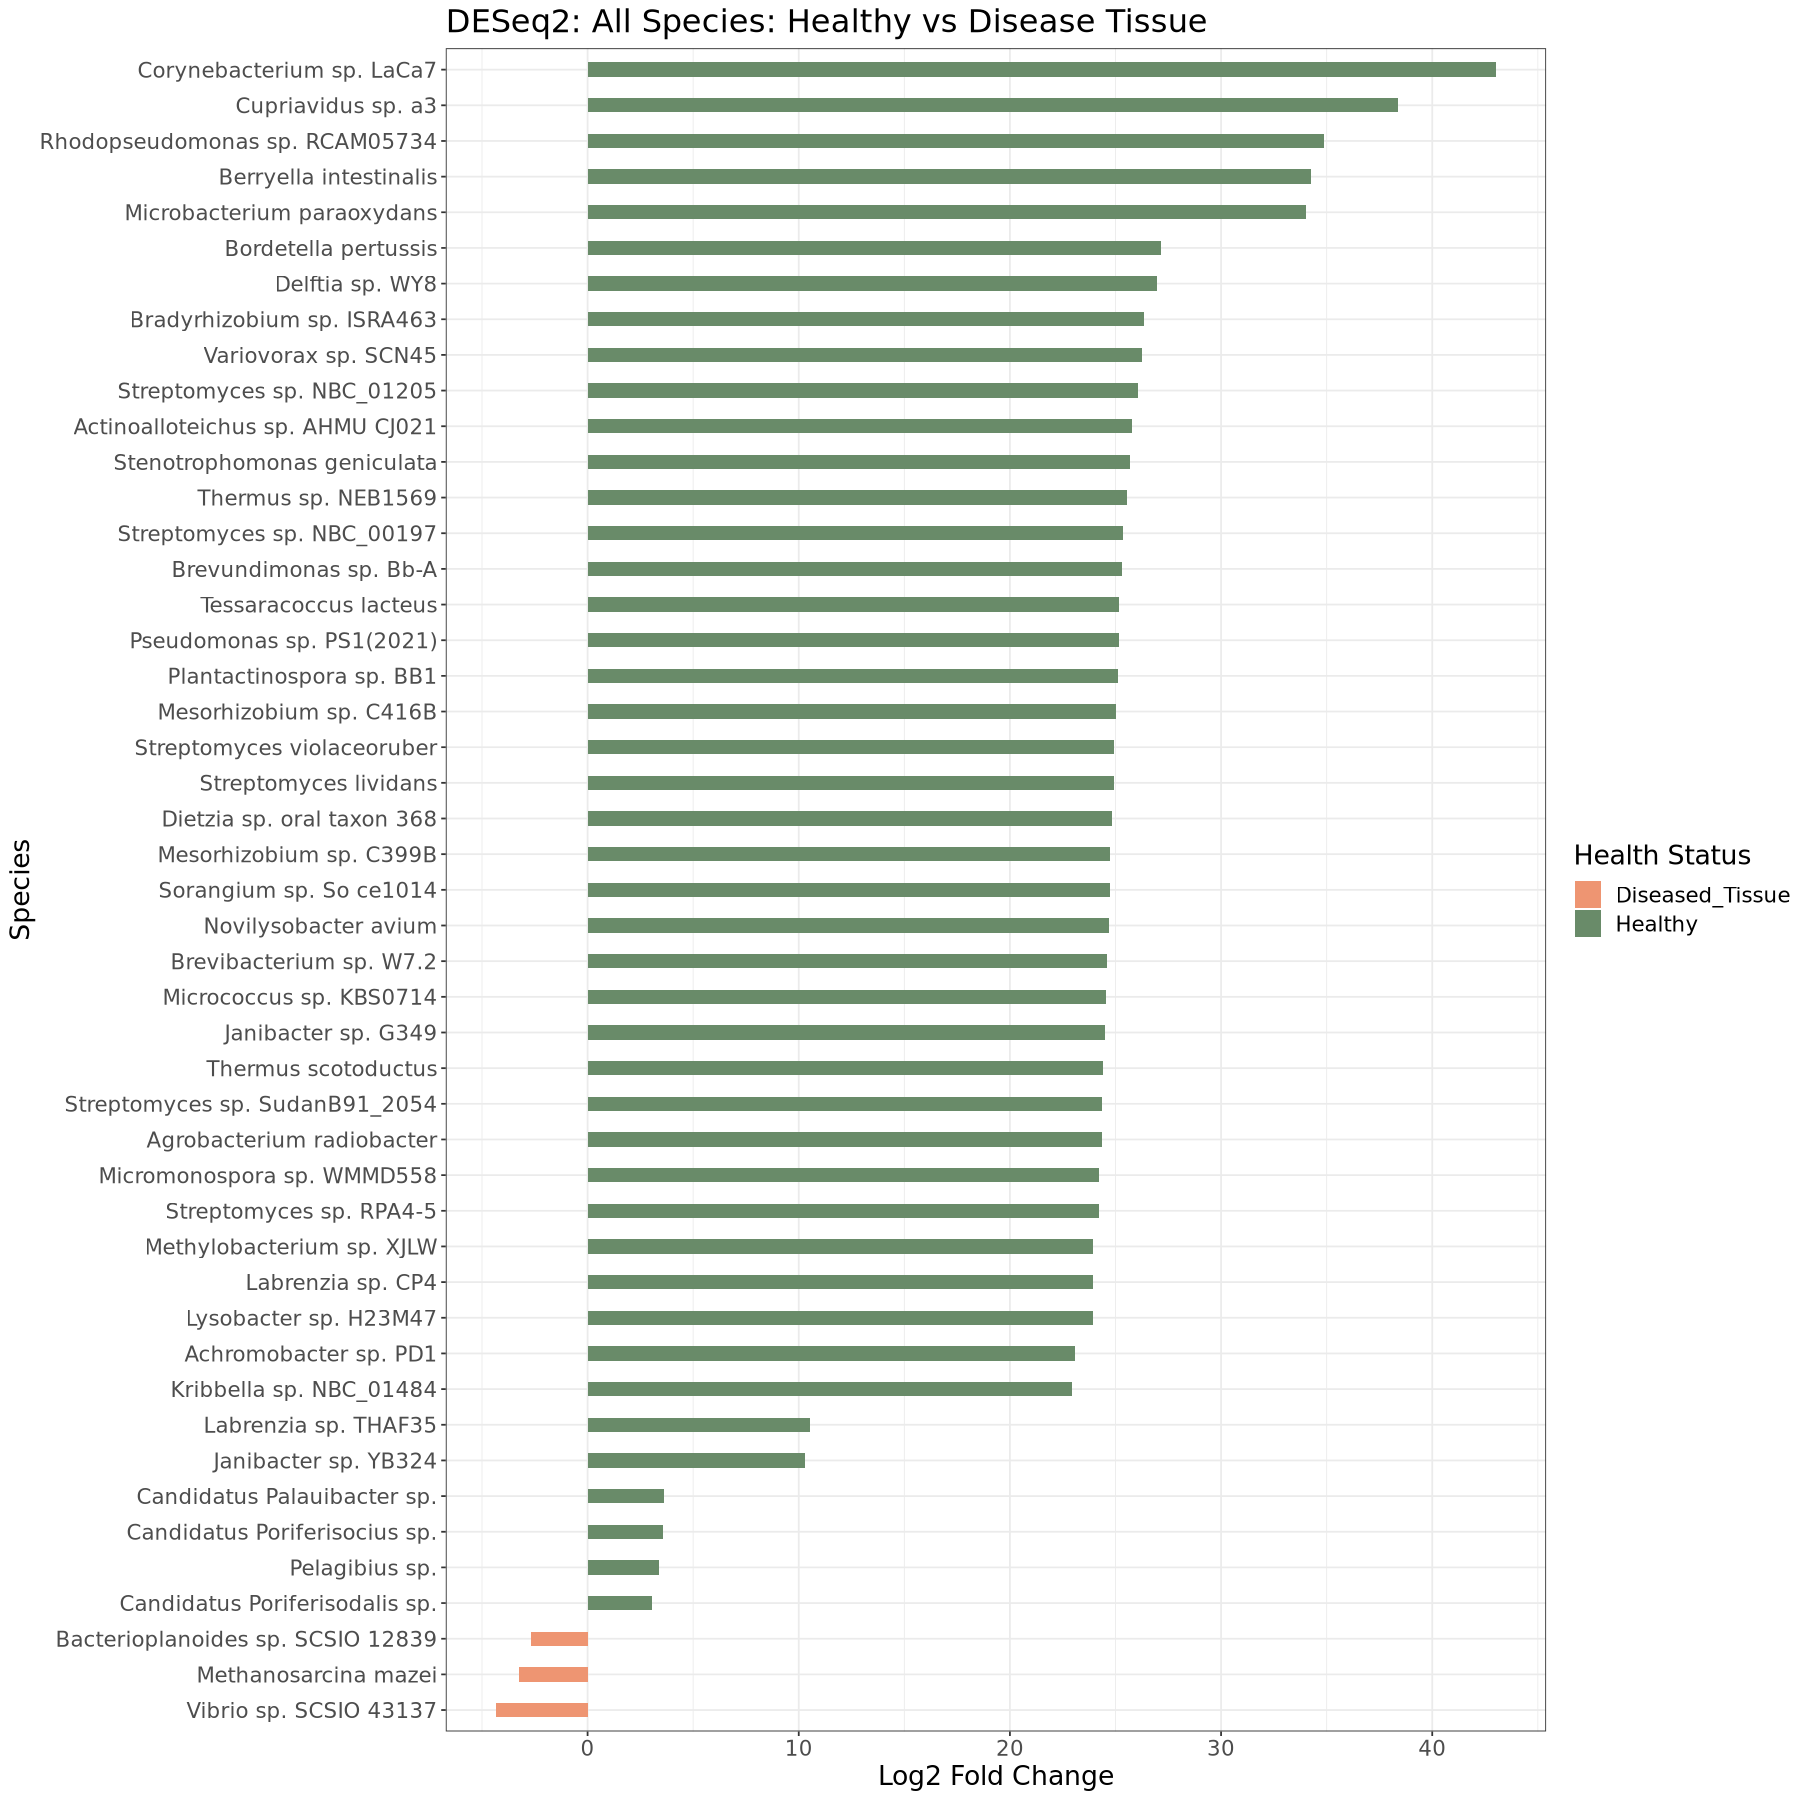

In [180]:
# disease tissue vs healthy
hdt_ds<-run_deseq(phylo_obj = sctld_raw2, comparison = "Health_status", contrast1 = "Healthy",contrast2 = "Diseased_Tissue")

hdt_res<-view_ds_res(hdt_ds, comparison = "Health_status", contrast1 = "Healthy",contrast2 = "Diseased_Tissue")

# plot significantly different OTUs
ggplot(hdt_res, aes(x = reorder(species,log2FoldChange), y = log2FoldChange, fill = Health_status)) +
    geom_bar(stat = "identity", width = 0.4) +
    coord_flip() + 
    scale_fill_manual(values= c("Healthy"="darkseagreen4", "Diseased_Tissue"="lightsalmon2"))+
    theme_bw()+
    labs(x = "Species", y = "Log2 Fold Change", title = "DESeq2: All Species: Healthy vs Disease Tissue", fill = "Health Status")+
    theme(text = element_text(size = 16)) 

In [ ]:
## try within species comparisons too 

### Taxa Bar Plots

In [487]:
# subset taxa and normalzie out of 100 
sctld_raw_10 = prune_taxa(names(sort(taxa_sums(sctld_raw),TRUE)[1:10]), sctld_raw)
sctld_raw_10_norm <- transform_sample_counts(sctld_raw_10, function(x) x / sum(x))
     
sctld_raw_30 = prune_taxa(names(sort(taxa_sums(sctld_raw),TRUE)[1:30]), sctld_raw)
sctld_raw_30_norm <- transform_sample_counts(sctld_raw_30, function(x) x / sum(x))

sctld_raw_100 = prune_taxa(names(sort(taxa_sums(sctld_raw),TRUE)[1:100]), sctld_raw)
sctld_raw_100_norm <- transform_sample_counts(sctld_raw_100, function(x) x / sum(x))

In [488]:
colnames(tax_table(sctld_raw))

[1] "domain"  "kingdom" "phylum"  "class"   "order"   "family"  "genus"  
[8] "species"

In [489]:
ps_genus<-tax_glom(sctld_raw, taxrank = "genus")
top30<-names(sort(taxa_sums(ps_genus), decreasing = TRUE))[1:30]
ps30_genus <-prune_taxa(top30, ps_genus)
ps30_genus_norm <- transform_sample_counts(ps30_genus, function(x) x / sum(x))

In [490]:
length(unique(tax_table(ps30_genus_norm)[,"genus"]))
length(unique(tax_table(ps30_genus_norm)[,"species"]))

[1] 30

[1] 1

In [491]:
# top 100 genera
top100<-names(sort(taxa_sums(ps_genus), decreasing = TRUE))[1:100]
ps100_genus <-prune_taxa(top100, ps_genus)
ps100_gnorm <- transform_sample_counts(ps100_genus, function(x) x / sum(x))

In [492]:
g_colors <- c( "#b73962", "#e994a6", "#be6b7c", "#944557", "#ea2c68", "#e65e74", "#b33841", "#dd3640", "#dd7267", "#de2b1c", "#a46452", "#c04926", "#9b4426", "#ec5825", "#e6a485", "#c2744d", "#e77d46", "#a3601b", "#845526", "#e28c23", "#d79651", "#a4844d", "#aa8523", "#d2b067", "#d3b135", "#726520", "#81871c", "#b4b75d", "#a5c030", "#829055", "#7a9a3c", "#566935", "#a7bc85", "#4e7023", "#64a422", "#89c45e", "#57ce3c", "#2f7f2d", "#3aa83a", "#5d9b58", "#7ec485", "#47cc7a", "#2c6f47", "#32a064", "#2f8970", "#53ae93", "#3fc9a6", "#64d3c2", "#41bbc8", "#3da5c4", "#4b8ebf", "#72b3e8", "#3270a7", "#2e5b88", "#4795e0", "#5790ed", "#2b6abe", "#2580fe", "#415691", "#6274b2", "#4b80ec", "#95a0e6", "#4362c2", "#7c89e9", "#5166ec", "#3c4dbb", "#5756a0", "#695dbf", "#8476c6", "#675cd3", "#4e45a3", "#4d4adc", "#8f76e8", "#72619d", "#9b87be", "#6b4fa0", "#7048b1", "#7532e8", "#b58aea", "#9655e8", "#cda8e4", "#7c608c", "#8a52ae", "#634872", "#bc6aea", "#b436e6", "#9235b6", "#7e4990", "#b175b9", "#9b43a1", "#dd7adc", "#e635ea", "#d043cc", "#915882", "#d78bbb", "#ba3291", "#ea3db5", "#a24680", "#e670af", "#e3418b" )
colors <- c( "#b73962", "#e994a6", "#be6b7c", "#944557", "#ea2c68", "#e65e74", "#b33841", "#dd3640", "#dd7267", "#de2b1c", "#a46452", "#c04926", "#9b4426", "#ec5825", "#e6a485", "#c2744d", "#e77d46", "#a3601b", "#845526", "#e28c23", "#d79651", "#a4844d", "#aa8523", "#d2b067", "#d3b135", "#726520", "#81871c", "#b4b75d", "#a5c030", "#829055", "#7a9a3c", "#566935", "#a7bc85", "#4e7023", "#64a422", "#89c45e", "#57ce3c", "#2f7f2d", "#3aa83a", "#5d9b58", "#7ec485", "#47cc7a", "#2c6f47", "#32a064", "#2f8970", "#53ae93", "#3fc9a6", "#64d3c2", "#41bbc8", "#3da5c4", "#4b8ebf", "#72b3e8", "#3270a7", "#2e5b88", "#4795e0", "#5790ed", "#2b6abe", "#2580fe", "#415691", "#6274b2", "#4b80ec", "#95a0e6", "#4362c2", "#7c89e9", "#5166ec", "#3c4dbb", "#5756a0", "#695dbf", "#8476c6", "#675cd3", "#4e45a3", "#4d4adc", "#8f76e8", "#72619d", "#9b87be", "#6b4fa0", "#7048b1", "#7532e8", "#b58aea", "#9655e8", "#cda8e4", "#7c608c", "#8a52ae", "#634872", "#bc6aea", "#b436e6", "#9235b6", "#7e4990", "#b175b9", "#9b43a1", "#dd7adc", "#e635ea", "#d043cc", "#915882", "#d78bbb", "#ba3291", "#ea3db5", "#a24680", "#e670af", "#e3418b" )
colors_30 <- c( "#e28d99", "#ee7473", "#f2703f", "#dc966f", "#de9435", "#d6b36e", "#dbbf37", "#abb160", "#bdd630", "#bade6b", "#7ead3b", "#bcdc9c", "#66d34d", "#65d77c", "#66af7a", "#5ae5ac", "#77e3c6", "#47b1a5", "#5ae4e5", "#41aec3", "#5eceed", "#3ba1d2", "#78b0e7", "#7796ed", "#b5a5dd", "#aa7df5", "#c891e3", "#e66dd5", "#de95c9", "#f2699f" )

In [493]:
# map list of 100 genera to same color
top100_names <- as.character(tax_table(ps100_genus)[, "genus"])
names(g_colors) <- top100_names
head(g_colors)

Bradyrhizobium                 Reyranella 
                 "#b73962"                  "#e994a6" 
   Candidatus_Palauibacter Candidatus_Poriferisodalis 
                 "#be6b7c"                  "#944557" 
 Candidatus_Poriferisocius        Lactiplantibacillus 
                 "#ea2c68"                  "#e65e74"

In [494]:
options(repr.plot.height = 15, repr.plot.width = 30)

In [495]:
# plot_bar(ps30_genus_norm,x = "Sample",fill='genus')+
#     facet_grid(~ Species + RS, scales = "free_x") +
#     geom_bar(aes(fill=genus), stat="identity",position="stack")+
#     scale_fill_manual(values = g_colors) +
#     theme_bw()+
#     theme(legend.position="bottom", panel.border = element_blank(), 
#               panel.grid.major.x = element_blank(), 
#               panel.grid.minor.x = element_blank(),
#               axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
#               text = element_text(size=15))
# found the PSTR outlier 

In [496]:
# try just each spp R vs S in 2019

sctld_100_2019<- subset_samples(sctld_raw, year == "2019")
sctld_100_2019 = prune_taxa(names(sort(taxa_sums(sctld_100_2019),TRUE)[1:100]), sctld_100_2019)
sctld_100_2019_norm <- transform_sample_counts(sctld_100_2019, function(x) x / sum(x))

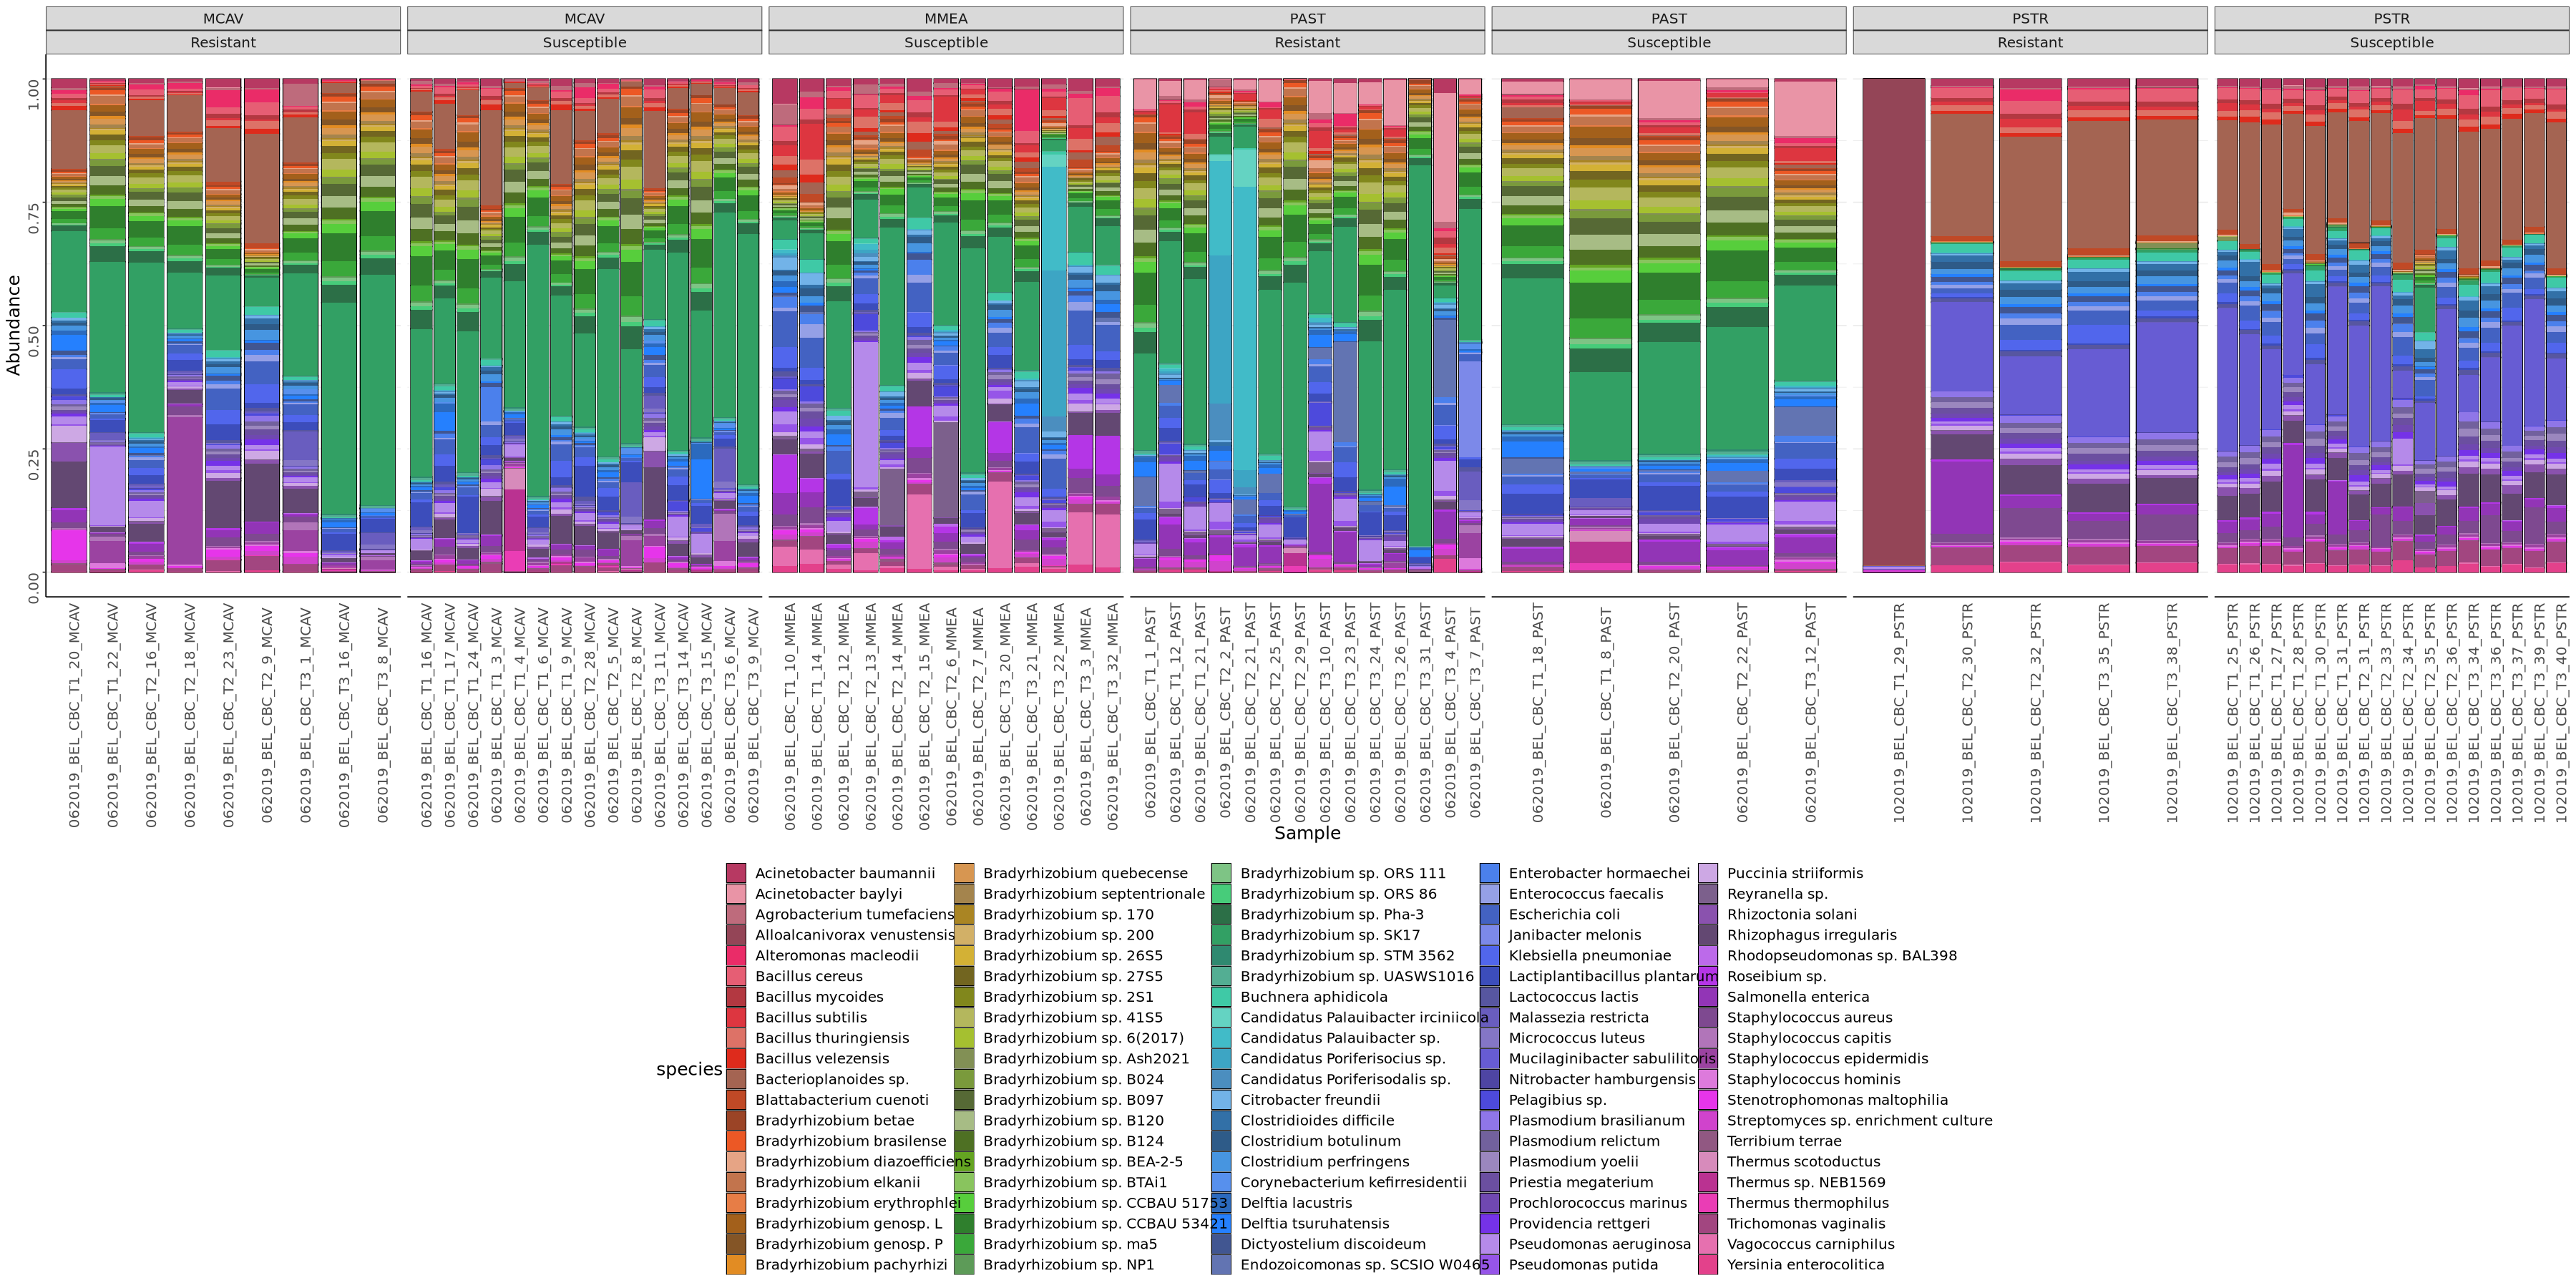

In [497]:
plot_bar(sctld_100_2019_norm,x = "Sample",fill='species')+
    facet_grid(~ Species + RS, scales = "free_x") +
    geom_bar(aes(fill=species), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# found the PSTR outlier 

# 2019: Top 100 OTUs

In [498]:
# and at genus level
ps_genus2019<-tax_glom(sctld_100_2019, taxrank = "genus")
top30<-names(sort(taxa_sums(ps_genus2019), decreasing = TRUE))[1:30]
ps30_g2019 <-prune_taxa(top30, ps_genus2019)
ps30_g2019_norm <- transform_sample_counts(ps30_g2019, function(x) x / sum(x))

In [499]:
# add new taxa to colors list (to keep the rest consistent)
# names of these top 30 genus
genera_2019 <- as.character(tax_table(ps30_g2019)[, "genus"])
missing_genera <- setdiff(genera_2019, names(g_colors))

# add new colors
new_colors <- colorRampPalette(brewer.pal(8, "Dark2"))(length(missing_genera))
names(new_colors) <- missing_genera
  
# append to colors vector
g_colors <- c(g_colors, new_colors)
missing_genera

[1] "Malassezia"      "Micrococcus"     "Terribium"       "Trichomonas"    
[5] "Buchnera"        "Janibacter"      "Alloalcanivorax"

In [500]:
# view colors
# barplot(rep(1, length(new_colors)), 
#         col = new_colors, 
#         names.arg = names(new_colors), 
#         las = 2, 
#         border = NA,
#         main = "Genus Color Map")

In [501]:
length(g_colors)

[1] 107

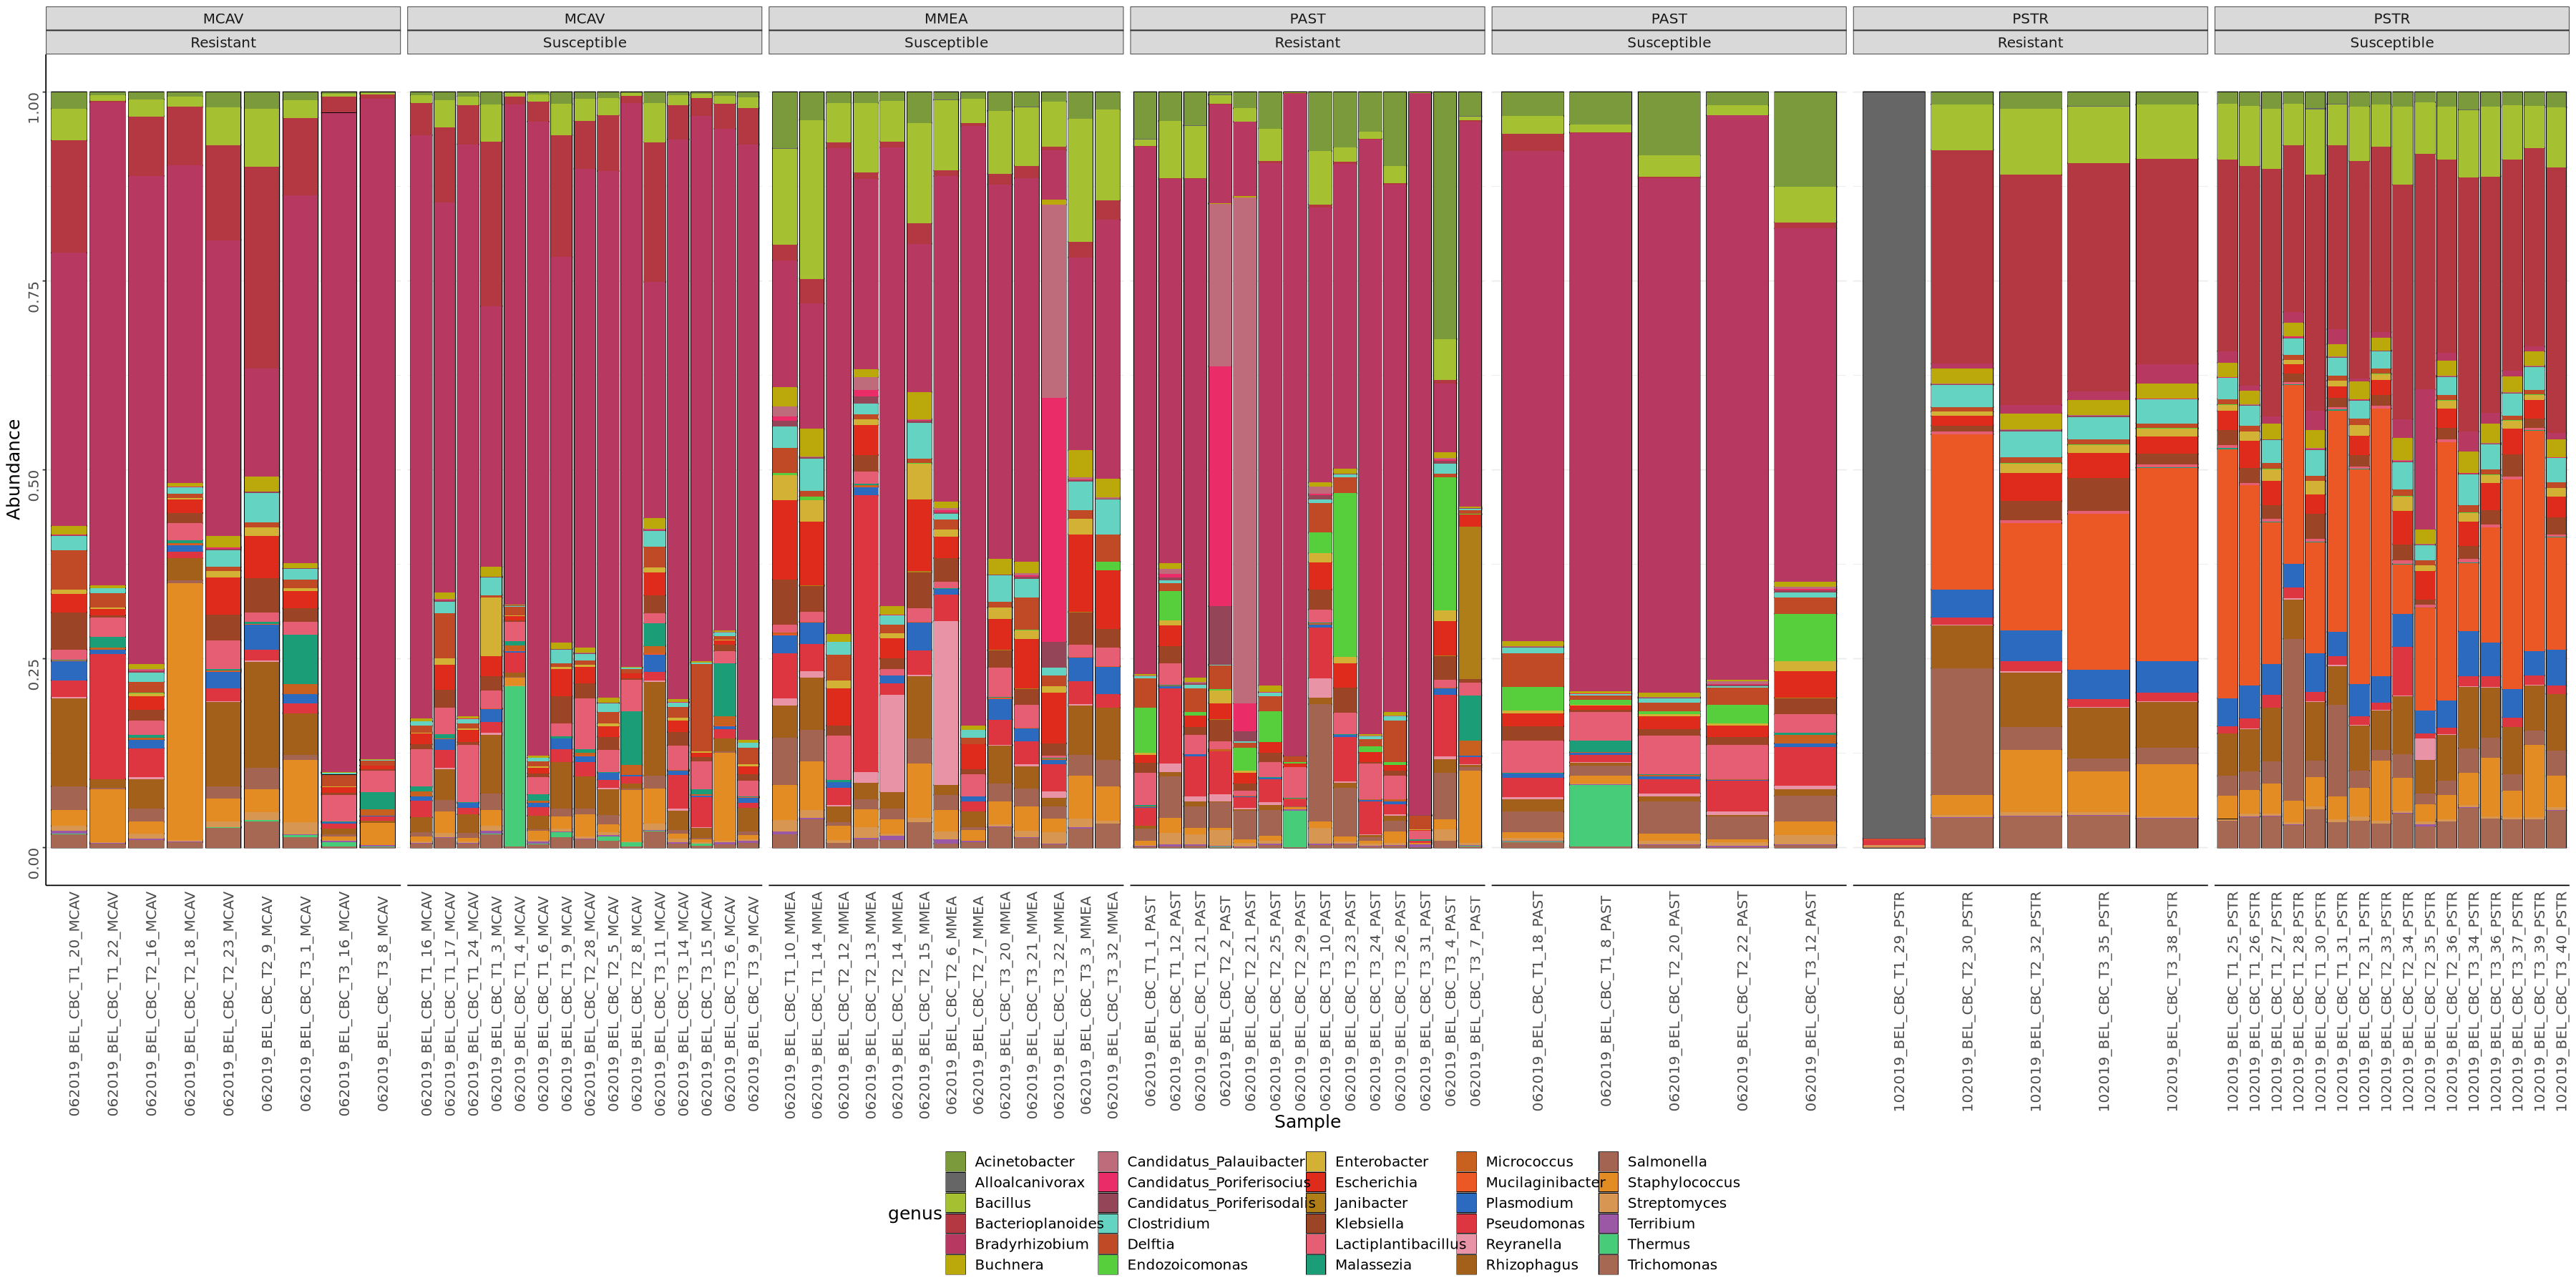

In [502]:
plot_bar(ps30_g2019_norm,x = "Sample",fill='genus')+
    facet_grid(~ Species + RS, scales = "free_x") +
    geom_bar(aes(x = fct_reorder(Sample, Month_year), fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# found the PSTR outlier 

In [503]:
# plot each spp individually...
    # guess i will try all RS

In [504]:
# looking just at mcav, remove disease margin

subset_mcav<- subset_samples(sctld_raw, (Species == "MCAV" & Health_status != "Diseased_Margin"))

mcav_100 = prune_taxa(names(sort(taxa_sums(subset_mcav),TRUE)[1:100]), subset_mcav)
mcav_100_norm <- transform_sample_counts(mcav_100, function(x) x / sum(x))

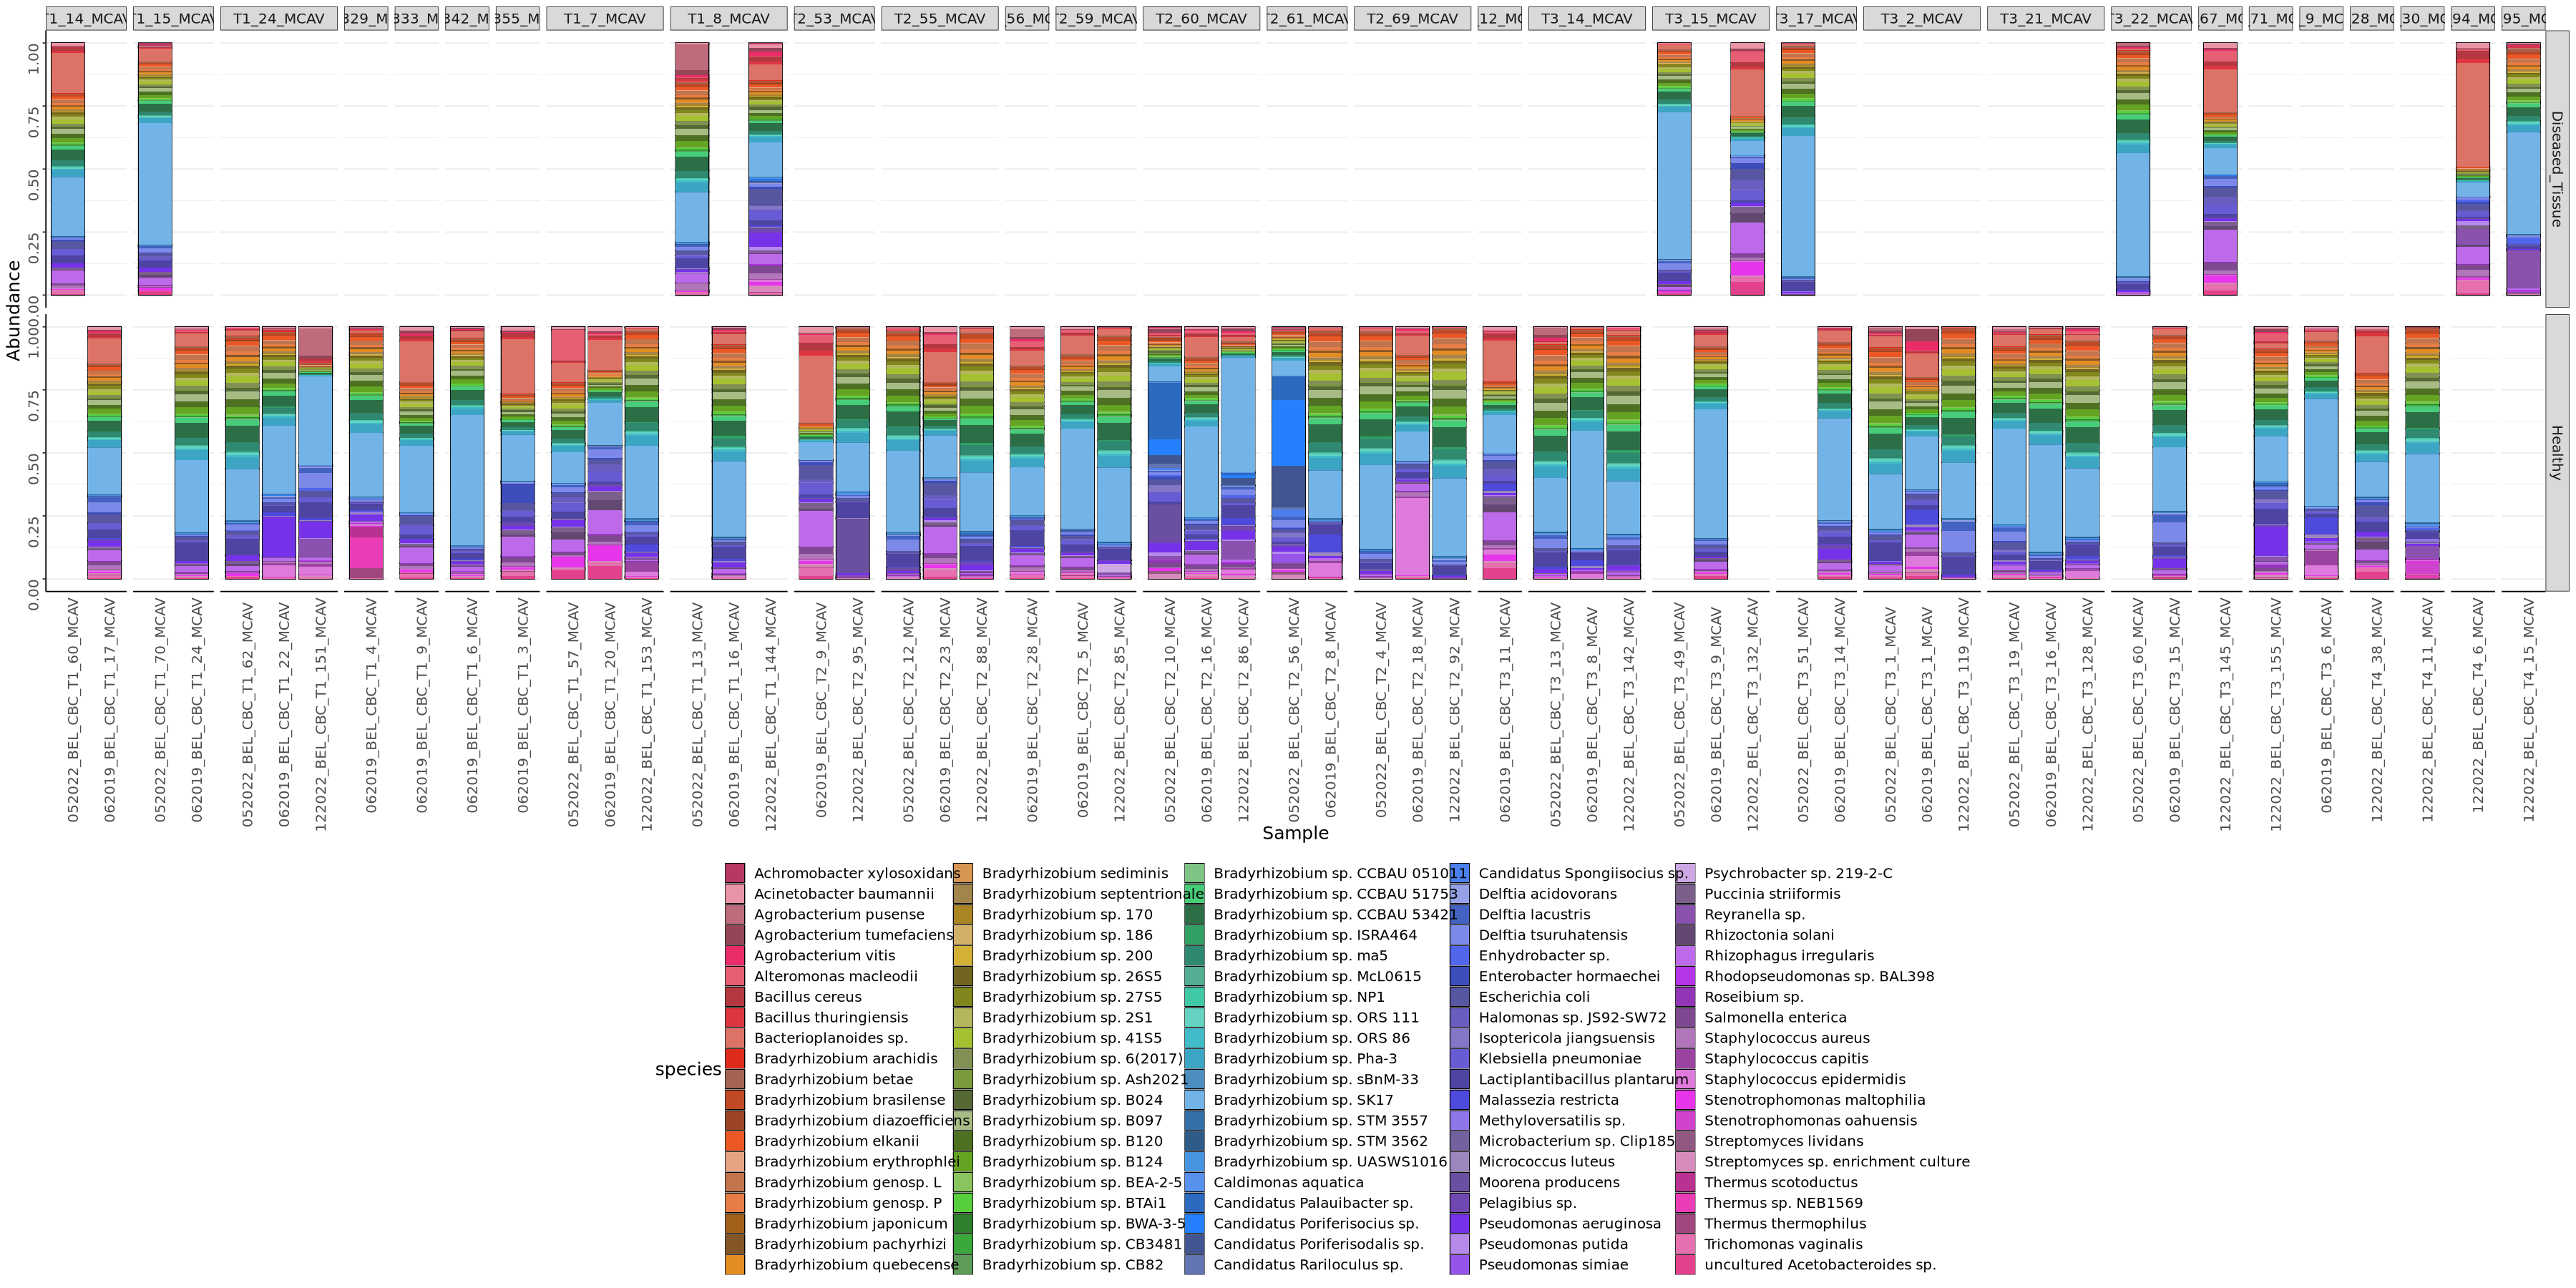

In [505]:
plot_bar(mcav_100_norm,x = "Sample",fill='species')+
    facet_grid(Health_status ~colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = fct_reorder(Sample, Month_year),fill=species), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# cannot figure out how to put in order of date...

In [534]:
# repeat top genera
subset_mcav<- subset_samples(ps30_genus_norm, (Species == "MCAV" & Health_status != "Diseased_Margin"))
# and remove newly tagged colonies in 2022 
dec_tags<-c('12/03/22','12/05/22')
subset_mcav<- subset_samples(subset_mcav, (!(Date_InitialTag %in% dec_tags)))

In [535]:
df_meta <- data.frame(sample_data(subset_mcav))

# 2. Re-level Sample IDs based on month_year order
df_meta <- df_meta %>% 
  arrange(colony_id,month_year) %>% 
  mutate(sampleid = factor(sampleid, levels = unique(sampleid)))

In [536]:
# 3. Update sample_data in your phyloseq object
sample_data(subset_mcav) <- sample_data(df_meta)

In [541]:
options(repr.plot.height = 13, repr.plot.width = 18)

In [538]:
library(ggh4x)

In [539]:
sample_colony %>%
    filter(colony_id == "T1_24_MCAV")

,colony_id,sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,⋯,Date_DocumentedDisease,Date_DocumentedMortality,X062019_Condition,X102019_Condition,X052022_Condition,X122022_Condition,X092023_Condition,RS,year,month_year
,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>
052022_BEL_CBC_T1_62_MCAV,T1_24_MCAV,052022_T1_62_MCAV,52022,5/25/22,CBC30N,1,24,MCAV,62,Healthy,⋯,Healthy,Healthy,Healthy,,Healthy,Healthy,CLP,Resistant,2022,May 2022
052022_BEL_CBC_T1_54_MCAV,T1_24_MCAV,052022_T1_54_MCAV,52022,5/21/22,CBC30N,1,24,MCAV,54,Healthy,⋯,Healthy,Healthy,Healthy,,Healthy,Healthy,CLP,Resistant,2022,May 2022
122022_BEL_CBC_T1_151_MCAV,T1_24_MCAV,122022_T1_151_MCAV,122022,12/2/22,CBC30N,1,24,MCAV,151,Healthy,⋯,Healthy,Healthy,Healthy,,Healthy,Healthy,CLP,Resistant,2022,Dec 2022
062019_BEL_CBC_T1_22_MCAV,T1_24_MCAV,062019_T1_22_MCAV,62019,6/24/19,CBC30N,1,24,MCAV,22,Healthy,⋯,Healthy,Healthy,Healthy,,Healthy,Healthy,CLP,Resistant,2019,Jun 2019


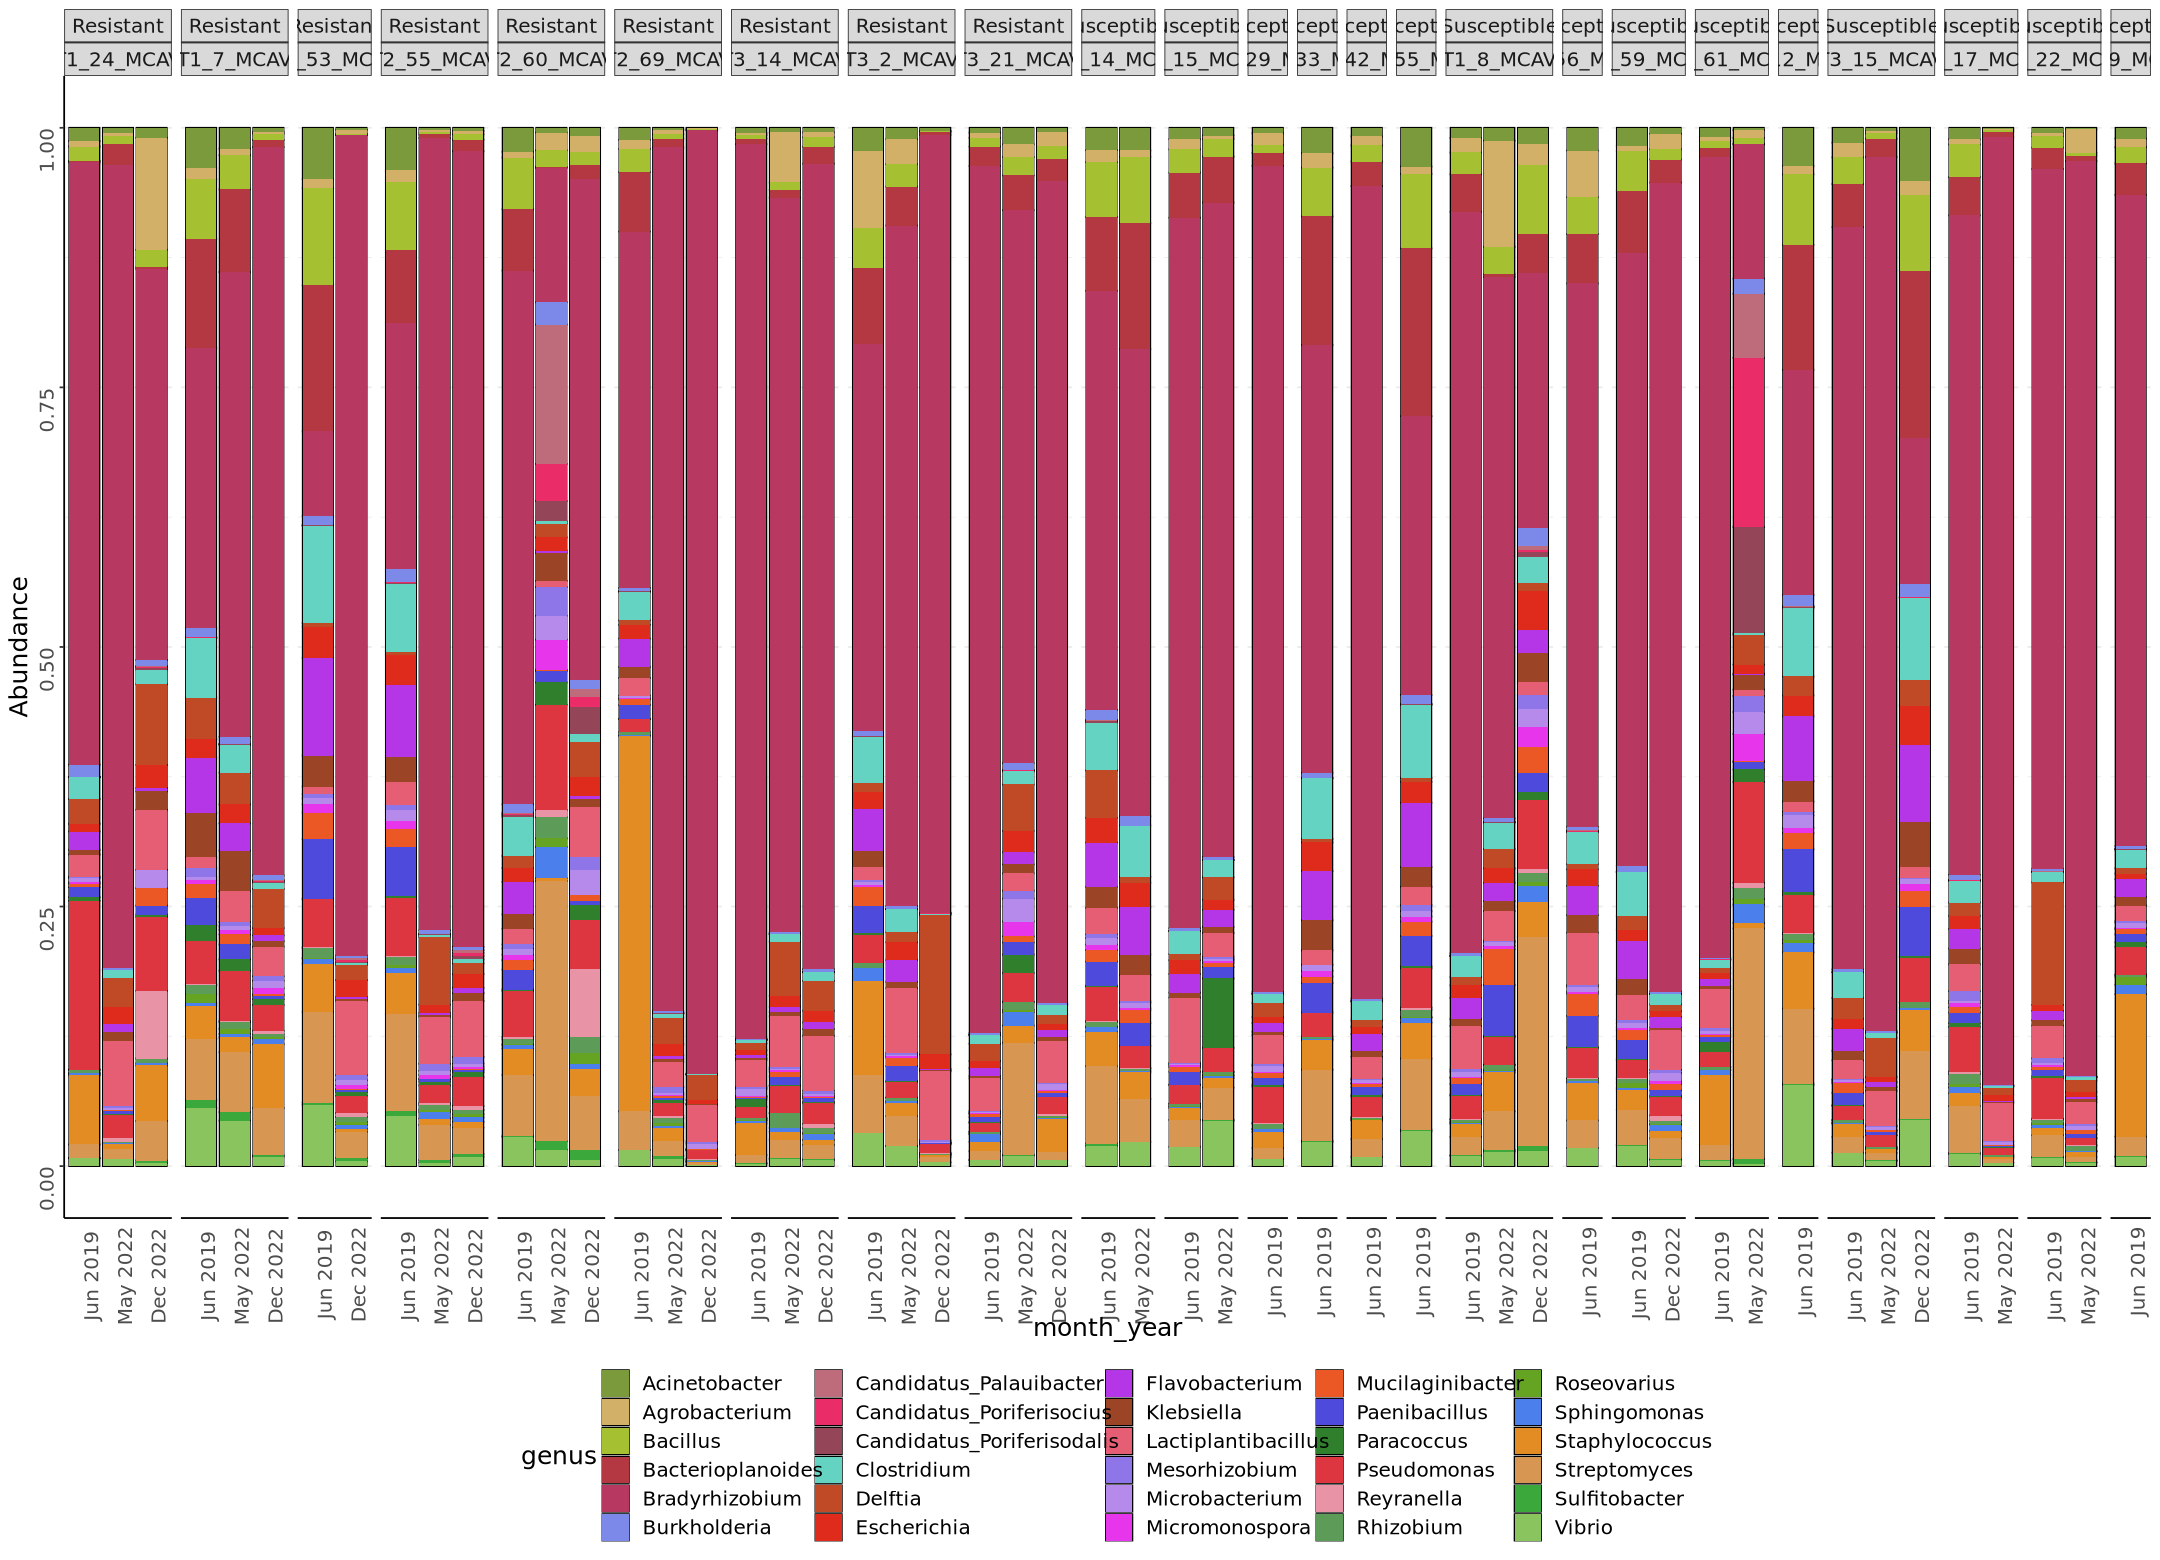

In [545]:
# want: single colony over time, facet by r vs s instead? 
# tried to use ggh4x:facet_nested but am getting weird error: could not find function "is_theme_element"

p<-plot_bar(subset_mcav,x = "month_year",fill='genus')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# also need to remove samples added in 12/2022

In [549]:
sctld_raw_30_norm

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 30 taxa and 216 samples ]
sample_data() Sample Data:       [ 216 samples by 22 sample variables ]
tax_table()   Taxonomy Table:    [ 30 taxa by 8 taxonomic ranks ]

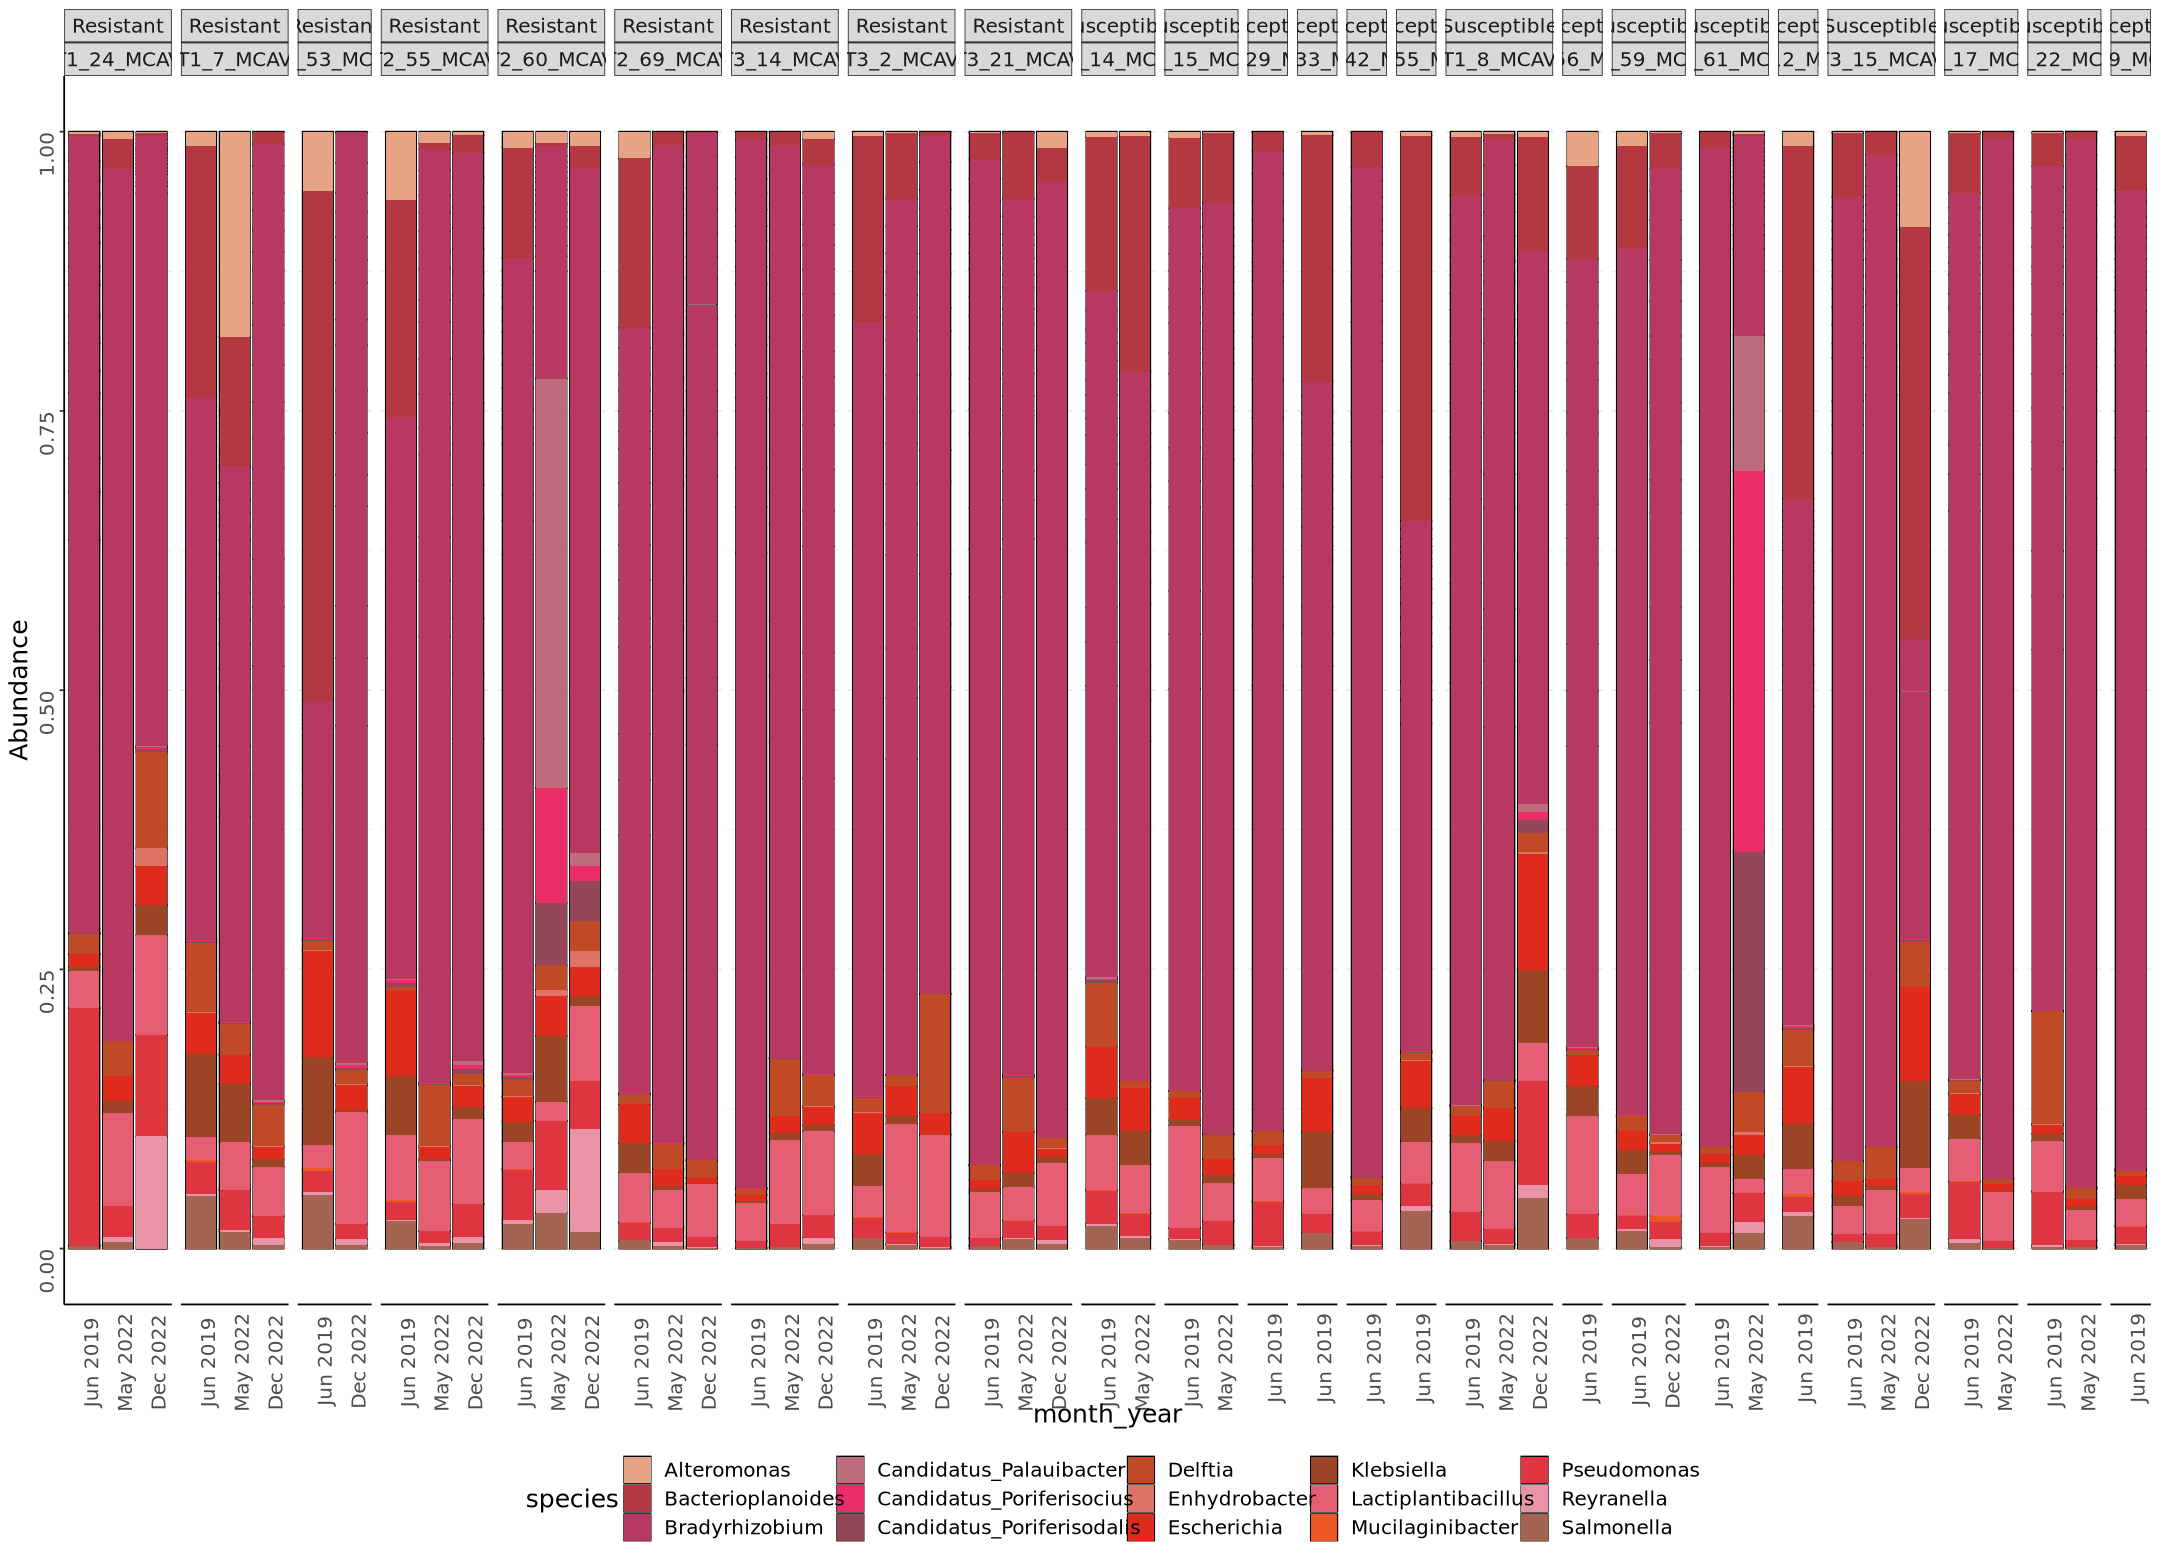

In [548]:
# repeat top 30 spp 
subset_mcav<- subset_samples(sctld_raw_30_norm, (Species == "MCAV" & Health_status != "Diseased_Margin"))
# and remove newly tagged colonies in 2022 
dec_tags<-c('12/03/22','12/05/22')
subset_mcav<- subset_samples(subset_mcav, (!(Date_InitialTag %in% dec_tags)))

p<-plot_bar(subset_mcav,x = "month_year",fill='species')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

In [ ]:
# repeat for other species 

# pstr
# repeat top genera
subset_mcav<- subset_samples(ps30_genus_norm, (Species == "MCAV" & Health_status != "Diseased_Margin"))
# and remove newly tagged colonies in 2022 
dec_tags<-c('12/03/22','12/05/22')
subset_mcav<- subset_samples(subset_mcav, (!(Date_InitialTag %in% dec_tags)))